<a href="https://colab.research.google.com/github/Keplerzhao/keplerzhao/blob/master/Sector_ETF_monitoring_System_27_July_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Batch 1/2: 80 tickers
  success: 80 columns
Batch 2/2: 16 tickers
  success: 16 columns

Got 96 tickers
Raw date range: 2021-01-04 -> 2026-07-24

After history filter: 95 valid tickers
Dropped due to short history:
['KOL']
✓ Chart saved: heatmap_200dma_voladj_percentile_sector_W-FRI.png


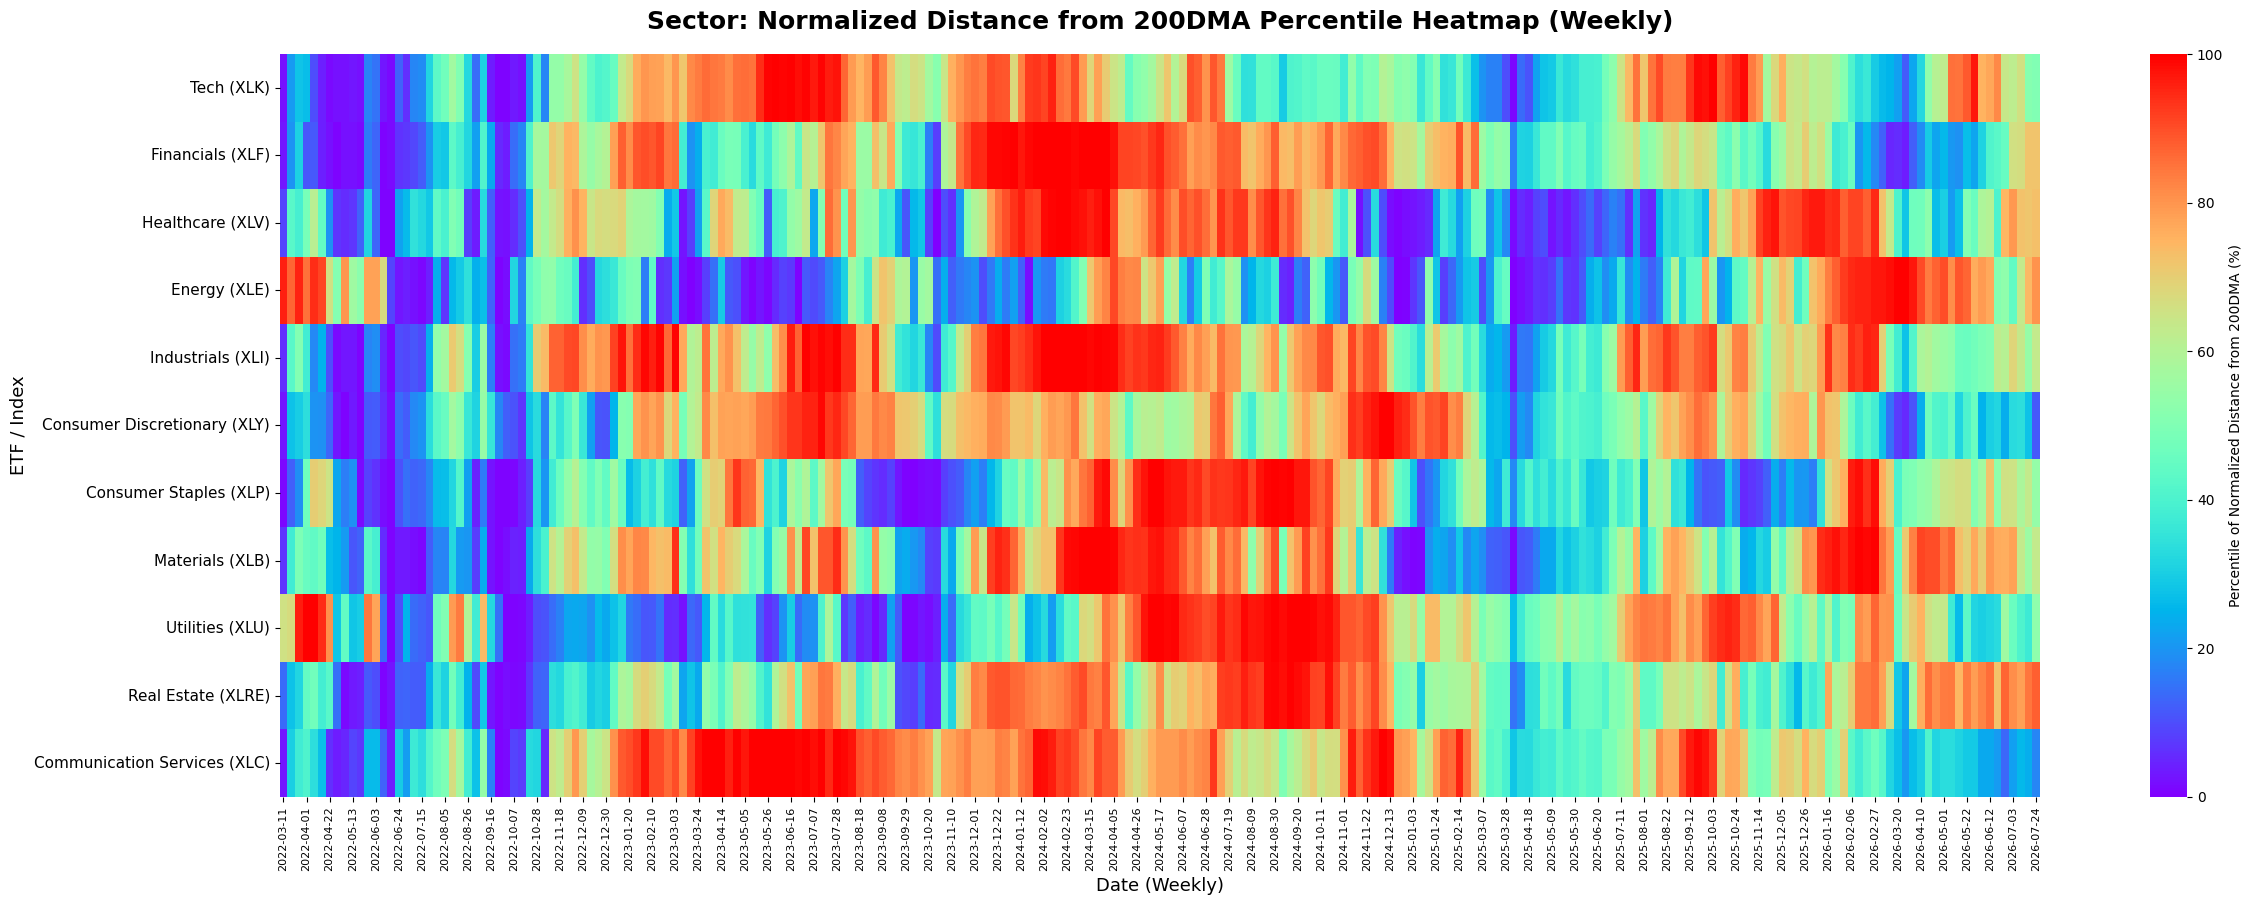

✓ Chart saved: heatmap_200dma_voladj_percentile_tech_ai_internet_W-FRI.png


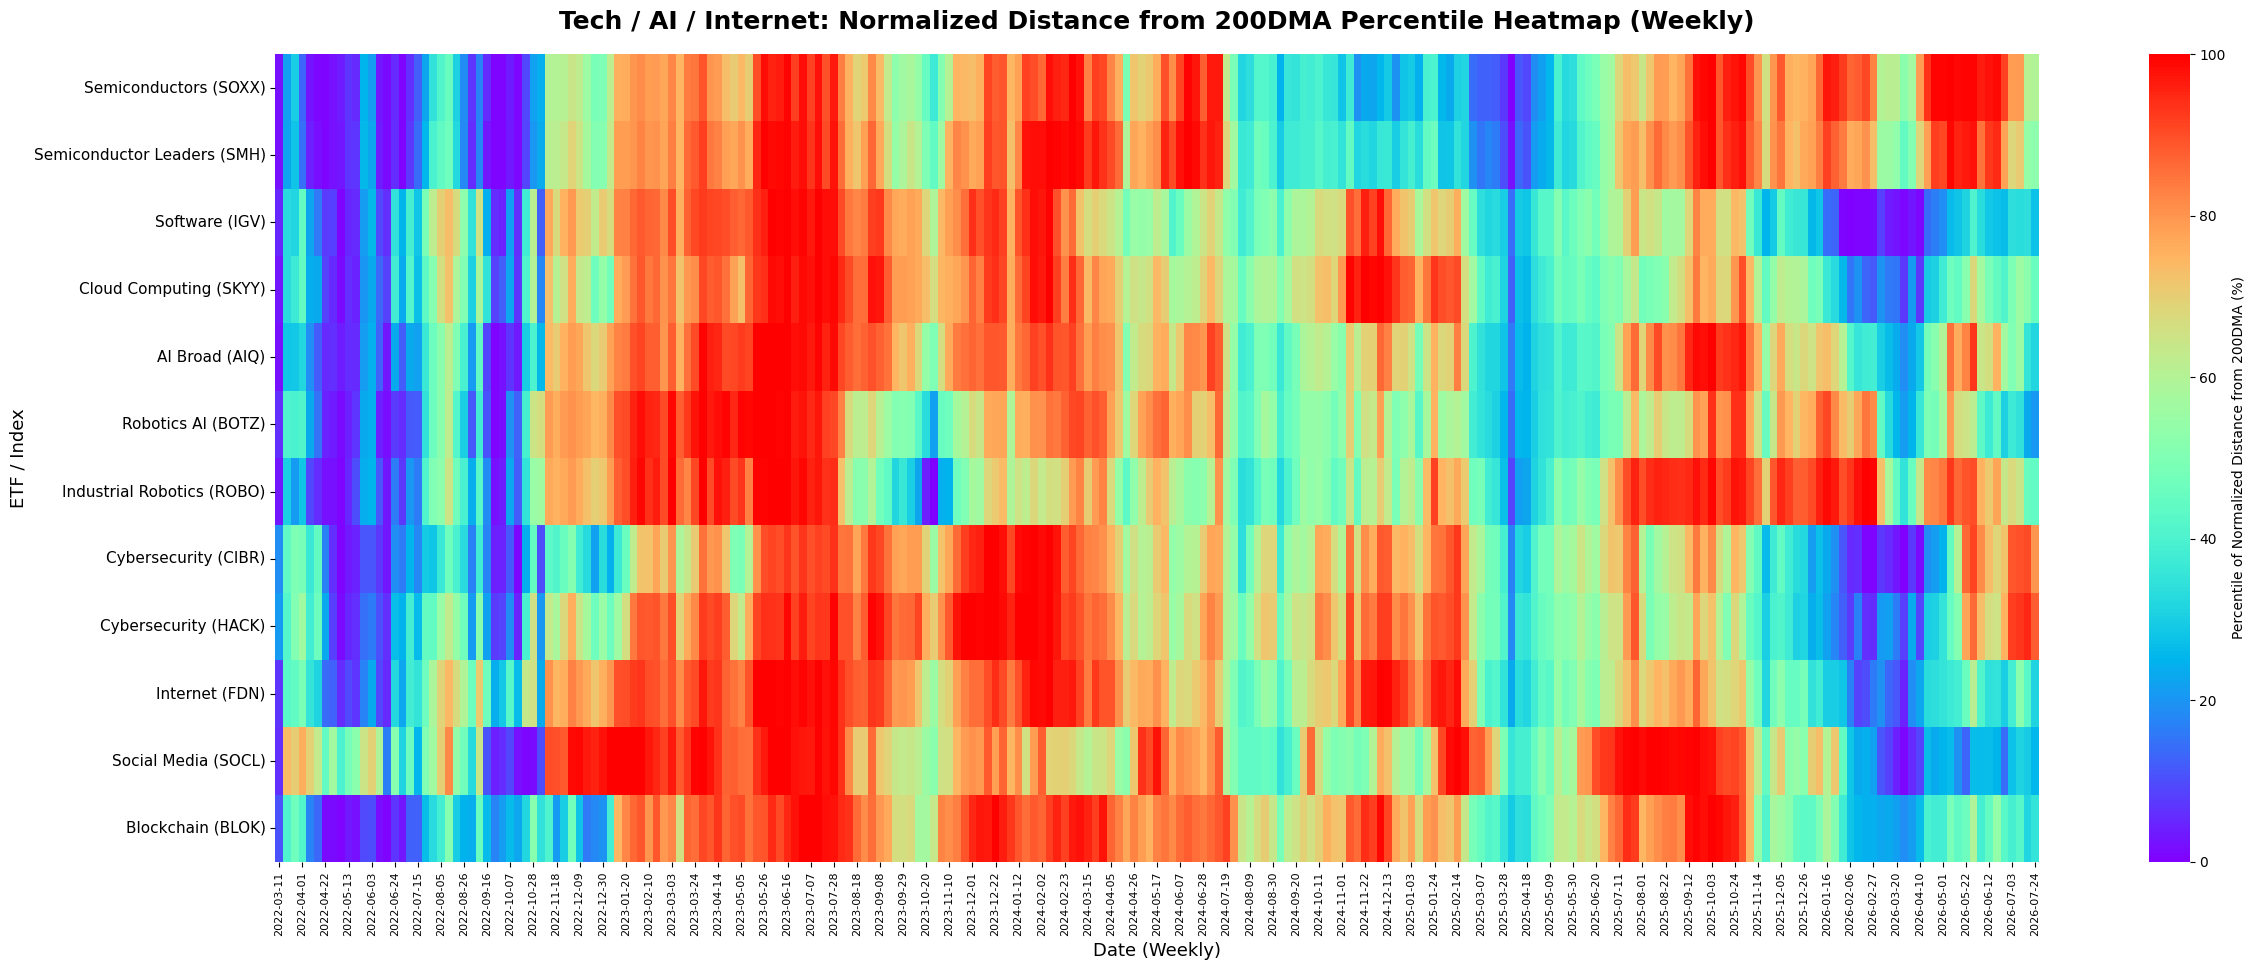

✓ Chart saved: heatmap_200dma_voladj_percentile_power_infra_data_center_W-FRI.png


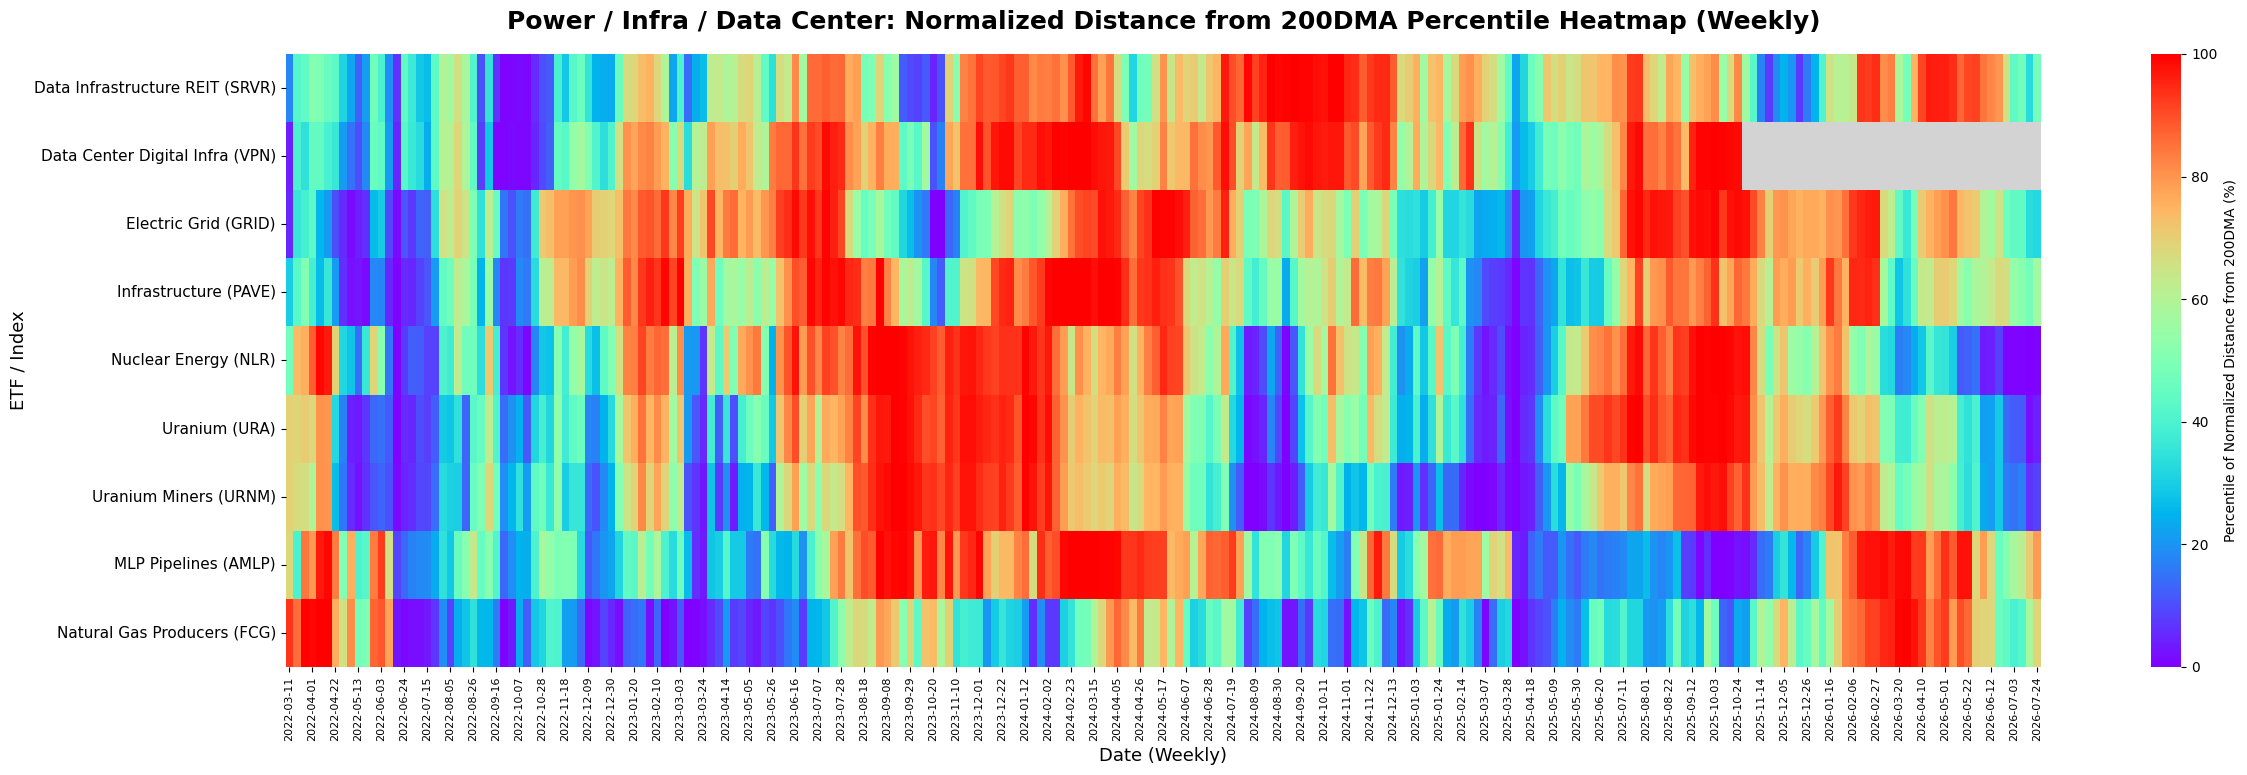

✓ Chart saved: heatmap_200dma_voladj_percentile_financials_credit_W-FRI.png


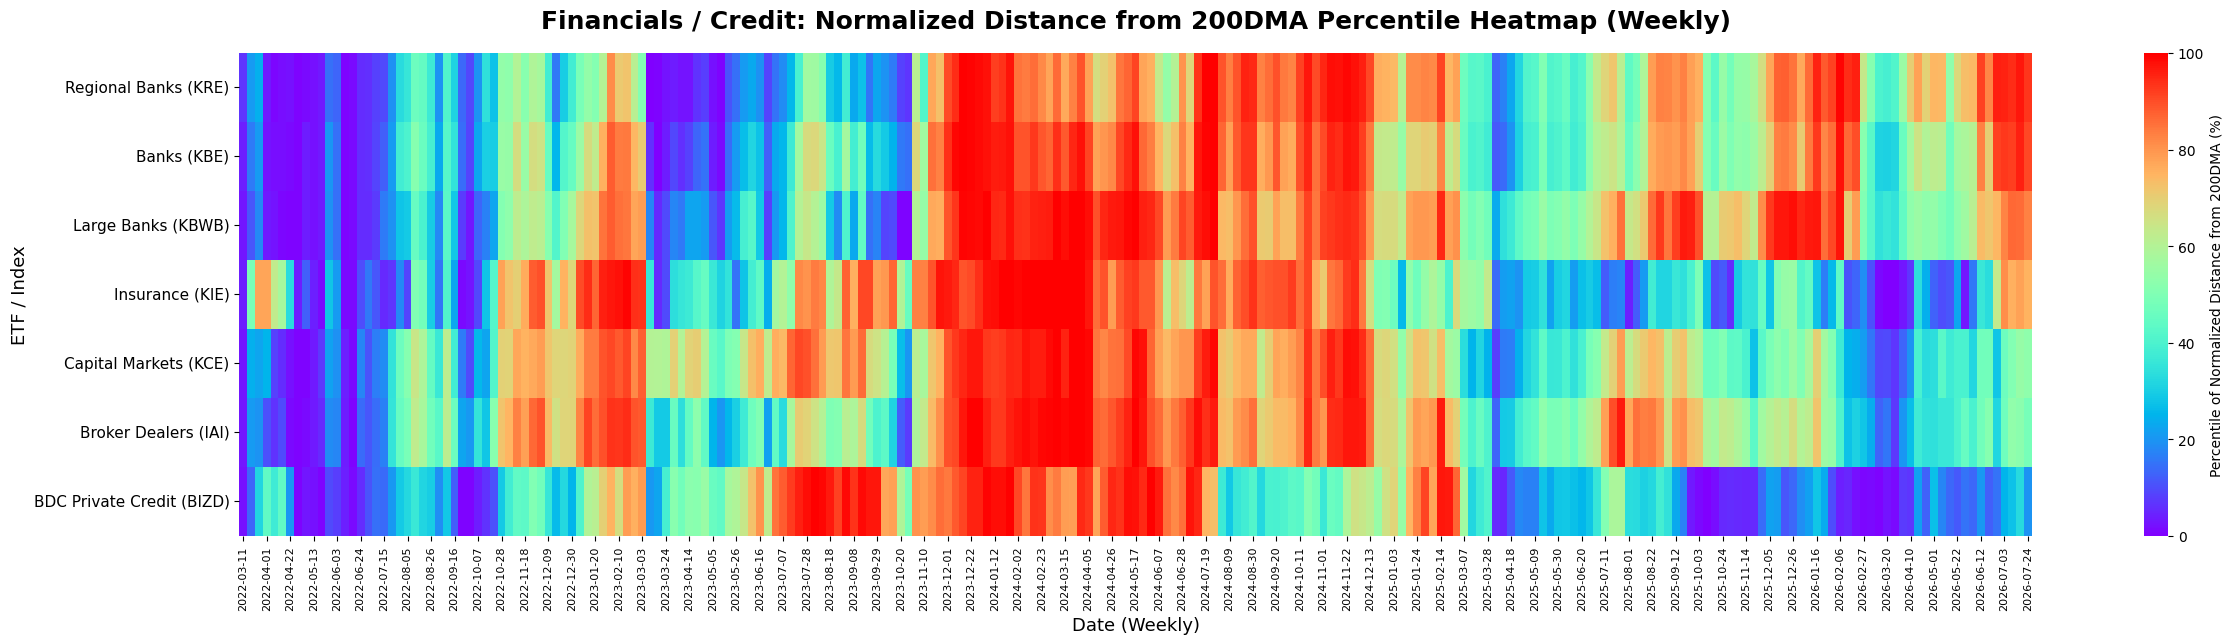

✓ Chart saved: heatmap_200dma_voladj_percentile_healthcare_W-FRI.png


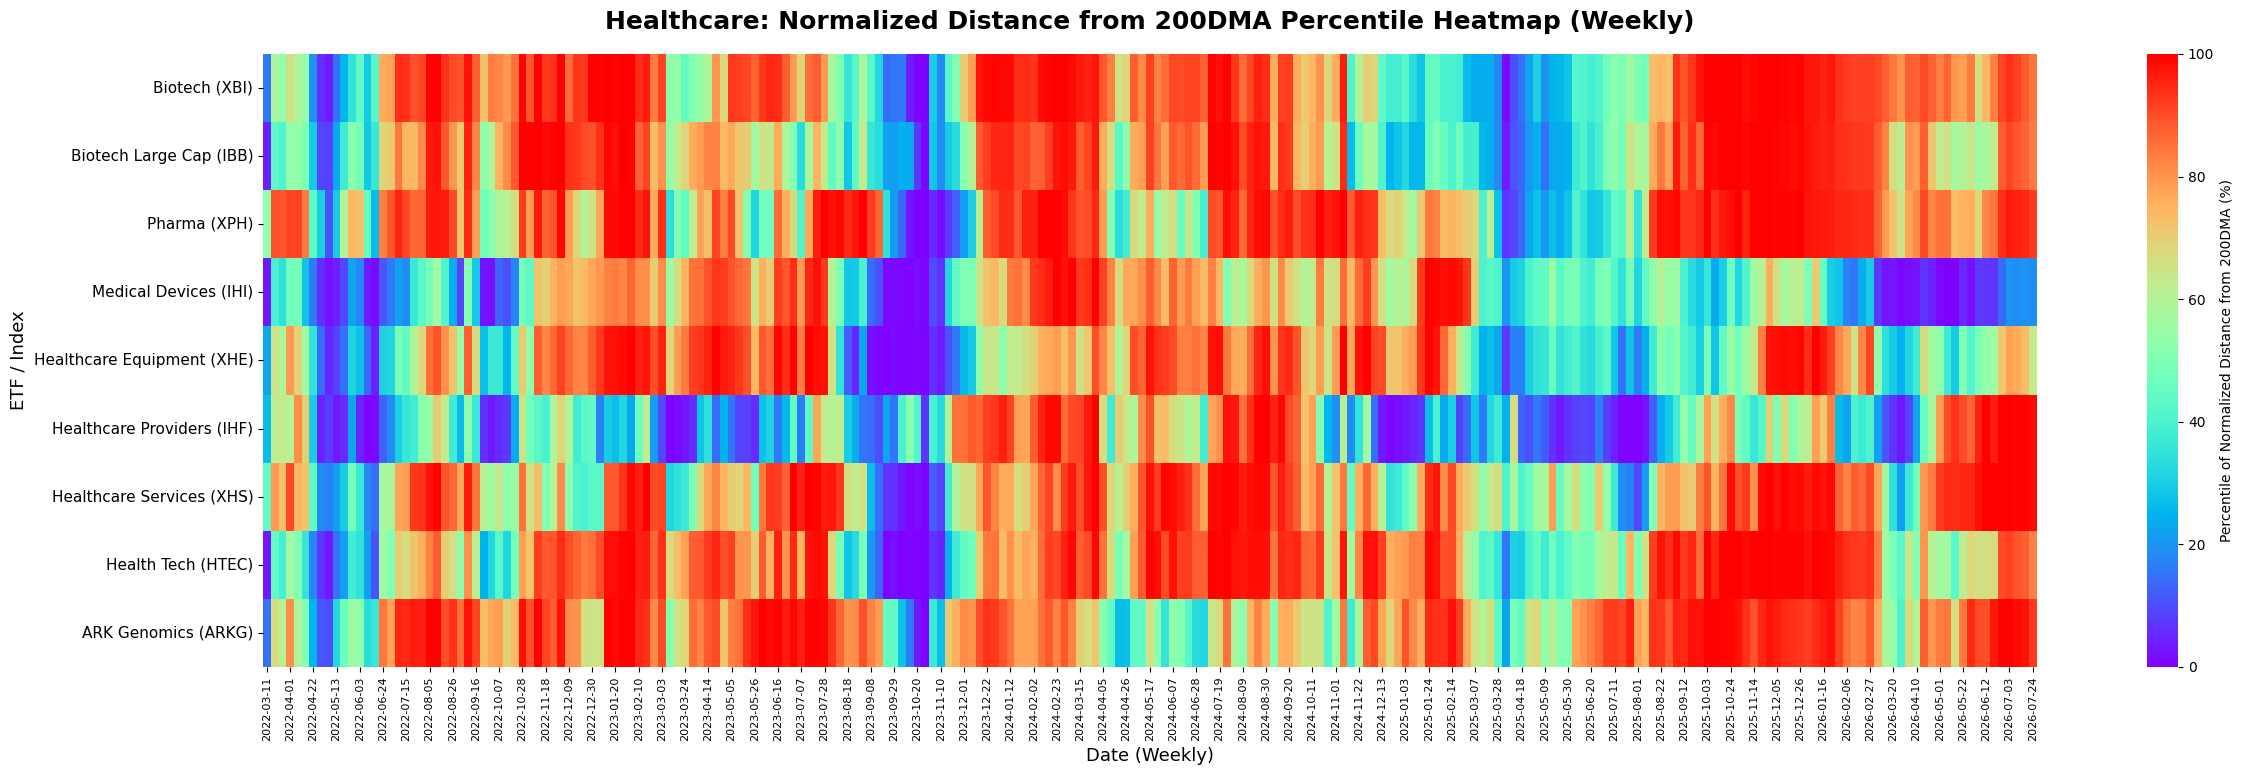

✓ Chart saved: heatmap_200dma_voladj_percentile_consumer_housing_travel_W-FRI.png


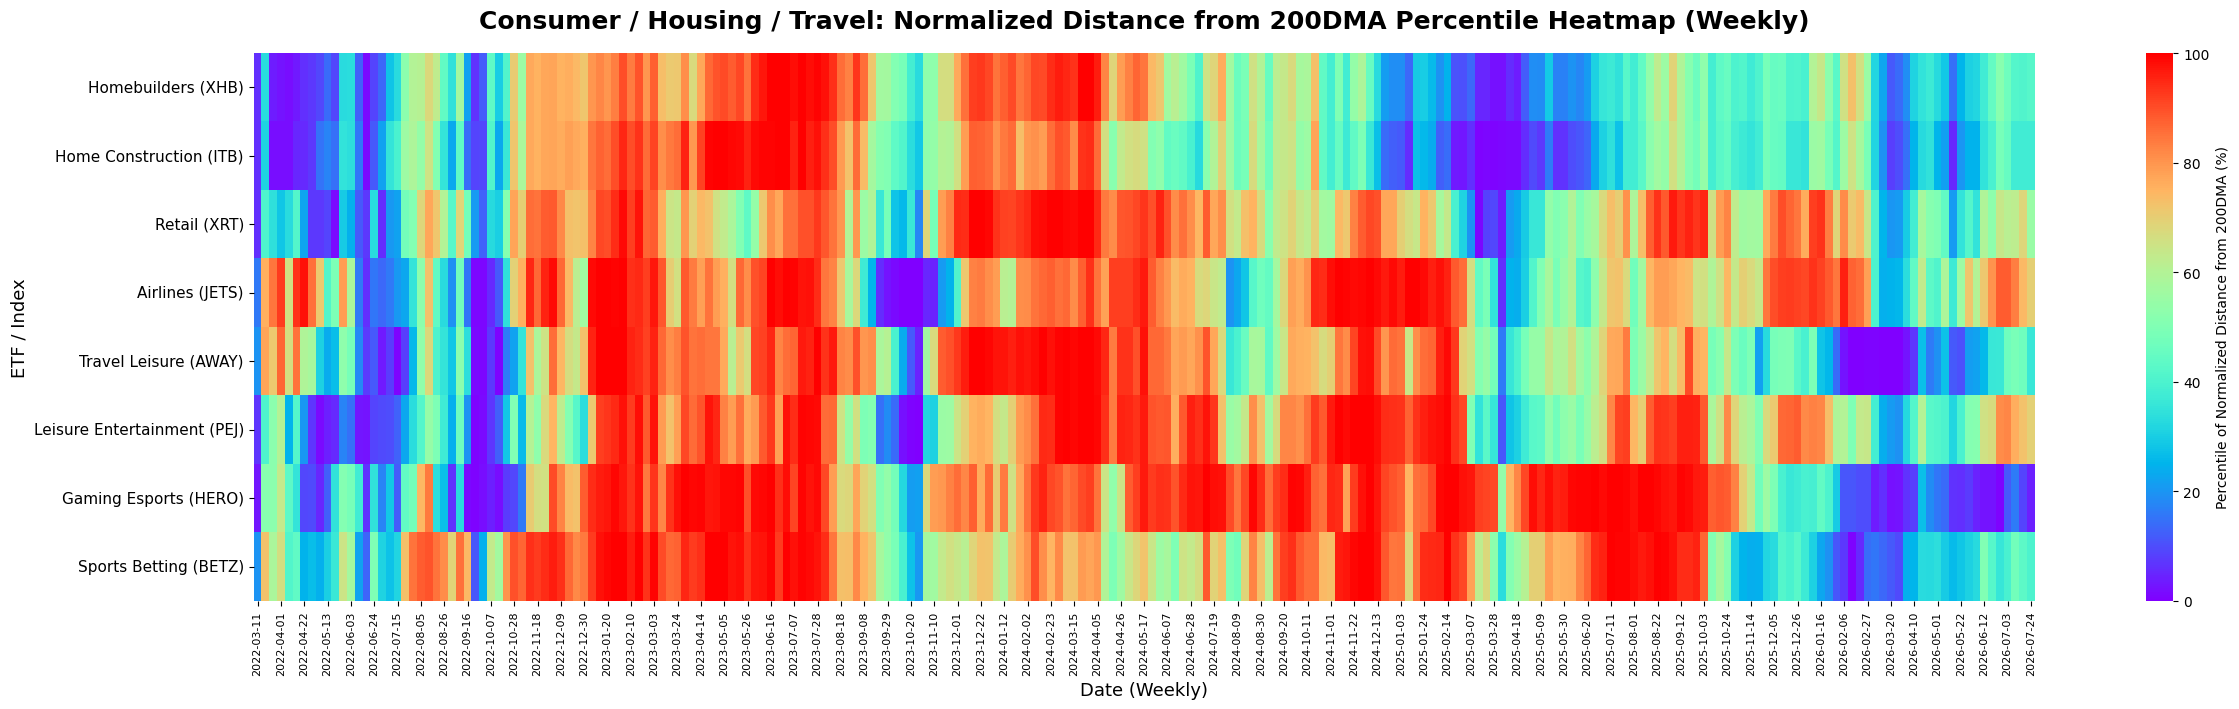

✓ Chart saved: heatmap_200dma_voladj_percentile_industrials_defense_transport_W-FRI.png


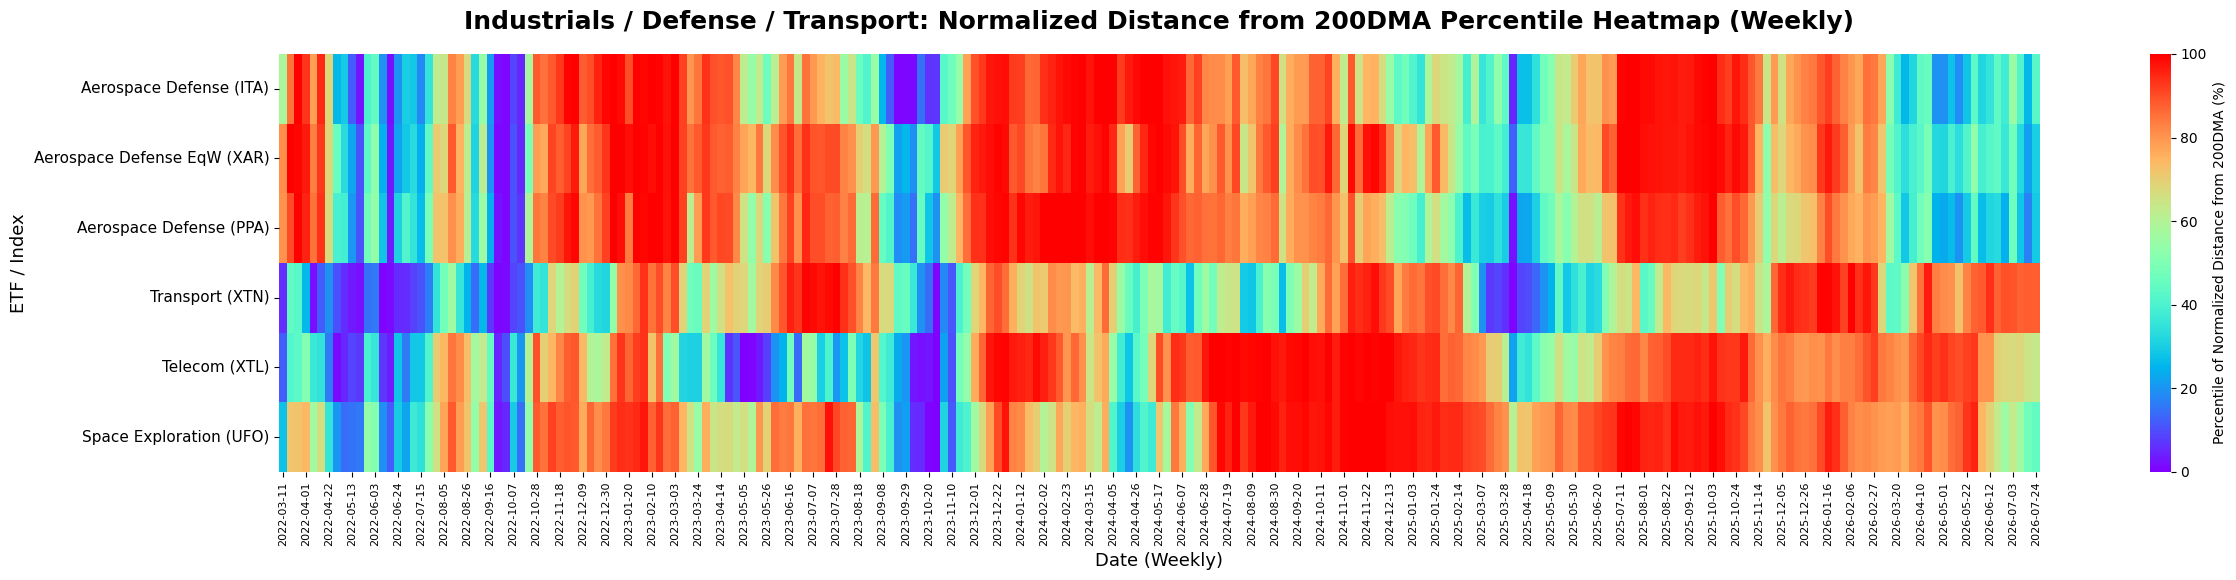

✓ Chart saved: heatmap_200dma_voladj_percentile_resources_commodities_W-FRI.png


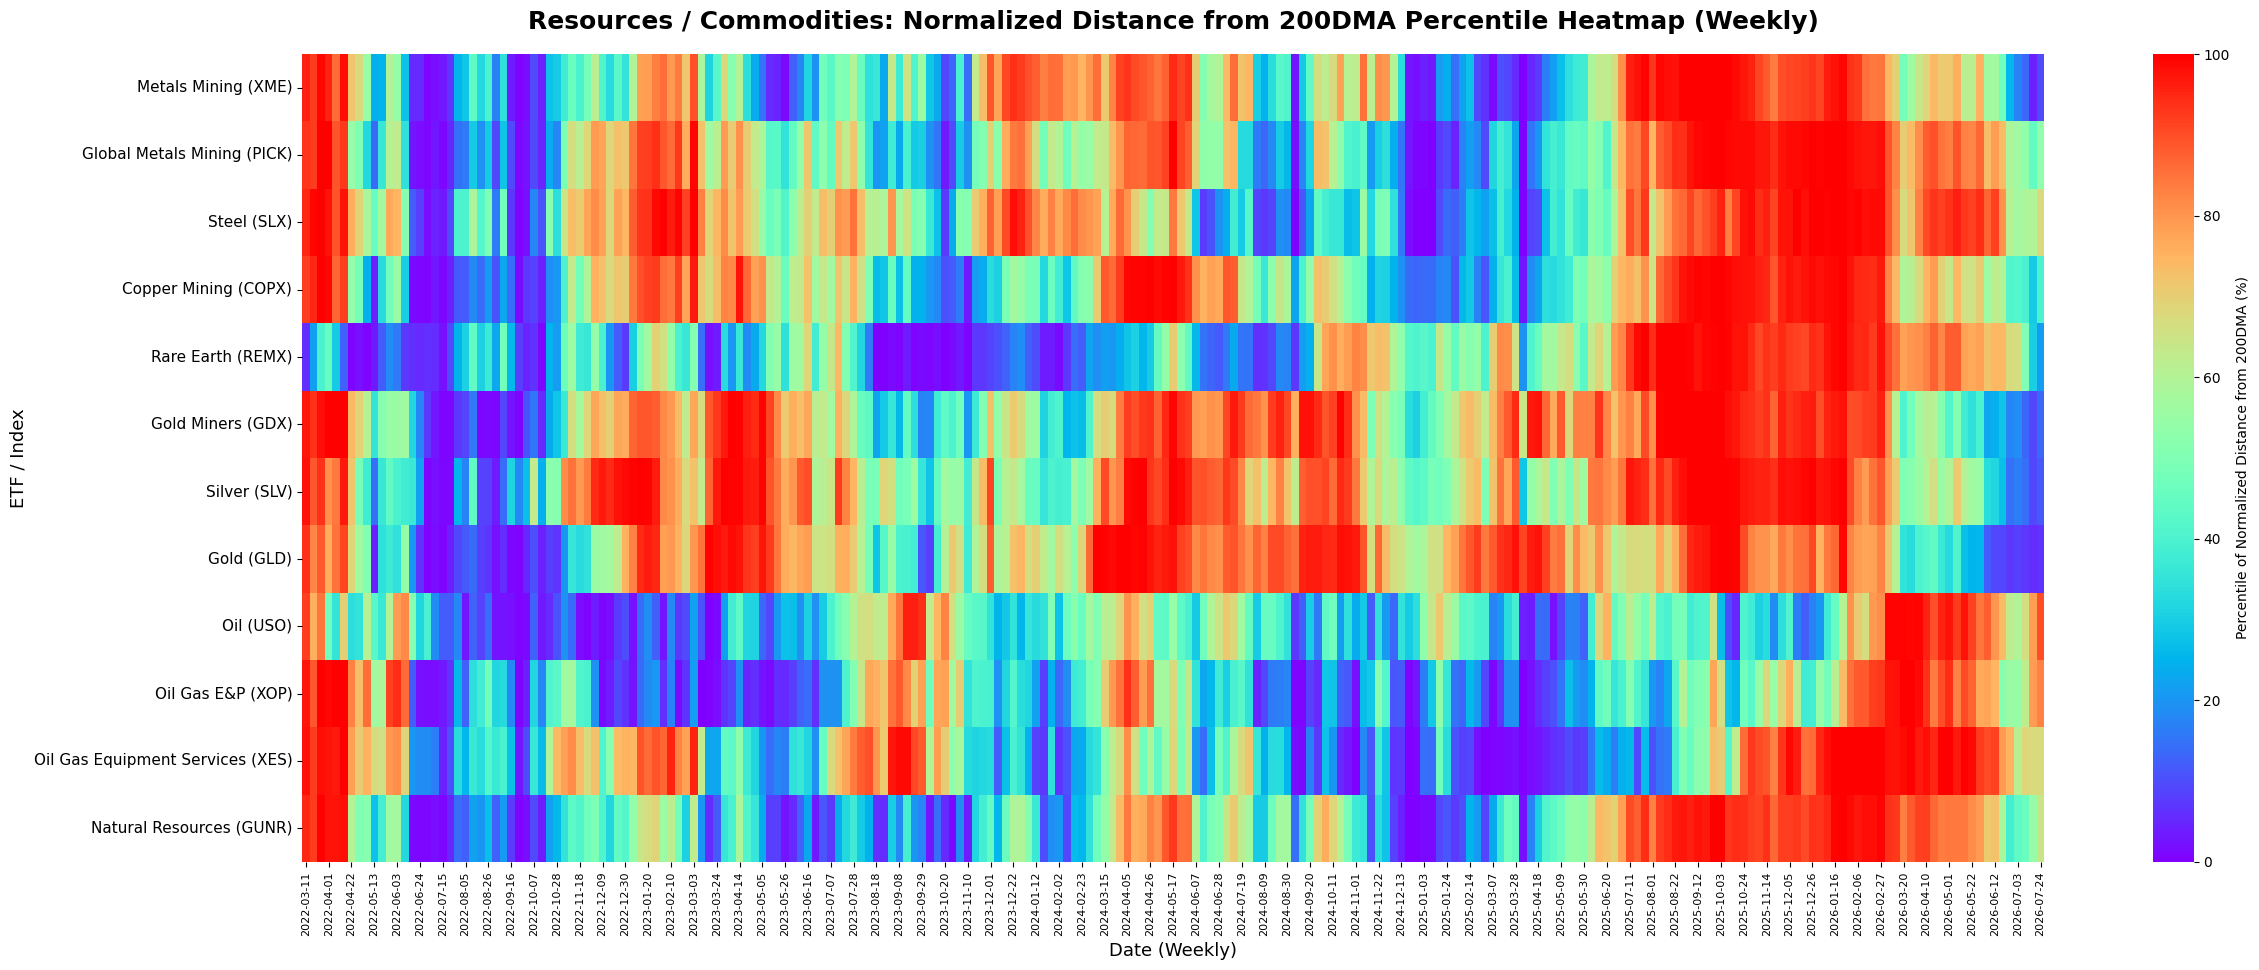

✓ Chart saved: heatmap_200dma_voladj_percentile_clean_energy_ev_battery_W-FRI.png


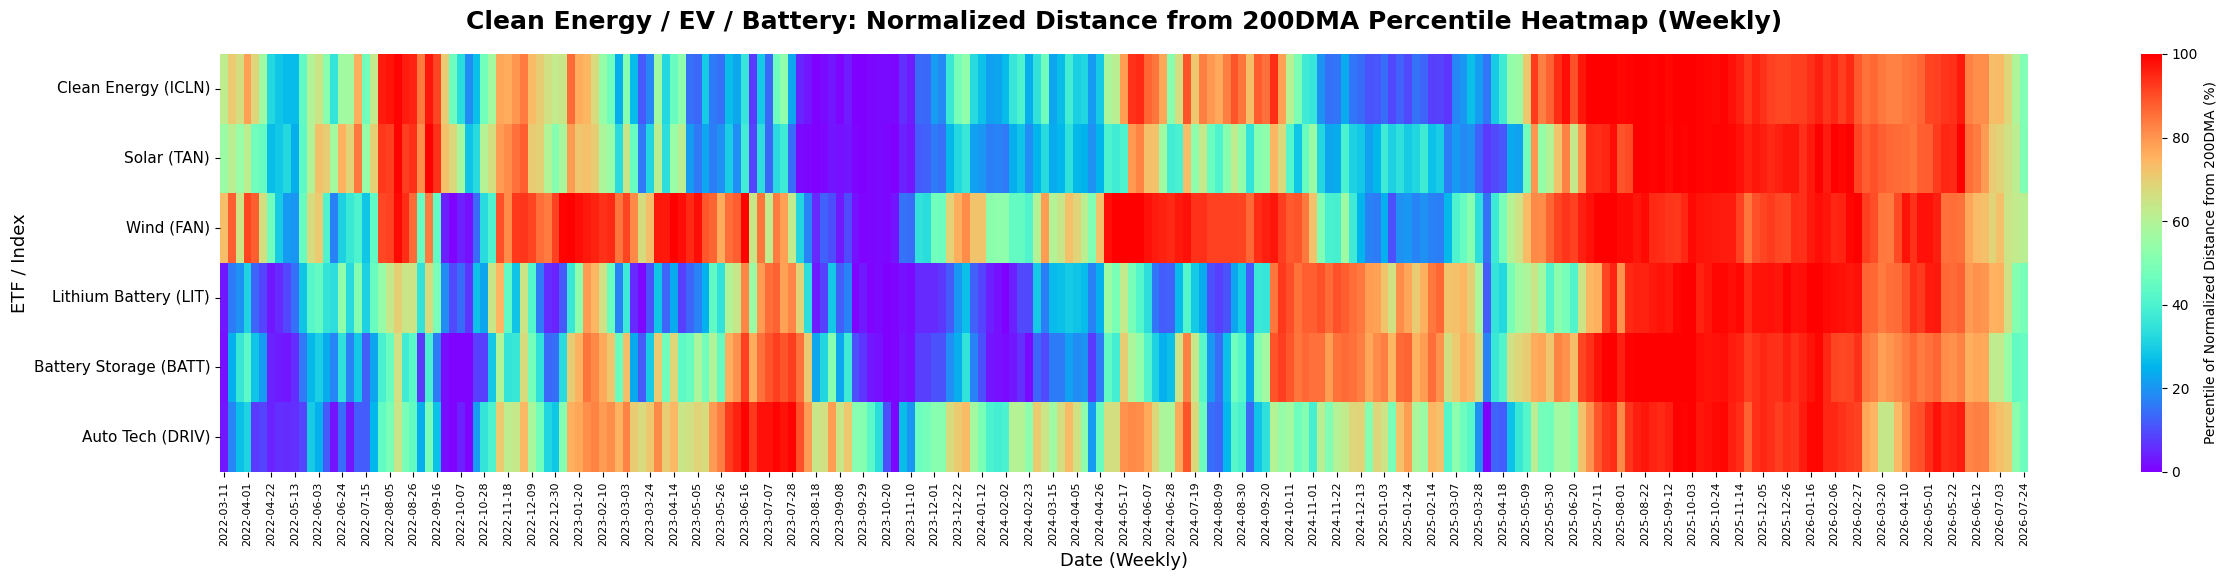

✓ Chart saved: heatmap_200dma_voladj_percentile_agriculture_water_W-FRI.png


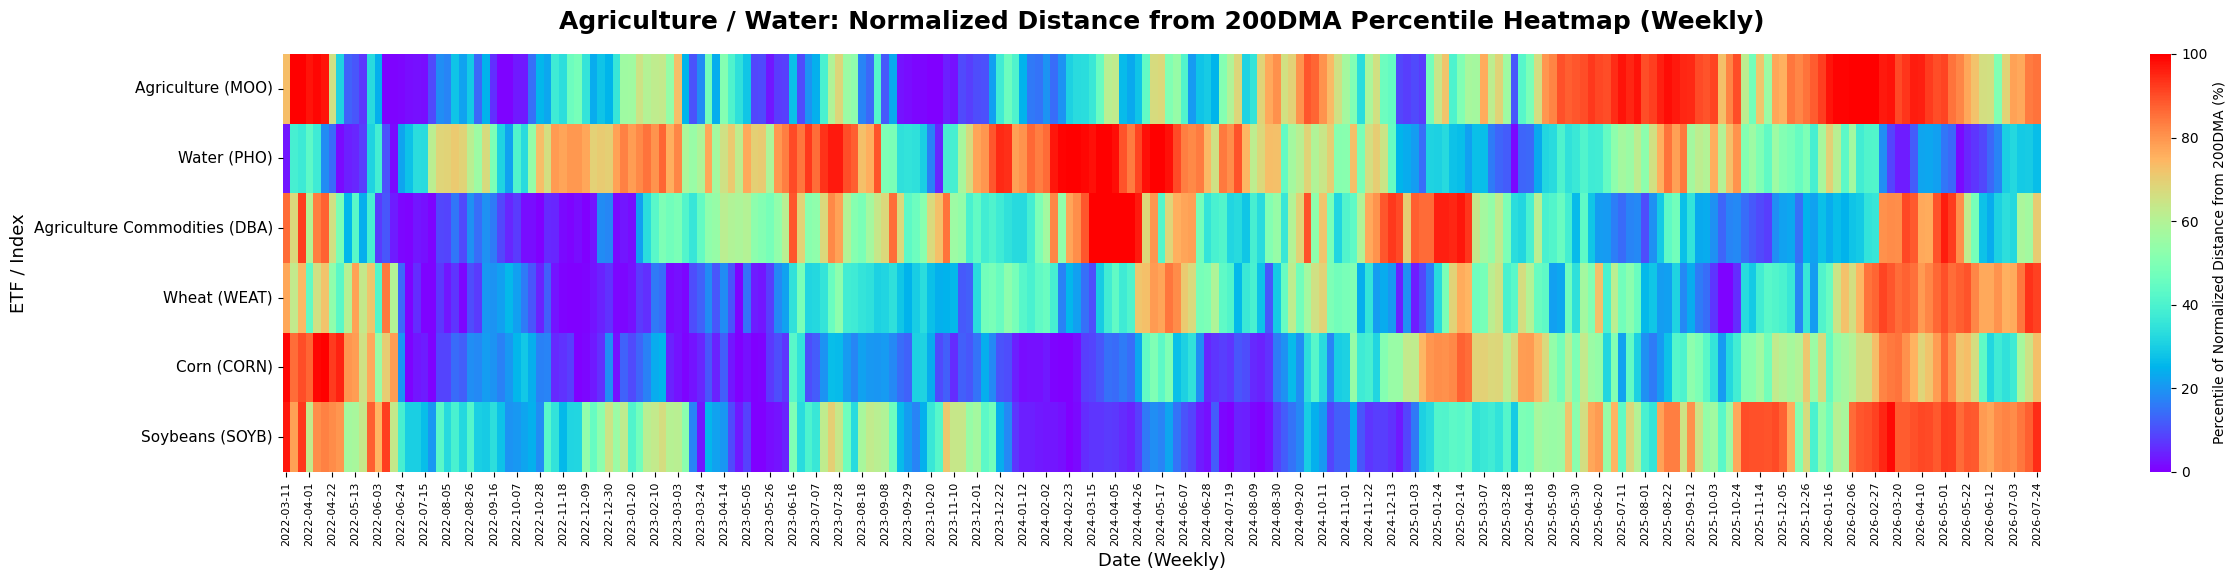

✓ Chart saved: heatmap_200dma_voladj_percentile_reits_W-FRI.png


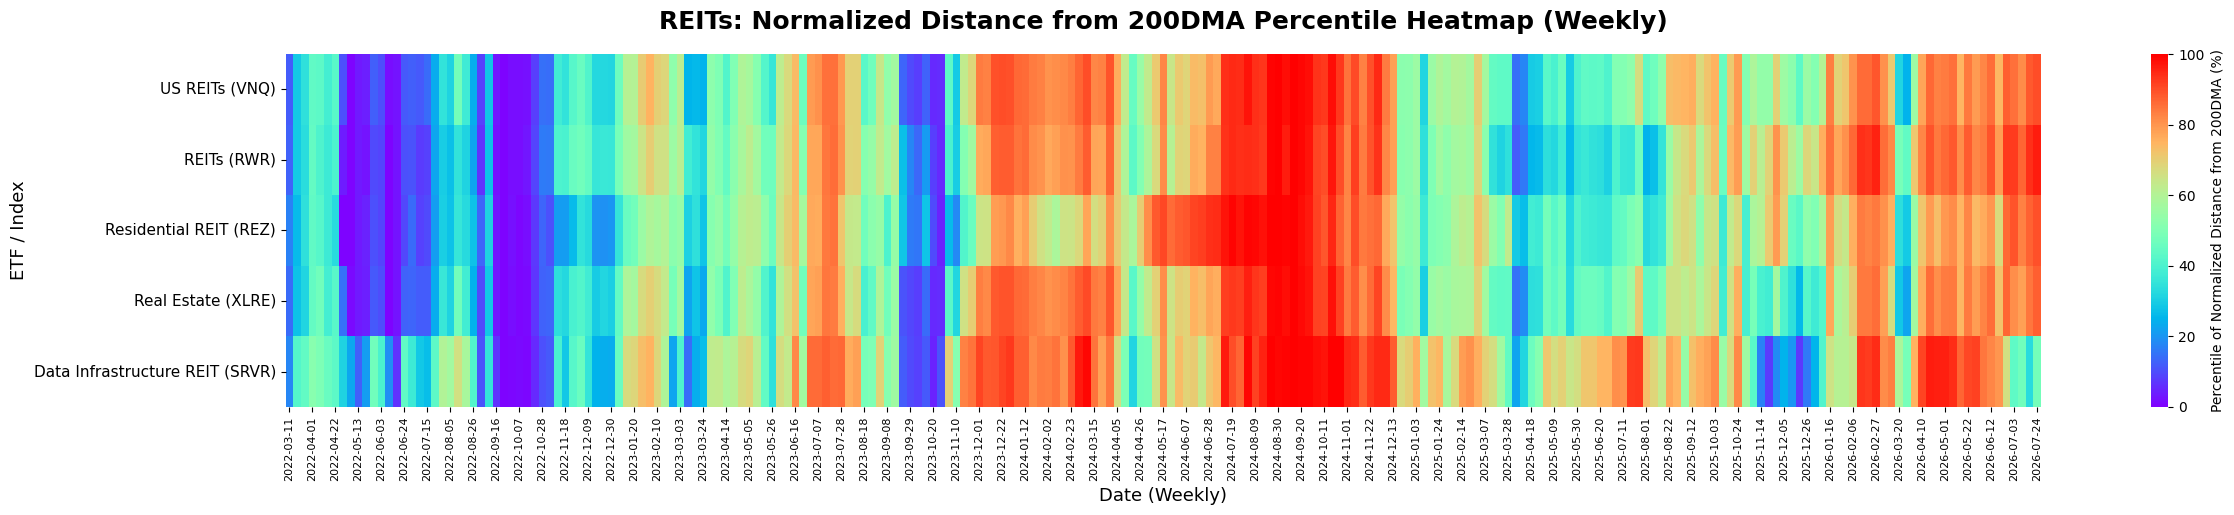

✓ Chart saved: heatmap_200dma_voladj_percentile_broad_market_macro_W-FRI.png


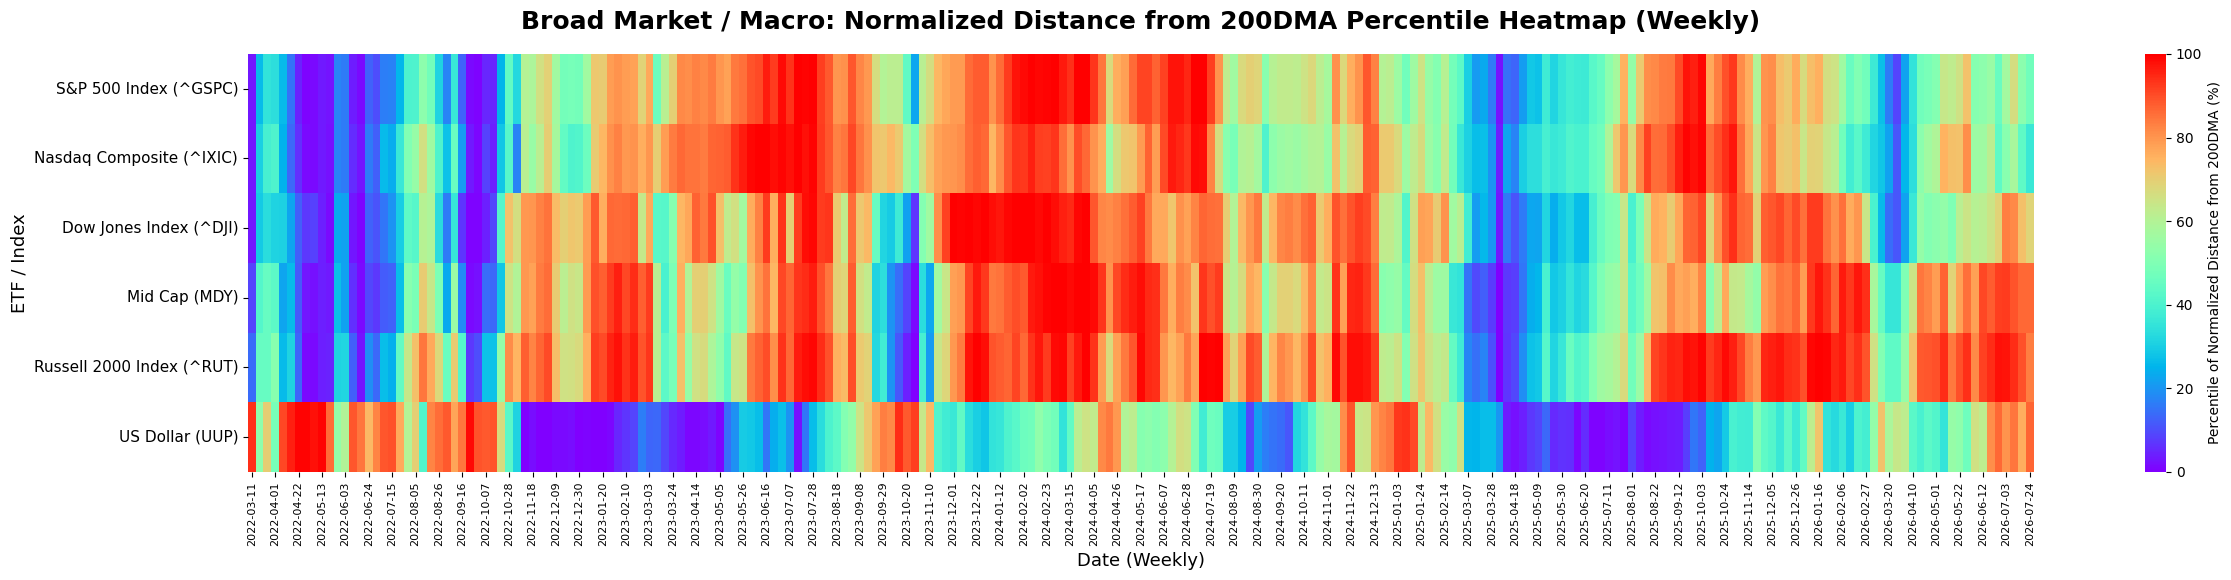


Latest date: 2026-07-24
Ticker                       Name                              Groups Distance from 200DMA % 63D Annualized Vol % Normalized Spread Historical Percentile %
   IHF       Healthcare Providers                          Healthcare                 16.12%               17.88%              0.90                   98.7%
   XHS        Healthcare Services                          Healthcare                 19.93%               17.24%              1.16                   98.5%
   RWR                      REITs                               REITs                 15.01%               16.28%              0.92                   96.3%
  SOYB                   Soybeans                 Agriculture / Water                 10.97%               13.95%              0.79                   94.4%
   KRE             Regional Banks                 Financials / Credit                 13.18%               20.54%              0.64                   93.3%
  ARKG               ARK Genomics      

In [3]:
#@title Sector Heat Map Monitoring System { display-mode: "form" }

import subprocess
subprocess.run(["pip", "install", "yfinance", "seaborn", "matplotlib", "-q"], check=False)
api_key = "490ed0ef6adef36a548539c3e6da425e"
import logging
import warnings
warnings.filterwarnings("ignore")
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

import os
import re
import math
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================================
# 0. Parameters
# ==========================================================

START_DATE = "2021-01-01"
END_DATE = None

MA_WINDOW = 200
VOL_WINDOW = 63
TRADING_DAYS = 252
MIN_PERCENTILE_OBS = 100

BATCH_SIZE = 80

# W-FRI = weekly
# ME    = month end; if your pandas version does not support ME, use M
RESAMPLE_FREQ = "W-FRI"

N_PERIODS = 600
SAVE_FIG = True
SAVE_CSV = True


# ==========================================================
# 1. ETF Groups / Index Code
# ==========================================================

ETF_GROUPS = {
    "Sector": {
        "XLK":  "Tech",
        "XLF":  "Financials",
        "XLV":  "Healthcare",
        "XLE":  "Energy",
        "XLI":  "Industrials",
        "XLY":  "Consumer Discretionary",
        "XLP":  "Consumer Staples",
        "XLB":  "Materials",
        "XLU":  "Utilities",
        "XLRE": "Real Estate",
        "XLC":  "Communication Services",
    },

    "Tech / AI / Internet": {
        "SOXX": "Semiconductors",
        "SMH":  "Semiconductor Leaders",
        "IGV":  "Software",
        "SKYY": "Cloud Computing",
        "AIQ":  "AI Broad",
        "BOTZ": "Robotics AI",
        "ROBO": "Industrial Robotics",
        "CIBR": "Cybersecurity",
        "HACK": "Cybersecurity",
        "FDN":  "Internet",
        "SOCL": "Social Media",
        "BLOK": "Blockchain",
    },

    "Power / Infra / Data Center": {
        "SRVR": "Data Infrastructure REIT",
        "VPN":  "Data Center Digital Infra",
        "GRID": "Electric Grid",
        "PAVE": "Infrastructure",
        "NLR":  "Nuclear Energy",
        "URA":  "Uranium",
        "URNM": "Uranium Miners",
        "AMLP": "MLP Pipelines",
        "FCG":  "Natural Gas Producers",
    },

    "Financials / Credit": {
        "KRE":  "Regional Banks",
        "KBE":  "Banks",
        "KBWB": "Large Banks",
        "KIE":  "Insurance",
        "KCE":  "Capital Markets",
        "IAI":  "Broker Dealers",
        "BIZD": "BDC Private Credit",
    },

    "Healthcare": {
        "XBI":  "Biotech",
        "IBB":  "Biotech Large Cap",
        "XPH":  "Pharma",
        "IHI":  "Medical Devices",
        "XHE":  "Healthcare Equipment",
        "IHF":  "Healthcare Providers",
        "XHS":  "Healthcare Services",
        "HTEC": "Health Tech",
        "ARKG": "ARK Genomics",
    },

    "Consumer / Housing / Travel": {
        "XHB":  "Homebuilders",
        "ITB":  "Home Construction",
        "XRT":  "Retail",
        "JETS": "Airlines",
        "AWAY": "Travel Leisure",
        "PEJ":  "Leisure Entertainment",
        "HERO": "Gaming Esports",
        "BETZ": "Sports Betting",
    },

    "Industrials / Defense / Transport": {
        "ITA":  "Aerospace Defense",
        "XAR":  "Aerospace Defense EqW",
        "PPA":  "Aerospace Defense",
        "XTN":  "Transport",
        "XTL":  "Telecom",
        "UFO":  "Space Exploration",
    },

    "Resources / Commodities": {
        "XME":  "Metals Mining",
        "PICK": "Global Metals Mining",
        "SLX":  "Steel",
        "COPX": "Copper Mining",
        "REMX": "Rare Earth",
        "GDX":  "Gold Miners",
        "SLV":  "Silver",
        "GLD":  "Gold",
        "USO":  "Oil",
        "XOP":  "Oil Gas E&P",
        "XES":  "Oil Gas Equipment Services",
        "GUNR": "Natural Resources",
        "KOL":  "Coal",
    },

    "Clean Energy / EV / Battery": {
        "ICLN": "Clean Energy",
        "TAN":  "Solar",
        "FAN":  "Wind",
        "LIT":  "Lithium Battery",
        "BATT": "Battery Storage",
        "DRIV": "Auto Tech",
    },

    "Agriculture / Water": {
        "MOO":  "Agriculture",
        "PHO":  "Water",
        "DBA":  "Agriculture Commodities",
        "WEAT": "Wheat",
        "CORN": "Corn",
        "SOYB": "Soybeans",
    },

    "REITs": {
        "VNQ":  "US REITs",
        "RWR":  "REITs",
        "REZ":  "Residential REIT",
        "XLRE": "Real Estate",
        "SRVR": "Data Infra REIT",
    },


    "Broad Market / Macro": {
        "^GSPC": "S&P 500 Index",
        "^IXIC": "Nasdaq Composite",
        "^DJI":  "Dow Jones Index",
        "MDY":   "Mid Cap",
        "^RUT":  "Russell 2000 Index",
        "UUP":   "US Dollar",


    },
}

BAD_TICKERS = {"BJK"}

for group_name in ETF_GROUPS:
    ETF_GROUPS[group_name] = {
        k: v for k, v in ETF_GROUPS[group_name].items()
        if k not in BAD_TICKERS
    }


# ==========================================================
# 2. Helper Functions
# ==========================================================

def flatten_groups(etf_groups):
    tickers = []
    for _, mp in etf_groups.items():
        tickers.extend(list(mp.keys()))
    return list(dict.fromkeys(tickers))


def build_ticker_name_map(etf_groups):
    ticker_name = {}
    for _, mp in etf_groups.items():
        for ticker, name in mp.items():
            if ticker not in ticker_name:
                ticker_name[ticker] = name
    return ticker_name


def chunk_list(lst, n):
    return [lst[i:i+n] for i in range(0, len(lst), n)]


def normalize_end_date(end_date):
    if end_date is None:
        return None
    return (pd.to_datetime(end_date) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")


def extract_close(raw, tickers):
    if raw is None or raw.empty:
        return pd.DataFrame()

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in raw.columns.get_level_values(0):
            px = raw["Close"].copy()
        elif "Close" in raw.columns.get_level_values(1):
            px = raw.xs("Close", axis=1, level=1).copy()
        else:
            return pd.DataFrame()
    else:
        if "Close" in raw.columns:
            px = raw[["Close"]].copy()
            if len(tickers) == 1:
                px.columns = [tickers[0]]
        else:
            px = raw.copy()

    if isinstance(px, pd.Series):
        px = px.to_frame()

    px.index = pd.to_datetime(px.index)
    px = px.sort_index()
    px = px.replace([np.inf, -np.inf], np.nan)
    px = px.dropna(axis=1, how="all")
    px.columns = [str(c) for c in px.columns]

    return px


def download_prices(etf_groups, start_date, end_date=None, batch_size=80):
    tickers = flatten_groups(etf_groups)
    yf_end = normalize_end_date(end_date)

    print(f"Downloading {len(tickers)} tickers...")
    all_prices = []
    failed = []

    batches = chunk_list(tickers, batch_size)

    for i, batch in enumerate(batches, start=1):
        print(f"Batch {i}/{len(batches)}: {len(batch)} tickers")

        try:
            raw = yf.download(
                batch,
                start=start_date,
                end=yf_end,
                progress=False,
                auto_adjust=True,
                actions=False,
                group_by="column",
                threads=True,
            )

            px = extract_close(raw, batch)

            batch_failed = [
                t for t in batch
                if t not in px.columns or px[t].dropna().empty
            ]

            if batch_failed:
                failed.extend(batch_failed)
                print("  failed:", batch_failed)

            if not px.empty:
                all_prices.append(px)
                print(f"  success: {px.shape[1]} columns")

        except Exception as e:
            print(f"  batch error: {e}")
            failed.extend(batch)

    if not all_prices:
        raise RuntimeError("No price data downloaded.")

    prices = pd.concat(all_prices, axis=1).sort_index()
    prices = prices.loc[:, ~prices.columns.duplicated()]

    ordered_cols = [t for t in tickers if t in prices.columns]
    prices = prices[ordered_cols]

    print()
    print(f"Got {prices.shape[1]} tickers")
    print(f"Raw date range: {prices.index[0].date()} -> {prices.index[-1].date()}")

    if failed:
        print()
        print("Raw failed / no data tickers:")
        print(sorted(set(failed)))

    return prices, sorted(set(failed))


def percentile_rank_last(arr):
    if len(arr) == 0 or np.isnan(arr[-1]):
        return np.nan

    valid = arr[~np.isnan(arr)]

    if len(valid) == 0:
        return np.nan

    return np.mean(valid <= arr[-1])


def safe_filename(text):
    text = text.lower()
    text = text.replace("&", "and")
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text)
    return text.strip("_")


# ==========================================================
# 3. Download Prices
# ==========================================================

TICKERS = flatten_groups(ETF_GROUPS)
TICKER_NAME = build_ticker_name_map(ETF_GROUPS)

TICKER_LABEL = {
    ticker: f"{TICKER_NAME[ticker]} ({ticker})"
    for ticker in TICKERS
}

prices, raw_failed = download_prices(
    etf_groups=ETF_GROUPS,
    start_date=START_DATE,
    end_date=END_DATE,
    batch_size=BATCH_SIZE,
)

# Keep only tickers with enough data
min_required_obs = MA_WINDOW + MIN_PERCENTILE_OBS
valid_cols = [
    c for c in prices.columns
    if prices[c].dropna().shape[0] >= min_required_obs
]

dropped_short_history = [c for c in prices.columns if c not in valid_cols]
prices = prices[valid_cols]

print()
print(f"After history filter: {len(valid_cols)} valid tickers")
if dropped_short_history:
    print("Dropped due to short history:")
    print(dropped_short_history)


# ==========================================================
# 4. Calculate Normalized Distance from 200DMA
# ==========================================================

ma200 = prices.rolling(MA_WINDOW, min_periods=MA_WINDOW).mean()

distance_from_ma = prices / ma200 - 1

daily_returns = prices.pct_change()

realized_vol = (
    daily_returns
    .rolling(VOL_WINDOW, min_periods=VOL_WINDOW)
    .std()
    * np.sqrt(TRADING_DAYS)
)

realized_vol = realized_vol.replace(0, np.nan)

normalized_spread = distance_from_ma / realized_vol


# ==========================================================
# 5. Historical Percentile of Normalized Spread
# ==========================================================

spread_percentile = normalized_spread.apply(
    lambda col: col.expanding(min_periods=MIN_PERCENTILE_OBS).apply(
        percentile_rank_last,
        raw=True,
    )
) * 100


# Rename columns for chart display
spread_percentile = spread_percentile.rename(columns=TICKER_LABEL)
normalized_spread = normalized_spread.rename(columns=TICKER_LABEL)
distance_from_ma = distance_from_ma.rename(columns=TICKER_LABEL)
realized_vol = realized_vol.rename(columns=TICKER_LABEL)


# ==========================================================
# 6. Weekly / Monthly Resampling
# ==========================================================

res_pctile = spread_percentile.resample(RESAMPLE_FREQ).last()
res_spread = normalized_spread.resample(RESAMPLE_FREQ).last()
res_distance = distance_from_ma.resample(RESAMPLE_FREQ).last()
res_vol = realized_vol.resample(RESAMPLE_FREQ).last()

res_pctile = res_pctile.dropna(how="all", axis=0)
res_pctile = res_pctile.dropna(how="all", axis=1)

if res_pctile.empty:
    raise RuntimeError(
        "Percentile data is empty. Try an earlier START_DATE or lower MIN_PERCENTILE_OBS."
    )

res_pctile = res_pctile.tail(N_PERIODS)

res_spread = res_spread.reindex(index=res_pctile.index, columns=res_pctile.columns)
res_distance = res_distance.reindex(index=res_pctile.index, columns=res_pctile.columns)
res_vol = res_vol.reindex(index=res_pctile.index, columns=res_pctile.columns)

latest_date = res_pctile.index[-1]


# ==========================================================
# 7. Format Dates for Plot
# ==========================================================

res_plot = res_pctile.copy()

if RESAMPLE_FREQ.upper().startswith("W"):
    res_plot.index = res_plot.index.strftime("%Y-%m-%d")
    title_freq = "Weekly"
else:
    res_plot.index = res_plot.index.strftime("%Y-%m")
    title_freq = "Monthly"


# ==========================================================
# 8. Heatmaps by Group
# ==========================================================

cmap = plt.get_cmap("rainbow").copy()
cmap.set_bad(color="lightgrey")

saved_chart_files = []
dropped_by_group = {}

for group_name, mapping in ETF_GROUPS.items():

    group_labels = []
    dropped = []

    for ticker, name in mapping.items():
        label = TICKER_LABEL.get(ticker)

        if label is not None and label in res_plot.columns:
            group_labels.append(label)
        else:
            dropped.append(ticker)

    dropped_by_group[group_name] = dropped

    if len(group_labels) == 0:
        continue

    group_data = res_plot[group_labels]

    fig_height = max(4, 0.65 * len(group_labels) + 2)

    plt.figure(figsize=(25, fig_height))

    ax = sns.heatmap(
        group_data.T,
        cmap=cmap,
        vmin=0,
        vmax=100,
        center=50,
        linewidths=0,
        linecolor=None,
        cbar_kws={"label": "Percentile of Normalized Distance from 200DMA (%)"},
    )

    plt.title(
        f"{group_name}: Normalized Distance from 200DMA Percentile Heatmap ({title_freq})",
        fontsize=18,
        fontweight="bold",
        pad=18,
    )

    plt.xlabel(f"Date ({title_freq})", fontsize=13)
    plt.ylabel("ETF / Index", fontsize=13)

    plt.xticks(rotation=90, ha="center", fontsize=8)
    plt.yticks(rotation=0, fontsize=11)

    plt.tight_layout()

    filename = (
        f"heatmap_200dma_voladj_percentile_"
        f"{safe_filename(group_name)}_{RESAMPLE_FREQ}.png"
    )

    if SAVE_FIG:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        saved_chart_files.append(filename)
        print(f"✓ Chart saved: {filename}")

    plt.show()


# ==========================================================
# 9. Latest Ranking Table
# ==========================================================

latest_percentile = (
    res_pctile
    .loc[latest_date]
    .dropna()
    .sort_values(ascending=False)
)

table = pd.DataFrame({
    "ETF / Index": latest_percentile.index,
    "Historical Percentile %": latest_percentile.values,
})

table["Ticker"] = table["ETF / Index"].str.extract(r"\((.*?)\)")
table["Name"] = table["ETF / Index"].str.replace(r"\s*\(.*?\)", "", regex=True)

table["Distance from 200DMA %"] = (
    res_distance.loc[latest_date]
    .reindex(table["ETF / Index"])
    .values
    * 100
)

table[f"{VOL_WINDOW}D Annualized Vol %"] = (
    res_vol.loc[latest_date]
    .reindex(table["ETF / Index"])
    .values
    * 100
)

table["Normalized Spread"] = (
    res_spread.loc[latest_date]
    .reindex(table["ETF / Index"])
    .values
)

# Add group information
ticker_to_groups = {}
for group_name, mapping in ETF_GROUPS.items():
    for ticker in mapping:
        ticker_to_groups.setdefault(ticker, []).append(group_name)

table["Groups"] = table["Ticker"].map(
    lambda x: " / ".join(ticker_to_groups.get(x, []))
)

table = table[
    [
        "Ticker",
        "Name",
        "Groups",
        "ETF / Index",
        "Distance from 200DMA %",
        f"{VOL_WINDOW}D Annualized Vol %",
        "Normalized Spread",
        "Historical Percentile %",
    ]
].reset_index(drop=True)

print()
print(f"Latest date: {latest_date.strftime('%Y-%m-%d')}")

display_table = table.copy()
display_table["Distance from 200DMA %"] = display_table["Distance from 200DMA %"].map(lambda x: f"{x:,.2f}%")
display_table[f"{VOL_WINDOW}D Annualized Vol %"] = display_table[f"{VOL_WINDOW}D Annualized Vol %"].map(lambda x: f"{x:,.2f}%")
display_table["Normalized Spread"] = display_table["Normalized Spread"].map(lambda x: f"{x:,.2f}")
display_table["Historical Percentile %"] = display_table["Historical Percentile %"].map(lambda x: f"{x:,.1f}%")

print(
    display_table[
        [
            "Ticker",
            "Name",
            "Groups",
            "Distance from 200DMA %",
            f"{VOL_WINDOW}D Annualized Vol %",
            "Normalized Spread",
            "Historical Percentile %",
        ]
    ].to_string(index=False)
)


# ==========================================================
# 10. Export Ranking Table
# ==========================================================

table_filename = f"ranking_200dma_voladj_percentile_{RESAMPLE_FREQ}.csv"

if SAVE_CSV:
    table.to_csv(table_filename, index=False, encoding="utf-8-sig")
    print(f"✓ Ranking table saved: {table_filename}")


# ==========================================================
# 11. Diagnostics
# ==========================================================

print()
print("Saved chart files:")
for f in saved_chart_files:
    print(f"- {f}")

print()
print("Dropped tickers by group:")
for group_name, dropped in dropped_by_group.items():
    if dropped:
        print(f"{group_name}: {dropped}")

In [4]:
#@title Sector ETF Monitoring System { display-mode: "form" }

import subprocess
subprocess.run(["pip", "install", "yfinance", "plotly", "-q"], check=False)

import logging
import warnings
warnings.filterwarnings("ignore")
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

import math
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px


# ==========================================================
# 0. 参数
# ==========================================================
START_DATE = "2026-01-01"
END_DATE   = None          # None = 到最新
BASE_DATE  = "2026-01-01"  # 统一基准日，所有板块从这一天开始标准化到100
BATCH_SIZE = 80

N_COLS = 3                 # subplot 每行几列
LINE_WIDTH = 1.8
HEIGHT_PER_ROW = 360       # 原来 320；稍微加高，给 label 留空间
SHOW_MARKERS = False       # 是否在线上加点
USE_LOG_Y = False          # 是否用对数坐标
SAVE_HTML = False
HTML_PATH = "sector_subplots_normalized.html"


# ==========================================================
# 1. 按板块分组
#    index / ETF_GROUPS 不变
# ==========================================================
ETF_GROUPS = {
    "Sector": {
        "XLK":  "Tech",
        "XLF":  "Financials",
        "XLV":  "Healthcare",
        "XLE":  "Energy",
        "XLI":  "Industrials",
        "XLY":  "Consumer Discretionary",
        "XLP":  "Consumer Staples",
        "XLB":  "Materials",
        "XLU":  "Utilities",
        "XLRE": "Real Estate",
        "XLC":  "Communication Services",
    },

    "Tech / AI / Internet": {
        "SOXX": "Semiconductors",
        "SMH":  "Semiconductor Leaders",
        "IGV":  "Software",
        "SKYY": "Cloud Computing",
        "AIQ":  "AI Broad",
        "BOTZ": "Robotics AI",
        "ROBO": "Industrial Robotics",
        "CIBR": "Cybersecurity",
        "HACK": "Cybersecurity",
        "FDN":  "Internet",
        "SOCL": "Social Media",
        "BLOK": "Blockchain",
    },

    "Power / Infra / Data Center": {
        "SRVR": "Data Infrastructure REIT",
        "VPN":  "Data Center Digital Infra",
        "GRID": "Electric Grid",
        "PAVE": "Infrastructure",
        "NLR":  "Nuclear Energy",
        "URA":  "Uranium",
        "URNM": "Uranium Miners",
        "AMLP": "MLP Pipelines",
        "FCG":  "Natural Gas Producers",
    },

    "Financials / Credit": {
        "KRE":  "Regional Banks",
        "KBE":  "Banks",
        "KBWB": "Large Banks",
        "KIE":  "Insurance",
        "KCE":  "Capital Markets",
        "IAI":  "Broker Dealers",
        "BIZD": "BDC Private Credit",
    },

    "Healthcare": {
        "XBI":  "Biotech",
        "IBB":  "Biotech Large Cap",
        "XPH":  "Pharma",
        "IHI":  "Medical Devices",
        "XHE":  "Healthcare Equipment",
        "IHF":  "Healthcare Providers",
        "XHS":  "Healthcare Services",
        "HTEC": "Health Tech",
        "ARKG": "ARK Genomics",
    },

    "Consumer / Housing / Travel": {
        "XHB":  "Homebuilders",
        "ITB":  "Home Construction",
        "XRT":  "Retail",
        "JETS": "Airlines",
        "AWAY": "Travel Leisure",
        "PEJ":  "Leisure Entertainment",
        "HERO": "Gaming Esports",
        "BETZ": "Sports Betting",
    },

    "Industrials / Defense / Transport": {
        "ITA":  "Aerospace Defense",
        "XAR":  "Aerospace Defense EqW",
        "PPA":  "Aerospace Defense",
        "XTN":  "Transport",
        "XTL":  "Telecom",
        "UFO":  "Space Exploration",
    },

    "Resources / Commodities": {
        "XME":  "Metals Mining",
        "PICK": "Global Metals Mining",
        "SLX":  "Steel",
        "COPX": "Copper Mining",
        "REMX": "Rare Earth",
        "GDX":  "Gold Miners",
        "SLV":  "Silver",
        "GLD":  "Gold",
        "USO":  "Oil",
        "XOP":  "Oil Gas E&P",
        "XES":  "Oil Gas Equipment Services",
        "GUNR": "Natural Resources",
        "KOL":  "Coal",
    },

    "Clean Energy / EV / Battery": {
        "ICLN": "Clean Energy",
        "TAN":  "Solar",
        "FAN":  "Wind",
        "LIT":  "Lithium Battery",
        "BATT": "Battery Storage",
        "DRIV": "Auto Tech",
    },

    "Agriculture / Water": {
        "MOO":  "Agriculture",
        "PHO":  "Water",
        "DBA":  "Agriculture Commodities",
        "WEAT": "Wheat",
        "CORN": "Corn",
        "SOYB": "Soybeans",
    },

    "REITs": {
        "VNQ":  "US REITs",
        "RWR":  "REITs",
        "REZ":  "Residential REIT",
        "XLRE": "Real Estate",
        "SRVR": "Data Infra REIT",
    },

    "Broad Market / Macro": {
        "SPY":   "S&P 500 ETF",
        "RSP":   "S&P 500 Equal Weight",
        "QQQ":   "Nasdaq 100",
        "IWM":   "Russell 2000",
        "DIA":   "Dow Jones",
        "MDY":   "Mid Cap",
        "UUP":   "US Dollar",
        "^GSPC": "S&P 500 Index",
        "^IXIC": "Nasdaq Composite",
        "^RUT":  "Russell 2000 Index",
        "^DJI":  "Dow Jones Index",
    },
}

# Yahoo 上已知容易报错 / 不稳定 ticker
BAD_TICKERS = {"BJK"}

# 从分组中剔除坏 ticker
for group_name in ETF_GROUPS:
    ETF_GROUPS[group_name] = {
        k: v for k, v in ETF_GROUPS[group_name].items()
        if k not in BAD_TICKERS
    }


# ==========================================================
# 2. 工具函数
# ==========================================================
def flatten_groups(etf_groups):
    """
    把分组 dict 拉平成去重后的 ticker 列表
    """
    tickers = []
    for _, mp in etf_groups.items():
        tickers.extend(list(mp.keys()))
    return list(dict.fromkeys(tickers))


def chunk_list(lst, n):
    return [lst[i:i+n] for i in range(0, len(lst), n)]


def normalize_end_date(end_date):
    """
    yfinance 的 end 是右开区间；
    如果给了具体 END_DATE，就自动 +1 天，尽量包含最后那天。
    """
    if end_date is None:
        return None
    return (pd.to_datetime(end_date) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")


def extract_close(raw, tickers):
    """
    从 yf.download 结果里提取 Close 宽表
    """
    if raw is None or raw.empty:
        return pd.DataFrame()

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in raw.columns.get_level_values(0):
            px = raw["Close"].copy()
        else:
            px = raw.xs("Close", axis=1, level=1).copy()
    else:
        if "Close" in raw.columns:
            px = raw[["Close"]].copy()
            if len(tickers) == 1:
                px.columns = [tickers[0]]
        else:
            px = raw.copy()

    if isinstance(px, pd.Series):
        px = px.to_frame()

    px.index = pd.to_datetime(px.index)
    px = px.sort_index()
    px = px.replace([np.inf, -np.inf], np.nan)
    px = px.dropna(axis=1, how="all")
    px.columns = [str(c) for c in px.columns]

    return px


def download_prices(etf_groups, start_date, end_date=None, batch_size=80):
    """
    批量下载所有分组涉及的 ticker
    """
    tickers = flatten_groups(etf_groups)
    yf_end = normalize_end_date(end_date)

    print(f"Downloading {len(tickers)} tickers...")
    all_prices = []

    batches = chunk_list(tickers, batch_size)
    failed = []

    for i, batch in enumerate(batches, start=1):
        print(f"Batch {i}/{len(batches)}: {len(batch)} tickers")

        try:
            raw = yf.download(
                batch,
                start=start_date,
                end=yf_end,
                progress=False,
                auto_adjust=True,
                actions=False,
                group_by="column",
                threads=True,
            )

            px = extract_close(raw, batch)

            batch_failed = [
                t for t in batch
                if t not in px.columns or px[t].dropna().empty
            ]

            if batch_failed:
                failed.extend(batch_failed)
                print("  failed:", batch_failed)

            if not px.empty:
                all_prices.append(px)
                print(f"  success: {px.shape[1]} columns")

        except Exception as e:
            print(f"  batch error: {e}")
            failed.extend(batch)

    if not all_prices:
        raise RuntimeError("No price data downloaded.")

    prices = pd.concat(all_prices, axis=1).sort_index()
    prices = prices.loc[:, ~prices.columns.duplicated()]

    ordered_cols = [t for t in tickers if t in prices.columns]
    prices = prices[ordered_cols]

    print(f"\nGot {prices.shape[1]} tickers: {prices.index[0].date()} -> {prices.index[-1].date()}")

    if failed:
        print("\nFailed tickers:")
        print(sorted(set(failed)))

    return prices


def normalize_to_same_base(prices, base_date):
    """
    所有 ETF 用同一个 base_date 标准化到100
    如果 base_date 不是交易日，则自动取 >= base_date 的第一个交易日
    """
    base_dt = pd.Timestamp(base_date)

    eligible_dates = prices.index[prices.index >= base_dt]
    if len(eligible_dates) == 0:
        raise ValueError("BASE_DATE 晚于所有价格数据日期。")

    base_dt = eligible_dates[0]

    base_vals = prices.loc[base_dt]
    indexed = prices.loc[base_dt:].div(base_vals, axis=1) * 100

    return indexed, base_dt


def chunk_labels(items, n=3):
    """
    每个 subplot 下方 label 分行显示。
    只影响 label 显示，不影响数据。
    """
    rows = []
    for i in range(0, len(items), n):
        rows.append("&nbsp;&nbsp;&nbsp;".join(items[i:i+n]))
    return "<br>".join(rows)


def subplot_domain_ref(axis, subplot_id):
    """
    Plotly annotation 用的 domain 坐标：
    第1个 subplot 是 x domain / y domain
    第2个以后是 x2 domain / y2 domain ...
    """
    if subplot_id == 1:
        return f"{axis} domain"
    return f"{axis}{subplot_id} domain"


def plot_group_subplots(indexed, etf_groups, base_dt,
                        n_cols=3, line_width=1.8,
                        show_markers=False, use_log_y=False):
    """
    按板块 subplot 画归一化走势。

    只改 label 位置：
    - 原来：所有 label 在右侧总 legend
    - 现在：每个 subplot 的 label 放在自己图下面
    - label 绑定到每个 subplot 自己的 x/y domain，避免错位
    """
    group_names = list(etf_groups.keys())
    n_groups = len(group_names)
    n_rows = math.ceil(n_groups / n_cols)

    subplot_titles = []
    for g in group_names:
        available = [
            t for t in etf_groups[g].keys()
            if t in indexed.columns and indexed[t].notna().any()
        ]
        subplot_titles.append(f"{g}  ({len(available)})")

    fig = make_subplots(
        rows=n_rows,
        cols=n_cols,
        subplot_titles=subplot_titles,
        horizontal_spacing=0.05,
        vertical_spacing=0.16,   # 给每个图下面的 label 留空间
    )

    palette = (
        px.colors.qualitative.Set2
        + px.colors.qualitative.Bold
        + px.colors.qualitative.Dark24
    )

    dropped_by_group = {}
    labels_by_subplot = {}

    for i, group_name in enumerate(group_names):
        row = i // n_cols + 1
        col = i % n_cols + 1
        subplot_id = i + 1

        mapping = etf_groups[group_name]

        available_tickers = []
        for t in mapping:
            if t in indexed.columns and indexed[t].notna().any():
                s = indexed[t].dropna()
                if not s.empty:
                    available_tickers.append(t)

        dropped = [t for t in mapping if t not in available_tickers]
        dropped_by_group[group_name] = dropped

        local_labels = []

        for j, t in enumerate(available_tickers):
            name = mapping[t]
            s = indexed[t].dropna()
            color = palette[j % len(palette)]

            fig.add_trace(
                go.Scatter(
                    x=s.index,
                    y=s.values,
                    mode="lines+markers" if show_markers else "lines",
                    name=name,
                    legendgroup=group_name,
                    showlegend=False,
                    line=dict(color=color, width=line_width),
                    marker=dict(size=3) if show_markers else None,
                    hovertemplate=(
                        f"{group_name}<br>"
                        f"{name} ({t})<br>"
                        "%{x|%Y-%m-%d}: %{y:.2f}<extra></extra>"
                    ),
                ),
                row=row,
                col=col
            )

            local_labels.append(
                f"<span style='color:{color}'><b>━</b> {name}</span>"
            )

        labels_by_subplot[subplot_id] = chunk_labels(local_labels, n=3)

        # 基准线 100
        fig.add_hline(
            y=100,
            line_dash="dot",
            line_color="#999",
            line_width=1,
            row=row,
            col=col
        )

        # y轴：保持原逻辑不变
        fig.update_yaxes(
            title_text="Index=100" if col == 1 else None,
            type="log" if use_log_y else "linear",
            showgrid=True,
            gridcolor="#efefef",
            row=row,
            col=col
        )

        # x轴：保持原逻辑不变
        fig.update_xaxes(
            showgrid=False,
            tickformat="%Y-%m",
            row=row,
            col=col
        )

    # ======================================================
    # 关键修正：
    # 每个 label 绑定到自己的 subplot domain
    # x=0.5 是当前 subplot 水平居中
    # y=-0.26 是当前 subplot 下方
    # ======================================================
    for subplot_id, label_text in labels_by_subplot.items():
        if not label_text:
            continue

        fig.add_annotation(
            x=0.5,
            y=-0.26,
            xref=subplot_domain_ref("x", subplot_id),
            yref=subplot_domain_ref("y", subplot_id),
            text=label_text,
            showarrow=False,
            align="center",
            xanchor="center",
            yanchor="top",
            font=dict(size=10),
            borderpad=2,
        )

    fig.update_layout(
        title=dict(
            text=(
                f"<b>Sector / Theme Relative Performance by Group</b><br>"
                f"<span style='font-size:12px;color:#666'>"
                f"All series indexed to {base_dt.date()} = 100"
                f"</span>"
            ),
            x=0.5,
            xanchor="center",
        ),
        height=max(900, n_rows * HEIGHT_PER_ROW),
        width=1600,
        plot_bgcolor="white",
        paper_bgcolor="white",
        hovermode="x unified",
        showlegend=False,
        margin=dict(l=60, r=80, t=90, b=170),
    )

    fig.show()

    return fig, dropped_by_group


# ==========================================================
# 3. 下载 + 标准化 + 绘图
# ==========================================================
prices = download_prices(
    etf_groups=ETF_GROUPS,
    start_date=START_DATE,
    end_date=END_DATE,
    batch_size=BATCH_SIZE,
)

indexed, actual_base_dt = normalize_to_same_base(prices, BASE_DATE)

fig, dropped_by_group = plot_group_subplots(
    indexed=indexed,
    etf_groups=ETF_GROUPS,
    base_dt=actual_base_dt,
    n_cols=N_COLS,
    line_width=LINE_WIDTH,
    show_markers=SHOW_MARKERS,
    use_log_y=USE_LOG_Y,
)

if SAVE_HTML:
    fig.write_html(HTML_PATH)
    print(f"Saved: {HTML_PATH}")

print(f"\nActual base date used: {actual_base_dt.date()}")

print("\nDropped tickers by group (no valid data on/after base date):")
for g, lst in dropped_by_group.items():
    if lst:
        print(f"{g}: {lst}")

Batch 1/2: 80 tickers
  failed: ['KOL']
  success: 79 columns
Batch 2/2: 21 tickers
  success: 21 columns

Got 100 tickers: 2026-01-02 -> 2026-07-24

Failed tickers:
['KOL']



Actual base date used: 2026-01-02

Dropped tickers by group (no valid data on/after base date):
Resources / Commodities: ['KOL']


In [5]:
#@title Sector Clear Monitoring System { display-mode: "form" }

import subprocess
subprocess.run(["pip", "install", "yfinance", "plotly", "-q"], check=False)

import logging
import warnings
warnings.filterwarnings("ignore")
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

import math
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px


# ==========================================================
# 0. 参数设置
# ==========================================================

START_DATE = "2024-01-01"
END_DATE   = None
BASE_DATE  = "2024-01-02"

BATCH_SIZE = 80

# 1 = 一行一个图，最大最清楚
# 2 = 一行两个图，页面短一些
N_COLS = 2

LINE_WIDTH = 2.2
HEIGHT_PER_ROW = 650
WIDTH = 2000

USE_LOG_Y = False

MIN_OBS = 60
RECENT_DAYS = 30

# 超过多少条线时，右侧标签自动分两列
LABEL_TWO_COL_THRESHOLD = 6
LABEL_FONT_SIZE = 10

SAVE_HTML = False
HTML_PATH = "sector_theme_relative_performance.html"

SAVE_CSV = False
CSV_PATH = "sector_theme_prices.csv"
RANKING_CSV_PATH = "sector_theme_ranking.csv"


# ==========================================================
# 1. 精简后的主流 ETF 分组
# ==========================================================

ETF_GROUPS = {
    "US Sector ETFs": {
        "XLK":  "Tech",
        "XLF":  "Financials",
        "XLV":  "Healthcare",
        "XLE":  "Energy",
        "XLI":  "Industrials",
        "XLY":  "Consumer Discretionary",
        "XLP":  "Consumer Staples",
        "XLB":  "Materials",
        "XLU":  "Utilities",
        "XLRE": "Real Estate",
        "XLC":  "Communication Services",
    },

    "Tech / AI / Internet": {
        "SOXX": "Semiconductors",
        "IGV":  "Software",
        "SKYY": "Cloud Computing",
        "CIBR": "Cybersecurity",
        "FDN":  "Internet",
        "AIQ":  "AI Broad",
        "BOTZ": "Robotics & AI",
    },

    "Power / Infrastructure": {
        "GRID": "Electric Grid",
        "PAVE": "Infrastructure",
        "NLR":  "Nuclear Energy",
        "URA":  "Uranium",
        "AMLP": "MLP Pipelines",
        "FCG":  "Natural Gas Producers",
    },

    "Financials / Credit": {
        "KRE":  "Regional Banks",
        "KBE":  "Banks",
        "KIE":  "Insurance",
        "KCE":  "Capital Markets",
        "BIZD": "BDC / Private Credit",
    },

    "Healthcare": {
        "XBI": "Biotech",
        "IBB": "Large-cap Biotech",
        "XPH": "Pharma",
        "IHI": "Medical Devices",
        "IHF": "Healthcare Providers",
    },

    "Consumer / Housing / Travel": {
        "XRT":  "Retail",
        "XHB":  "Homebuilders",
        "JETS": "Airlines",
        "PEJ":  "Leisure & Entertainment",
    },

    "Defense / Transport": {
        "ITA": "Aerospace & Defense",
        "XTN": "Transport",
    },

    "Resources / Commodities": {
        "XME":  "Metals & Mining",
        "COPX": "Copper Miners",
        "GDX":  "Gold Miners",
        "GLD":  "Gold",
        "SLV":  "Silver",
        "USO":  "Oil",
        "XOP":  "Oil & Gas E&P",
        "GUNR": "Natural Resources",
    },

    "Clean Energy / EV": {
        "ICLN": "Clean Energy",
        "TAN":  "Solar",
        "LIT":  "Lithium Battery",
        "DRIV": "Autonomous & EV",
    },

    "Agriculture / Water": {
        "MOO": "Agriculture",
        "PHO": "Water",
        "DBA": "Agriculture Commodities",
    },

    "REITs": {
        "VNQ": "US REITs",
        "REZ": "Residential REITs",
    },

    "Broad Market / Macro": {
        "SPY": "S&P 500",
        "RSP": "S&P 500 Equal Weight",
        "QQQ": "Nasdaq 100",
        "IWM": "Russell 2000",
        "DIA": "Dow Jones",
        "MDY": "Mid Cap",
        "TLT": "Long Treasury",
        "HYG": "High Yield Credit",
        "LQD": "Investment Grade Credit",
        "UUP": "US Dollar",
    },
}



# ==========================================================
# 2. 工具函数
# ==========================================================

def flatten_groups(groups):
    tickers = []
    for mp in groups.values():
        tickers.extend(list(mp.keys()))
    return list(dict.fromkeys(tickers))


def chunk_list(lst, n):
    return [lst[i:i+n] for i in range(0, len(lst), n)]


def normalize_end_date(end_date):
    if end_date is None:
        return None
    return (pd.to_datetime(end_date) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")


def extract_close(raw, tickers):
    if raw is None or raw.empty:
        return pd.DataFrame()

    if isinstance(raw.columns, pd.MultiIndex):
        level0 = raw.columns.get_level_values(0)
        level1 = raw.columns.get_level_values(1)

        if "Close" in level0:
            px = raw["Close"].copy()
        elif "Close" in level1:
            px = raw.xs("Close", axis=1, level=1).copy()
        else:
            raise KeyError("yfinance 返回结果中找不到 Close 字段。")
    else:
        if "Close" in raw.columns:
            px = raw[["Close"]].copy()
            if len(tickers) == 1:
                px.columns = [tickers[0]]
        else:
            px = raw.copy()

    if isinstance(px, pd.Series):
        px = px.to_frame()

    px.index = pd.to_datetime(px.index)
    px = px.sort_index()
    px = px.replace([np.inf, -np.inf], np.nan)
    px = px.dropna(axis=1, how="all")
    px.columns = [str(c) for c in px.columns]

    return px


def post_clean_prices(prices, min_obs=60, recent_days=30):
    if prices.empty:
        return prices

    latest_date = prices.index.max()
    recent_cut = latest_date - pd.Timedelta(days=recent_days)

    obs_count = prices.count()
    last_valid = prices.apply(
        lambda s: s.dropna().index.max() if s.dropna().size else pd.NaT
    )

    keep = (obs_count >= min_obs) & (last_valid >= recent_cut)

    cleaned = prices.loc[:, keep].copy()

    print(
        f"下载后清洗: {prices.shape[1]} → {cleaned.shape[1]} tickers "
        f"条件: ≥{min_obs} obs 且最近 {recent_days} 天内有数据"
    )

    dropped = list(prices.columns[~keep])
    if dropped:
        print("清洗剔除:", dropped)

    return cleaned


# ==========================================================
# 3. 下载价格
# ==========================================================

def download_prices(
    groups,
    start_date="2020-01-01",
    end_date=None,
    batch_size=80,
    min_obs=60,
    recent_days=30,
):
    tickers = flatten_groups(groups)
    yf_end = normalize_end_date(end_date)

    print(f"Downloading {len(tickers)} tickers...")
    print(f"Date range: {start_date} → {end_date or 'latest'}")

    all_prices = []
    failed = []

    for i, batch in enumerate(chunk_list(tickers, batch_size), start=1):
        print(f"\nBatch {i}: {len(batch)} tickers")

        try:
            raw = yf.download(
                batch,
                start=start_date,
                end=yf_end,
                progress=False,
                auto_adjust=True,
                actions=False,
                group_by="column",
                threads=True,
            )

            px = extract_close(raw, batch)

            batch_failed = [
                t for t in batch
                if t not in px.columns or px[t].dropna().empty
            ]

            if batch_failed:
                failed.extend(batch_failed)
                print("  failed:", batch_failed)

            if not px.empty:
                all_prices.append(px)
                print(f"  success: {px.shape[1]}")

        except Exception as e:
            print(f"  batch error: {e}")
            failed.extend(batch)

    if not all_prices:
        raise RuntimeError("No price data downloaded.")

    prices = pd.concat(all_prices, axis=1).sort_index()

    prices = prices.loc[:, ~prices.columns.duplicated()]

    ordered_cols = [t for t in tickers if t in prices.columns]
    prices = prices[ordered_cols]

    print(f"\nGot {prices.shape[1]} tickers")
    print(f"Raw date range: {prices.index[0].date()} → {prices.index[-1].date()}")

    if failed:
        print("\nFailed tickers:")
        print(sorted(set(failed)))

    prices = post_clean_prices(
        prices,
        min_obs=min_obs,
        recent_days=recent_days,
    )

    return prices


# ==========================================================
# 4. 统一起点标准化
# ==========================================================

def normalize_to_base(prices, base_date):
    base_dt = pd.Timestamp(base_date)

    valid_dates = prices.index[prices.index >= base_dt]

    if len(valid_dates) == 0:
        raise ValueError("BASE_DATE 晚于所有价格数据。")

    actual_base_dt = valid_dates[0]

    base_vals = prices.loc[actual_base_dt]

    valid_base = base_vals.notna() & (base_vals > 0)

    dropped_base = list(base_vals.index[~valid_base])

    if dropped_base:
        print("\nBase date 无有效价格，剔除:")
        print(dropped_base)

    prices_valid = prices.loc[:, valid_base].copy()
    base_vals = prices_valid.loc[actual_base_dt]

    indexed = prices_valid.loc[actual_base_dt:].div(base_vals, axis=1) * 100
    indexed = indexed.replace([np.inf, -np.inf], np.nan)

    print(f"\nActual base date used: {actual_base_dt.date()}")
    print(f"Indexed price shape: {indexed.shape}")

    return indexed, actual_base_dt


# ==========================================================
# 5. 标签防重叠
# ==========================================================

def assign_label_slots_bounded(
    last_items,
    y_min,
    y_max,
    min_gap_ratio=0.055,
):
    """
    给右侧标签分配 y 位置。
    标签不会被推到图外。
    """
    if not last_items:
        return {}

    items = sorted(last_items, key=lambda x: -float(x["last_y"]))

    y_min = float(y_min)
    y_max = float(y_max)
    span = max(y_max - y_min, 30)

    inner_low = y_min + span * 0.04
    inner_high = y_max - span * 0.04

    n = len(items)

    if n <= 1:
        return {items[0]["ticker"]: float(items[0]["last_y"])}

    available_span = max(inner_high - inner_low, 1)

    gap = span * min_gap_ratio
    max_possible_gap = available_span / max(n - 1, 1) * 0.95
    gap = min(gap, max_possible_gap)

    preferred = [
        min(max(float(item["last_y"]), inner_low), inner_high)
        for item in items
    ]

    slots_y = []

    for i, y in enumerate(preferred):
        if i == 0:
            slot = min(y, inner_high)
        else:
            slot = min(y, slots_y[-1] - gap)
        slots_y.append(slot)

    if slots_y[-1] < inner_low:
        shift = inner_low - slots_y[-1]
        slots_y = [y + shift for y in slots_y]

    if slots_y[0] > inner_high:
        shift = slots_y[0] - inner_high
        slots_y = [y - shift for y in slots_y]

    return {
        item["ticker"]: slot
        for item, slot in zip(items, slots_y)
    }


# ==========================================================
# 6. 画图
# ==========================================================

def plot_group_subplots_clean(
    indexed,
    groups,
    base_dt,
    n_cols=2,
    line_width=2.2,
    height_per_row=650,
    width=2000,
    use_log_y=False,
    label_two_col_threshold=6,
    label_font_size=10,
):
    group_names = list(groups.keys())
    n_groups = len(group_names)
    n_rows = math.ceil(n_groups / n_cols)

    subplot_titles = []

    for g in group_names:
        available = [
            t for t in groups[g].keys()
            if t in indexed.columns and indexed[t].dropna().size > 0
        ]
        subplot_titles.append(f"{g} ({len(available)})")

    if n_rows > 1:
        max_v_spacing = 1.0 / (n_rows - 1)
        desired_v_spacing = 0.045 if n_cols == 1 else 0.075
        vertical_spacing = min(desired_v_spacing, max_v_spacing * 0.85)
    else:
        vertical_spacing = 0.0

    horizontal_spacing = 0.12 if n_cols > 1 else 0.0

    fig = make_subplots(
        rows=n_rows,
        cols=n_cols,
        subplot_titles=subplot_titles,
        horizontal_spacing=horizontal_spacing,
        vertical_spacing=vertical_spacing,
    )

    last_date = indexed.index.max()

    label_x_1 = last_date + pd.Timedelta(days=90)
    label_x_2 = last_date + pd.Timedelta(days=310)
    x_end = last_date + pd.Timedelta(days=560)

    palette = (
        px.colors.qualitative.Dark24 +
        px.colors.qualitative.Bold +
        px.colors.qualitative.Set2 +
        px.colors.qualitative.Plotly
    )

    dropped_by_group = {}

    for i, group_name in enumerate(group_names):
        row = i // n_cols + 1
        col = i % n_cols + 1

        mapping = groups[group_name]

        available_tickers = []

        for t in mapping:
            if t not in indexed.columns:
                continue

            s = indexed[t].dropna()

            if s.empty:
                continue

            available_tickers.append(t)

        dropped_by_group[group_name] = [
            t for t in mapping if t not in available_tickers
        ]

        last_items = []
        all_series_values = []

        for j, t in enumerate(available_tickers):
            s = indexed[t].dropna()

            if s.empty:
                continue

            name = mapping[t]
            last_y = float(s.iloc[-1])
            ret = last_y - 100
            color = palette[j % len(palette)]

            all_series_values.extend(list(s.values))

            last_items.append({
                "ticker": t,
                "name": name,
                "last_y": last_y,
                "ret": ret,
                "label": f"{name} {ret:+.0f}%",
                "color": color,
            })

            fig.add_trace(
                go.Scatter(
                    x=s.index,
                    y=s.values,
                    mode="lines",
                    name=name,
                    showlegend=False,
                    line=dict(width=line_width, color=color),
                    cliponaxis=False,
                    hovertemplate=(
                        f"<b>{name}</b><br>"
                        f"Ticker: {t}<br>"
                        "%{x|%Y-%m-%d}<br>"
                        "Index: %{y:.1f}<extra></extra>"
                    ),
                ),
                row=row,
                col=col,
            )

        # ==================================================
        # Y 轴范围：使用整个历史区间，不只看最后一天
        # ==================================================
        clean_values = [
            float(x) for x in all_series_values
            if pd.notna(x) and np.isfinite(x)
        ]

        if clean_values:
            y_data_min = min(clean_values + [100])
            y_data_max = max(clean_values + [100])

            span = max(y_data_max - y_data_min, 30)

            y_min = y_data_min - span * 0.14
            y_max = y_data_max + span * 0.22

            if y_min < 0 and not use_log_y:
                y_min = 0
        else:
            y_min, y_max = 80, 120

        # ==================================================
        # Label 太多时自动分两列
        # ==================================================
        last_items_sorted = sorted(
            last_items,
            key=lambda x: -float(x["last_y"])
        )

        if len(last_items_sorted) > label_two_col_threshold:
            label_groups = [
                last_items_sorted[::2],
                last_items_sorted[1::2],
            ]
            label_xs = [label_x_1, label_x_2]
        else:
            label_groups = [last_items_sorted]
            label_xs = [label_x_1]

        for label_group, label_x in zip(label_groups, label_xs):
            slots = assign_label_slots_bounded(
                label_group,
                y_min=y_min,
                y_max=y_max,
                min_gap_ratio=0.060 if len(label_group) <= 6 else 0.045,
            )

            for item in label_group:
                t = item["ticker"]
                label_y = slots.get(t, item["last_y"])

                fig.add_annotation(
                    x=label_x,
                    y=label_y,
                    text=f"<b>{item['label']}</b>",
                    showarrow=False,
                    xanchor="left",
                    yanchor="middle",
                    font=dict(
                        size=label_font_size,
                        color=item["color"],
                    ),
                    row=row,
                    col=col,
                )

                if abs(label_y - item["last_y"]) > 1:
                    fig.add_trace(
                        go.Scatter(
                            x=[last_date, label_x],
                            y=[item["last_y"], label_y],
                            mode="lines",
                            showlegend=False,
                            line=dict(
                                width=0.8,
                                dash="dot",
                                color=item["color"],
                            ),
                            hoverinfo="skip",
                        ),
                        row=row,
                        col=col,
                    )

        fig.add_hline(
            y=100,
            line_dash="dot",
            line_width=1,
            line_color="#999999",
            row=row,
            col=col,
        )

        if use_log_y:
            fig.update_yaxes(
                title_text="Index = 100" if col == 1 else None,
                type="log",
                showgrid=True,
                gridcolor="#eeeeee",
                row=row,
                col=col,
            )
        else:
            fig.update_yaxes(
                range=[y_min, y_max],
                title_text="Index = 100" if col == 1 else None,
                type="linear",
                showgrid=True,
                gridcolor="#eeeeee",
                row=row,
                col=col,
            )

        fig.update_xaxes(
            range=[indexed.index.min(), x_end],
            tickformat="%Y-%m",
            showgrid=False,
            row=row,
            col=col,
        )

    fig.update_layout(
        title=dict(
            text=(
                f"<b>Sector / Theme Relative Performance</b><br>"
                f"<span style='font-size:12px;color:#666'>"
                f"All series indexed to {base_dt.date()} = 100"
                f"</span>"
            ),
            x=0.5,
            xanchor="center",
        ),
        width=width,
        height=max(900, n_rows * height_per_row),
        plot_bgcolor="white",
        paper_bgcolor="white",
        hovermode="x unified",
        margin=dict(l=80, r=470, t=100, b=60),
    )

    fig.show()

    return fig, dropped_by_group


# ==========================================================
# 7. 生成每组排名表
# ==========================================================

def build_group_ranking(indexed, groups):
    rows = []

    for group_name, mapping in groups.items():
        for ticker, name in mapping.items():
            if ticker not in indexed.columns:
                continue

            s = indexed[ticker].dropna()

            if s.empty:
                continue

            final_index = float(s.iloc[-1])
            total_return = final_index - 100
            max_index = float(s.max())
            min_index = float(s.min())

            rows.append({
                "Group": group_name,
                "Ticker": ticker,
                "Name": name,
                "Final_Index": final_index,
                "Return_%": total_return,
                "Max_Index": max_index,
                "Min_Index": min_index,
            })

    ranking = pd.DataFrame(rows)

    if not ranking.empty:
        ranking = ranking.sort_values(
            ["Group", "Return_%"],
            ascending=[True, False],
        ).reset_index(drop=True)

    return ranking


# ==========================================================
# 8. 运行
# ==========================================================

prices = download_prices(
    groups=ETF_GROUPS,
    start_date=START_DATE,
    end_date=END_DATE,
    batch_size=BATCH_SIZE,
    min_obs=MIN_OBS,
    recent_days=RECENT_DAYS,
)

indexed, actual_base_dt = normalize_to_base(
    prices=prices,
    base_date=BASE_DATE,
)

fig, dropped_by_group = plot_group_subplots_clean(
    indexed=indexed,
    groups=ETF_GROUPS,
    base_dt=actual_base_dt,
    n_cols=N_COLS,
    line_width=LINE_WIDTH,
    height_per_row=HEIGHT_PER_ROW,
    width=WIDTH,
    use_log_y=USE_LOG_Y,
    label_two_col_threshold=LABEL_TWO_COL_THRESHOLD,
    label_font_size=LABEL_FONT_SIZE,
)

ranking_df = build_group_ranking(indexed, ETF_GROUPS)

print("\n========== Ranking by Group ==========")

# if not ranking_df.empty:
#     for group_name in ranking_df["Group"].unique():
#         sub = ranking_df[ranking_df["Group"] == group_name].copy()
#         print(f"\n{group_name}")
#         print("-" * len(group_name))
#         for _, r in sub.iterrows():
#             print(
#                 f"{r['Name']:<32s} "
#                 f"{r['Ticker']:<6s} "
#                 f"{r['Return_%']:+7.1f}%"
#             )

# print("\nDropped tickers by group:")
# for g, lst in dropped_by_group.items():
#     if lst:
#         print(f"{g}: {lst}")


Date range: 2024-01-01 → latest

Batch 1: 67 tickers
  success: 67

Got 67 tickers
Raw date range: 2024-01-02 → 2026-07-24
下载后清洗: 67 → 67 tickers 条件: ≥60 obs 且最近 30 天内有数据

Actual base date used: 2024-01-02
Indexed price shape: (642, 67)



========== Ranking by Group ==========


In [6]:
#@title Sector ETF Monitoring System { display-mode: "form" }
import subprocess
subprocess.run(["pip", "install", "yfinance", "-q"], check=False)

import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
from datetime import timedelta
import warnings
warnings.filterwarnings("ignore")

# ── Parameters ──────────────────────────────────────────────
BASE_DATE  = "2026-01-01"
START_DATE = "2026-01-01"
VOL_WINDOW = 10

# Selection:
# - PLOT_TOP_N = 3, PLOT_BOTTOM_N = 0  -> only top 3
# - PLOT_TOP_N = 0, PLOT_BOTTOM_N = 3  -> only bottom 3
# - PLOT_TOP_N = 3, PLOT_BOTTOM_N = 3  -> top 3 + bottom 3
# Use 0 or None to turn either side off.
PLOT_TOP_N =8
PLOT_BOTTOM_N = 0

# ── ETF List (English, no single stocks) ────────────────────
ALL_ETFS = {
    # Sector ETFs
    "XLK":  "Tech",           "XLF":  "Financials",     "XLV":  "Healthcare",
    "XLE":  "Energy",         "XLI":  "Industrials",     "XLY":  "Cons Discr",
    "XLP":  "Cons Staples",   "XLB":  "Materials",       "XLU":  "Utilities",
    "XLRE": "Real Estate",    "XLC":  "Comm Services",
    # Tech sub-sectors
    "SOXX": "Semiconductors", "IGV":  "Software",
    # Financial sub
    "KRE":  "Regional Banks", "KIE":  "Insurance",       "KBE":  "Banks",
    "KCE":  "Capital Markets",

    # Healthcare sub
    "XBI":  "Biotech",        "XPH":  "Pharma",
    # Industrial sub
    "ITA":  "Aerospace Def",  "XTN":  "Transport",
    # Materials/Energy sub
    "XME":  "Metals Mining",  "XOP":  "Oil Gas E&P",     "GDX":  "Gold Miners",
    # Broad market
    "QQQ":  "Nasdaq 100",     "IWM":  "Russell 2000",
    # AI / Tech themes
    "AIQ":  "AI Broad",       "BOTZ": "Robotics AI",     "ROBO": "Industrial Robot",
    "CIBR": "Cybersecurity",  "SKYY": "Cloud Computing",
    # Clean Energy
    "ICLN": "Clean Energy",   "TAN":  "Solar",           "FAN":  "Wind",
    # EV / Battery
    "LIT":  "Lithium Battery","BATT": "Battery Storage", "DRIV": "Auto Tech",
    # Commodities theme
    "REMX": "Rare Earth",     "COPX": "Copper Mining",   "SLV":  "Silver",
    # Innovation
    "ARKK": "ARK Innovation", "ARKG": "ARK Genomics",    "ARKF": "ARK Fintech",
    # Infrastructure
    "PAVE": "Infrastructure", "GRID": "Electric Grid",
    # Consumer themes
    "AWAY": "Travel Leisure", "HERO": "Gaming Esports",  "SOCL": "Social Media",
    # Finance tech
    "FINX": "Fintech",
    # Space / Other
    "UFO":  "Space Explore",  "BLOK": "Blockchain",
    # Health tech
    "HTEC": "Health Tech",
    # Agriculture
    "MOO":  "Agriculture",    "PHO":  "Water",
}

# ── Download ─────────────────────────────────────────────────
print(f"Downloading {len(ALL_ETFS)+1} tickers...")
tickers = list(ALL_ETFS.keys()) + ["^GSPC"]
raw = yf.download(tickers, start=START_DATE, progress=False,
                  auto_adjust=True, actions=False)

if isinstance(raw.columns, pd.MultiIndex):
    prices = raw["Close"]
    if isinstance(prices.columns, pd.MultiIndex):
        prices.columns = prices.columns.droplevel(0)
else:
    prices = raw

prices = prices.dropna(how="all")
print(f"Got {prices.shape[1]} tickers  {prices.index[0].date()} → {prices.index[-1].date()}")

# ── Base date ────────────────────────────────────────────────
base_dt = pd.Timestamp(BASE_DATE)
if base_dt not in prices.index:
    base_dt = prices.index[prices.index >= base_dt][0]
print(f"Base date: {base_dt.date()}")

base_vals    = prices.loc[base_dt]
indexed_full = prices[prices.index >= pd.Timestamp(START_DATE)] / base_vals * 100

# ── SP500 rolling volatility for background ──────────────────
sp_ret = prices["^GSPC"].pct_change().dropna()
vol    = sp_ret.rolling(VOL_WINDOW).std() * np.sqrt(252)
vol    = vol.reindex(indexed_full.index, method="ffill").fillna(method="bfill")
v5, v95 = vol.quantile(0.05), vol.quantile(0.95)
vol_n  = ((vol - v5) / (v95 - v5)).clip(0, 1).fillna(0.5)

def vol_to_rgba(v):
    v = float(v)
    if v <= 0.5:
        t = v * 2
        r = int(150 + 105 * t)
        g = int(190 + 65  * t)
        b = 255
    else:
        t = (v - 0.5) * 2
        r = 255
        g = int(255 - 210 * t)
        b = int(255 - 235 * t)
    alpha = 0.08 + v * 0.20
    return f"rgba({r},{g},{b},{alpha:.3f})"

# Build background shapes (daily bars)
shapes = []
for d in indexed_full.index:
    x0 = str(d.date())
    x1 = str((d + timedelta(days=1)).date())
    shapes.append(dict(
        type="rect", xref="x", yref="paper",
        x0=x0, x1=x1, y0=0, y1=1,
        fillcolor=vol_to_rgba(vol_n.get(d, 0.5)),
        line=dict(width=0), layer="below",
    ))

# ── Rankings (after BASE_DATE only) ─────────────────────────
indexed_after = indexed_full[indexed_full.index >= base_dt]
latest        = indexed_after.iloc[-1].dropna()
etf_ret       = (latest[[t for t in latest.index if t in ALL_ETFS]] - 100).dropna()

def clean_n(n):
    if n is None:
        return 0
    return max(int(n), 0)

def select_top_bottom(series, top_n=3, bottom_n=3):
    """Select best N and worst N by return. Overlaps are kept only once."""
    top_n = clean_n(top_n)
    bottom_n = clean_n(bottom_n)

    ranked = series.dropna().sort_values(ascending=False)
    top_sel = ranked.head(top_n) if top_n > 0 else ranked.iloc[:0]

    bottom_sel = (
        ranked.tail(bottom_n).sort_values(ascending=True)
        if bottom_n > 0 else ranked.iloc[:0]
    )
    bottom_sel = bottom_sel[~bottom_sel.index.isin(top_sel.index)]

    return top_sel, bottom_sel

top_win, bottom_lose = select_top_bottom(
    etf_ret,
    top_n=PLOT_TOP_N,
    bottom_n=PLOT_BOTTOM_N,
)

print(f"\nTop {clean_n(PLOT_TOP_N)} Winners:")
if top_win.empty:
    print("  None")
for t, v in top_win.items():
    sign = "+" if v >= 0 else ""
    print(f"  {t:6s} {ALL_ETFS.get(t,''):18s} {sign}{v:.1f}%")

print(f"Bottom {clean_n(PLOT_BOTTOM_N)} Losers:")
if bottom_lose.empty:
    print("  None")
for t, v in bottom_lose.items():
    sign = "+" if v >= 0 else ""
    print(f"  {t:6s} {ALL_ETFS.get(t,''):18s} {sign}{v:.1f}%")

winner_colors = [
    "#5B0EA6", "#8A2BE2", "#B44FD4", "#D16BE8", "#E099F0",
    "#7B1FA2", "#9C27B0", "#BA68C8", "#CE93D8", "#4A148C",
]
loser_colors = [
    "#003580", "#0050B5", "#2266DD", "#4F83E8", "#88AAEE",
    "#001F4D", "#004C99", "#1E88E5", "#64B5F6", "#0D47A1",
]

# ── Build figure ─────────────────────────────────────────────
fig = go.Figure()

# Collect line info for labels
line_endpoints = []   # (y_value, label_text, color)

def draw_line(sym, name, color, width, dot=False, pre_base=False):
    if sym not in indexed_full.columns:
        return
    s = indexed_full[sym].dropna()
    if s.empty:
        return
    if pre_base:
        seg = s[s.index < base_dt]
        if seg.empty: return
        fig.add_trace(go.Scatter(
            x=seg.index, y=seg.values, mode="lines",
            line=dict(color="#aaaaaa", width=1.2, dash="dot"),
            showlegend=False, hoverinfo="skip", legendgroup=sym,
        ))
    else:
        seg = s[s.index >= base_dt]
        if seg.empty: return
        last_y = float(seg.iloc[-1])
        ret    = last_y - 100
        sign   = "+" if ret >= 0 else ""
        legend_label = f"{name}  {sign}{ret:.1f}%"
        fig.add_trace(go.Scatter(
            x=seg.index, y=seg.values,
            mode="lines+markers" if dot else "lines",
            name=legend_label,
            line=dict(color=color, width=width),
            marker=dict(size=2, color=color) if dot else dict(),
            hovertemplate=f"{name}<br>%{{x|%Y-%m-%d}}: %{{y:.2f}}<extra></extra>",
            legendgroup=sym,
        ))
        line_endpoints.append((last_y, f"{name}  {sign}{ret:.1f}%", color))

# SP500 pre-base (gray dashed)
draw_line("^GSPC", "S&P 500", "#111", 1.5, pre_base=True)

# Winners
for i, (sym, _) in enumerate(top_win.items()):
    draw_line(sym, ALL_ETFS[sym], winner_colors[i % len(winner_colors)], 2.8)

# Losers
for i, (sym, _) in enumerate(bottom_lose.items()):
    draw_line(sym, ALL_ETFS[sym], loser_colors[i % len(loser_colors)], 2.8)

# SP500 post-base (black)
draw_line("^GSPC", "S&P 500", "#111111", 2.0, dot=True)

# Horizontal reference lines at endpoints
for last_y, lbl, color in line_endpoints:
    fig.add_hline(y=last_y, line_dash="solid", line_color=color,
                  line_width=0.5, opacity=0.25)

# ── Right-side labels: strong collision avoidance ────────────
# Sort by y descending
line_endpoints_sorted = sorted(line_endpoints, key=lambda x: -x[0])

MIN_GAP   = 3.5    # minimum gap between label centers (in index units)
placed    = []     # list of placed y positions

def find_slot(preferred_y, placed, min_gap, max_iter=80):
    """Push label up/down alternately until no overlap."""
    y = preferred_y
    step = min_gap * 0.6
    for k in range(max_iter):
        if all(abs(y - p) >= min_gap for p in placed):
            return y
        # alternate: try above then below
        direction = 1 if k % 2 == 0 else -1
        magnitude = (k // 2 + 1) * step
        y = preferred_y + direction * magnitude
    return y  # best effort

annotations = []
for last_y, lbl, color in line_endpoints_sorted:
    slot = find_slot(last_y, placed, MIN_GAP)
    placed.append(slot)

    # Small connector line if label moved far from actual endpoint
    if abs(slot - last_y) > 1.0:
        annotations.append(dict(
            xref="paper", yref="y",
            x=1.001, y=last_y,
            ax=0, ay=0,
            xanchor="left",
            text="",
            showarrow=True,
            arrowhead=0,
            arrowcolor=color,
            arrowwidth=1,
            arrowsize=0.5,
        ))

    annotations.append(dict(
        xref="paper", yref="y",
        x=1.003, y=slot,
        text=f"<b>{lbl}</b>",
        showarrow=False,
        xanchor="left",
        font=dict(size=11, color=color),
        align="left",
    ))

# Base date annotation
sp_at_base = float(indexed_full["^GSPC"].loc[base_dt]) if "^GSPC" in indexed_full.columns and base_dt in indexed_full.index else 100
annotations.append(dict(
    x=base_dt, y=sp_at_base * 0.93,
    text=f"<b>indexed to<br>{BASE_DATE}</b><br>{sp_at_base:.0f}",
    showarrow=True, arrowhead=2, arrowcolor="#666",
    ax=45, ay=50, font=dict(size=10, color="#555"),
))

# 100 baseline
fig.add_hline(y=100, line_dash="dot", line_color="#ccc", line_width=1)

fig.update_layout(
    title=dict(
        text="<b>Sector & Thematic Winners & Losers</b><br>"
             f"<span style='font-size:12px;color:#888'>"
             f"Daily Data · Indexed to {BASE_DATE}=100 · "
             f"Background = SP500 {VOL_WINDOW}d Volatility (Red=High  Blue=Low)</span>",
        font=dict(size=19), x=0.5, xanchor="center",
    ),
    xaxis=dict(
        showgrid=False, tickformat="%b-%y", dtick="M1",
        range=[str(indexed_full.index[0].date()),
               str(indexed_full.index[-1].date())],
        showline=True, linecolor="#ccc", linewidth=1,
    ),
    yaxis=dict(
        title="Index (Base=100)",
        showgrid=True, gridcolor="#f2f2f2", gridwidth=1,
        zeroline=False, showline=True, linecolor="#ccc",
    ),
    plot_bgcolor="white", paper_bgcolor="white",
    shapes=shapes,
    annotations=annotations,
    legend=dict(
        x=0.01, y=0.99, xanchor="left", yanchor="top",
        bgcolor="rgba(255,255,255,0.88)",
        bordercolor="#ddd", borderwidth=1,
        font=dict(size=11), tracegroupgap=2,
    ),
    margin=dict(l=70, r=210, t=100, b=55),
    width=1280, height=700,
    hovermode="x unified",
)

# fig.write_html("winners_losers.html")
fig.show()
# print("✓ Saved: winners_losers.html")

# Rankings table
print(f"\nFull ranking ({BASE_DATE} → today):")
print(f"{'Ticker':>6}  {'Name':<18} {'Return':>8}")
print("-" * 38)
for sym, ret in etf_ret.sort_values(ascending=False).items():
    sign = "+" if ret >= 0 else ""
    print(f"{sym:>6}  {ALL_ETFS.get(sym,''):18s} {sign}{ret:.1f}%")


Got 55 tickers  2026-01-02 → 2026-07-24
Base date: 2026-01-02

Top 8 Winners:
  SOXX   Semiconductors     +68.2%
  XOP    Oil Gas E&P        +36.2%
  XLE    Energy             +32.4%
  ARKG   ARK Genomics       +29.6%
  CIBR   Cybersecurity      +25.4%
  XBI    Biotech            +24.0%
  XPH    Pharma             +23.3%
  XTN    Transport          +23.0%
Bottom 0 Losers:
  None



Full ranking (2026-01-01 → today):
Ticker  Name                 Return
--------------------------------------
  SOXX  Semiconductors     +68.2%
   XOP  Oil Gas E&P        +36.2%
   XLE  Energy             +32.4%
  ARKG  ARK Genomics       +29.6%
  CIBR  Cybersecurity      +25.4%
   XBI  Biotech            +24.0%
   XPH  Pharma             +23.3%
   XTN  Transport          +23.0%
   XLK  Tech               +22.2%
  PAVE  Infrastructure     +18.3%
   IWM  Russell 2000       +17.5%
   KRE  Regional Banks     +17.4%
   XLI  Industrials        +16.2%
  XLRE  Real Estate        +15.6%
   KBE  Banks              +14.7%
  GRID  Electric Grid      +14.4%
   FAN  Wind               +13.6%
   MOO  Agriculture        +12.9%
   AIQ  AI Broad           +12.7%
   XLB  Materials          +12.1%
   QQQ  Nasdaq 100         +11.9%
  ROBO  Industrial Robot   +10.1%
  DRIV  Auto Tech          +10.0%
   XLP  Cons Staples       +9.7%
   KIE  Insurance          +8.8%
   XLU  Utilities          +8.6%
   ITA  

In [7]:
#@title China Sector Clear ETF Monitoring System { display-mode: "form" }

import subprocess
subprocess.run(["pip", "install", "yfinance", "plotly", "-q"], check=False)

import logging
import warnings
warnings.filterwarnings("ignore")
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

import math
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px


# ==========================================================
# 0. 参数设置
# ==========================================================

START_DATE = "2019-12-15"
END_DATE   = None
BASE_DATE  = "2020-01-02"

BATCH_SIZE = 80

# 1 = 一行一个图，最清楚
# 2 = 一行两个图，页面短一些
N_COLS = 2

LINE_WIDTH = 2.2
HEIGHT_PER_ROW = 700
WIDTH = 2250

USE_LOG_Y = False

MIN_OBS = 60
RECENT_DAYS = 45

LABEL_TWO_COL_THRESHOLD = 6
LABEL_FONT_SIZE = 10

SAVE_HTML = False
HTML_PATH = "clean_china_hk_relative_performance.html"

SAVE_CSV = False
CSV_PATH = "clean_china_hk_prices.csv"
RANKING_CSV_PATH = "clean_china_hk_ranking.csv"


# ==========================================================
# 1. 清理后的 A股 / 港股 / 离岸中国分组
# ==========================================================

CHINA_GROUPS = {
    # ------------------------------------------------------
    # A股核心宽基指数
    # 保留 Yahoo 上较稳定的指数
    # ------------------------------------------------------
    "A股核心宽基指数": {
        "000001.SS": "上证指数",
        "399001.SZ": "深证成指",
    },

    # ------------------------------------------------------
    # A股宽基 ETF Proxy
    # 用 ETF 替代 Yahoo 不稳定的 CSI / 创业板 / 科创指数
    # ------------------------------------------------------
    "A股宽基ETF Proxy": {
        "510300.SS": "沪深300ETF",
        "510050.SS": "上证50ETF",
        "510500.SS": "中证500ETF",
        "512100.SS": "中证1000ETF",
        "159915.SZ": "创业板ETF",
        "159949.SZ": "创业板50ETF",
        "159919.SZ": "沪深300ETF深市",
        "159922.SZ": "中证500ETF深市",
    },

    # ------------------------------------------------------
    # A股风格 / 红利 / 规模
    # ------------------------------------------------------
    "A股风格 / 红利 / 规模": {
        "510880.SS": "红利ETF",
        "510180.SS": "上证180ETF",
        "510210.SS": "上证综指ETF",
        "159901.SZ": "深证100ETF",
        "159905.SZ": "深红利ETF",
    },

    # ------------------------------------------------------
    # 金融 / 券商 / 银行 / 地产
    # 删除 399975.SZ / 399986.SZ，保留 ETF proxy
    # ------------------------------------------------------
    "金融 / 券商 / 银行 / 地产": {
        "512880.SS": "证券ETF",
        "512800.SS": "银行ETF",
        "510230.SS": "金融ETF",
        "512200.SS": "房地产ETF",
    },

    # ------------------------------------------------------
    # 科技 / AI / 半导体 / 数字经济
    # 删除 2020 年没有 base price 的新 ETF
    # ------------------------------------------------------
    "科技 / AI / 半导体 / 数字经济": {
        "512480.SS": "半导体ETF",
        "515050.SS": "5GETF",
        "512720.SS": "计算机ETF",
        "515000.SS": "科技ETF",
        "515980.SS": "人工智能ETF",
        "512980.SS": "传媒ETF",
    },

    # ------------------------------------------------------
    # 医药 / 医疗
    # 删除 399989.SZ 和新上市创新药 / 医疗器械 ETF
    # ------------------------------------------------------
    "医药 / 医疗": {
        "512010.SS": "医药ETF",
        "512170.SS": "医疗ETF",
        "512290.SS": "生物医药ETF",
    },

    # ------------------------------------------------------
    # 消费 / 白酒
    # 删除 399997.SZ / 食品饮料 / 家电 / 旅游等无 base price ETF
    # ------------------------------------------------------
    "消费 / 白酒": {
        "512690.SS": "酒ETF",
        "159928.SZ": "消费ETF",
    },

    # ------------------------------------------------------
    # 周期 / 资源 / 商品
    # 保留有稳定历史价格的资源 ETF
    # ------------------------------------------------------
    "周期 / 资源 / 商品": {
        "512400.SS": "有色金属ETF",
        "159930.SZ": "能源ETF",
        "518880.SS": "黄金ETF",
        "159980.SZ": "有色ETF深市",
    },

    # ------------------------------------------------------
    # 军工 / 国防
    # 删除 399967.SZ 和 2020 后上市的机械 / 母机 / 基建 ETF
    # ------------------------------------------------------
    "军工 / 国防": {
        "512660.SS": "军工ETF",
        "512670.SS": "国防ETF",
    },

    # ------------------------------------------------------
    # 港股核心指数 / ETF
    # 删除 ^HSTECH，因为 Yahoo 下载失败
    # 删除 2828.HK / 3067.HK / 3033.HK，因为 2020 base 附近无价格
    # ------------------------------------------------------
    "港股核心指数 / ETF": {
        "^HSI":  "恒生指数",
        "^HSCE": "恒生国企指数",
        "2800.HK": "盈富基金 / 恒生指数ETF",
        "2822.HK": "南方A50ETF",
        "3188.HK": "华夏沪深300ETF港股",
        "2846.HK": "安硕沪深300ETF",
    },

    # ------------------------------------------------------
    # 离岸中国 / 中概 / A股海外ETF
    # 这些是美股上市中国资产 proxy，通常 Yahoo 数据稳定
    # ------------------------------------------------------
    "离岸中国资产 Proxy": {
        "FXI":  "中国大型股ETF",
        "MCHI": "MSCI中国ETF",
        "KWEB": "中国互联网ETF",
        "ASHR": "沪深300A股ETF",
        "CNYA": "中国A股ETF",
        "GXC":  "标普中国ETF",
    },
}


# ==========================================================
# 2. 工具函数
# ==========================================================

def flatten_groups(groups):
    tickers = []
    for mp in groups.values():
        tickers.extend(list(mp.keys()))
    return list(dict.fromkeys(tickers))


def chunk_list(lst, n):
    return [lst[i:i+n] for i in range(0, len(lst), n)]


def normalize_end_date(end_date):
    if end_date is None:
        return None
    return (pd.to_datetime(end_date) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")


def extract_close(raw, tickers):
    """
    从 yfinance 返回结果中提取 Close 宽表。
    auto_adjust=True 时，Close 已经是复权口径。
    """
    if raw is None or raw.empty:
        return pd.DataFrame()

    if isinstance(raw.columns, pd.MultiIndex):
        level0 = raw.columns.get_level_values(0)
        level1 = raw.columns.get_level_values(1)

        if "Close" in level0:
            px = raw["Close"].copy()
        elif "Close" in level1:
            px = raw.xs("Close", axis=1, level=1).copy()
        else:
            raise KeyError("yfinance 返回结果中找不到 Close 字段。")
    else:
        if "Close" in raw.columns:
            px = raw[["Close"]].copy()
            if len(tickers) == 1:
                px.columns = [tickers[0]]
        else:
            px = raw.copy()

    if isinstance(px, pd.Series):
        px = px.to_frame()

    px.index = pd.to_datetime(px.index)
    px = px.sort_index()
    px = px.replace([np.inf, -np.inf], np.nan)
    px = px.dropna(axis=1, how="all")
    px.columns = [str(c) for c in px.columns]

    return px


def post_clean_prices(prices, min_obs=60, recent_days=45):
    """
    下载后清洗：
    1. 至少 min_obs 个有效价格；
    2. 最近 recent_days 天内必须有数据。
    """
    if prices.empty:
        return prices

    latest_date = prices.index.max()
    recent_cut = latest_date - pd.Timedelta(days=recent_days)

    obs_count = prices.count()

    last_valid = prices.apply(
        lambda s: s.dropna().index.max() if s.dropna().size else pd.NaT
    )

    keep = (obs_count >= min_obs) & (last_valid >= recent_cut)

    cleaned = prices.loc[:, keep].copy()

    print(
        f"下载后清洗: {prices.shape[1]} → {cleaned.shape[1]} tickers "
        f"条件: ≥{min_obs} obs 且最近 {recent_days} 天内有数据"
    )

    dropped = list(prices.columns[~keep])
    if dropped:
        print("清洗剔除:")
        print(dropped)

    return cleaned


# ==========================================================
# 3. 下载价格
# ==========================================================

def download_prices(
    groups,
    start_date="2019-12-15",
    end_date=None,
    batch_size=80,
    min_obs=60,
    recent_days=45,
):
    tickers = flatten_groups(groups)
    yf_end = normalize_end_date(end_date)

    print(f"Downloading {len(tickers)} China / HK tickers...")
    print(f"Date range: {start_date} → {end_date or 'latest'}")

    all_prices = []
    failed = []

    for i, batch in enumerate(chunk_list(tickers, batch_size), start=1):
        print(f"\nBatch {i}: {len(batch)} tickers")

        try:
            raw = yf.download(
                batch,
                start=start_date,
                end=yf_end,
                progress=False,
                auto_adjust=True,
                actions=False,
                group_by="column",
                threads=True,
            )

            px = extract_close(raw, batch)

            batch_failed = [
                t for t in batch
                if t not in px.columns or px[t].dropna().empty
            ]

            if batch_failed:
                failed.extend(batch_failed)
                print("  failed / no data:")
                print(" ", batch_failed)

            if not px.empty:
                all_prices.append(px)
                print(f"  success: {px.shape[1]}")

        except Exception as e:
            print(f"  batch error: {e}")
            failed.extend(batch)

    if not all_prices:
        raise RuntimeError("No price data downloaded.")

    prices = pd.concat(all_prices, axis=1).sort_index()

    # 去重
    prices = prices.loc[:, ~prices.columns.duplicated()]

    # 按原始顺序排列
    ordered_cols = [t for t in tickers if t in prices.columns]
    prices = prices[ordered_cols]

    print(f"\nGot {prices.shape[1]} tickers")
    print(f"Raw date range: {prices.index[0].date()} → {prices.index[-1].date()}")

    if failed:
        print("\nRaw failed / no data tickers:")
        print(sorted(set(failed)))

    prices = post_clean_prices(
        prices,
        min_obs=min_obs,
        recent_days=recent_days,
    )

    return prices


# ==========================================================
# 4. 统一起点标准化
# ==========================================================

def normalize_to_base(prices, base_date, ffill_limit=5):
    """
    所有 ticker 使用同一个 base date 标准化到 100。

    对 A股 / 港股 / 美股跨市场时：
    不同市场节假日不一致，所以先 ffill 几天。
    """
    base_dt = pd.Timestamp(base_date)

    valid_dates = prices.index[prices.index >= base_dt]

    if len(valid_dates) == 0:
        raise ValueError("BASE_DATE 晚于所有价格数据。")

    actual_base_dt = valid_dates[0]

    prices_aligned = prices.sort_index().ffill(limit=ffill_limit)

    base_vals = prices_aligned.loc[actual_base_dt]

    valid_base = base_vals.notna() & (base_vals > 0)

    dropped_base = list(base_vals.index[~valid_base])

    if dropped_base:
        print("\nBase date 附近无有效价格，剔除:")
        print(dropped_base)

    prices_valid = prices_aligned.loc[:, valid_base].copy()
    base_vals = prices_valid.loc[actual_base_dt]

    indexed = prices_valid.loc[actual_base_dt:].div(base_vals, axis=1) * 100
    indexed = indexed.replace([np.inf, -np.inf], np.nan)

    print(f"\nActual base date used: {actual_base_dt.date()}")
    print(f"Indexed price shape: {indexed.shape}")

    return indexed, actual_base_dt


# ==========================================================
# 5. 标签防重叠
# ==========================================================

def assign_label_slots_bounded(
    last_items,
    y_min,
    y_max,
    min_gap_ratio=0.055,
):
    """
    给右侧标签分配 y 位置。
    标签不会被推到图外。
    """
    if not last_items:
        return {}

    items = sorted(last_items, key=lambda x: -float(x["last_y"]))

    y_min = float(y_min)
    y_max = float(y_max)
    span = max(y_max - y_min, 30)

    inner_low = y_min + span * 0.04
    inner_high = y_max - span * 0.04

    n = len(items)

    if n <= 1:
        return {items[0]["ticker"]: float(items[0]["last_y"])}

    available_span = max(inner_high - inner_low, 1)

    gap = span * min_gap_ratio
    max_possible_gap = available_span / max(n - 1, 1) * 0.95
    gap = min(gap, max_possible_gap)

    preferred = [
        min(max(float(item["last_y"]), inner_low), inner_high)
        for item in items
    ]

    slots_y = []

    for i, y in enumerate(preferred):
        if i == 0:
            slot = min(y, inner_high)
        else:
            slot = min(y, slots_y[-1] - gap)
        slots_y.append(slot)

    if slots_y[-1] < inner_low:
        shift = inner_low - slots_y[-1]
        slots_y = [y + shift for y in slots_y]

    if slots_y[0] > inner_high:
        shift = slots_y[0] - inner_high
        slots_y = [y - shift for y in slots_y]

    return {
        item["ticker"]: slot
        for item, slot in zip(items, slots_y)
    }


# ==========================================================
# 6. 画图
# ==========================================================

def plot_group_subplots_clean(
    indexed,
    groups,
    base_dt,
    n_cols=2,
    line_width=2.2,
    height_per_row=700,
    width=2250,
    use_log_y=False,
    label_two_col_threshold=6,
    label_font_size=10,
):
    group_names = list(groups.keys())
    n_groups = len(group_names)
    n_rows = math.ceil(n_groups / n_cols)

    subplot_titles = []

    for g in group_names:
        available = [
            t for t in groups[g].keys()
            if t in indexed.columns and indexed[t].dropna().size > 0
        ]
        subplot_titles.append(f"{g} ({len(available)})")

    # 动态 subplot spacing，避免 Plotly 报错
    if n_rows > 1:
        max_v_spacing = 1.0 / (n_rows - 1)
        desired_v_spacing = 0.045 if n_cols == 1 else 0.075
        vertical_spacing = min(desired_v_spacing, max_v_spacing * 0.85)
    else:
        vertical_spacing = 0.0

    horizontal_spacing = 0.14 if n_cols > 1 else 0.0

    fig = make_subplots(
        rows=n_rows,
        cols=n_cols,
        subplot_titles=subplot_titles,
        horizontal_spacing=horizontal_spacing,
        vertical_spacing=vertical_spacing,
    )

    last_date = indexed.index.max()

    label_x_1 = last_date + pd.Timedelta(days=90)
    label_x_2 = last_date + pd.Timedelta(days=330)
    x_end = last_date + pd.Timedelta(days=620)

    palette = (
        px.colors.qualitative.Dark24 +
        px.colors.qualitative.Bold +
        px.colors.qualitative.Set2 +
        px.colors.qualitative.Plotly
    )

    dropped_by_group = {}

    for i, group_name in enumerate(group_names):
        row = i // n_cols + 1
        col = i % n_cols + 1

        mapping = groups[group_name]

        available_tickers = []

        for t in mapping:
            if t not in indexed.columns:
                continue

            s = indexed[t].dropna()

            if s.empty:
                continue

            available_tickers.append(t)

        dropped_by_group[group_name] = [
            t for t in mapping if t not in available_tickers
        ]

        last_items = []
        all_series_values = []

        for j, t in enumerate(available_tickers):
            s = indexed[t].dropna()

            if s.empty:
                continue

            name = mapping[t]
            last_y = float(s.iloc[-1])
            ret = last_y - 100
            color = palette[j % len(palette)]

            all_series_values.extend(list(s.values))

            last_items.append({
                "ticker": t,
                "name": name,
                "last_y": last_y,
                "ret": ret,
                "label": f"{name} {ret:+.0f}%",
                "color": color,
            })

            fig.add_trace(
                go.Scatter(
                    x=s.index,
                    y=s.values,
                    mode="lines",
                    name=name,
                    showlegend=False,
                    line=dict(width=line_width, color=color),
                    cliponaxis=False,
                    hovertemplate=(
                        f"<b>{name}</b><br>"
                        f"Ticker: {t}<br>"
                        "%{x|%Y-%m-%d}<br>"
                        "Index: %{y:.1f}<extra></extra>"
                    ),
                ),
                row=row,
                col=col,
            )

        # y 轴范围：使用整个历史区间 high / low，不只看最后一天
        clean_values = [
            float(x) for x in all_series_values
            if pd.notna(x) and np.isfinite(x)
        ]

        if clean_values:
            y_data_min = min(clean_values + [100])
            y_data_max = max(clean_values + [100])

            span = max(y_data_max - y_data_min, 30)

            y_min = y_data_min - span * 0.14
            y_max = y_data_max + span * 0.24

            if y_min < 0 and not use_log_y:
                y_min = 0
        else:
            y_min, y_max = 80, 120

        # label 太多时自动分两列
        last_items_sorted = sorted(
            last_items,
            key=lambda x: -float(x["last_y"])
        )

        if len(last_items_sorted) > label_two_col_threshold:
            label_groups = [
                last_items_sorted[::2],
                last_items_sorted[1::2],
            ]
            label_xs = [label_x_1, label_x_2]
        else:
            label_groups = [last_items_sorted]
            label_xs = [label_x_1]

        for label_group, label_x in zip(label_groups, label_xs):
            slots = assign_label_slots_bounded(
                label_group,
                y_min=y_min,
                y_max=y_max,
                min_gap_ratio=0.060 if len(label_group) <= 6 else 0.045,
            )

            for item in label_group:
                t = item["ticker"]
                label_y = slots.get(t, item["last_y"])

                fig.add_annotation(
                    x=label_x,
                    y=label_y,
                    text=f"<b>{item['label']}</b>",
                    showarrow=False,
                    xanchor="left",
                    yanchor="middle",
                    font=dict(
                        size=label_font_size,
                        color=item["color"],
                    ),
                    row=row,
                    col=col,
                )

                if abs(label_y - item["last_y"]) > 1:
                    fig.add_trace(
                        go.Scatter(
                            x=[last_date, label_x],
                            y=[item["last_y"], label_y],
                            mode="lines",
                            showlegend=False,
                            line=dict(
                                width=0.8,
                                dash="dot",
                                color=item["color"],
                            ),
                            hoverinfo="skip",
                        ),
                        row=row,
                        col=col,
                    )

        fig.add_hline(
            y=100,
            line_dash="dot",
            line_width=1,
            line_color="#999999",
            row=row,
            col=col,
        )

        if use_log_y:
            fig.update_yaxes(
                title_text="Index = 100" if col == 1 else None,
                type="log",
                showgrid=True,
                gridcolor="#eeeeee",
                row=row,
                col=col,
            )
        else:
            fig.update_yaxes(
                range=[y_min, y_max],
                title_text="Index = 100" if col == 1 else None,
                type="linear",
                showgrid=True,
                gridcolor="#eeeeee",
                row=row,
                col=col,
            )

        fig.update_xaxes(
            range=[indexed.index.min(), x_end],
            tickformat="%Y-%m",
            showgrid=False,
            row=row,
            col=col,
        )

    fig.update_layout(
        title=dict(
            text=(
                f"<b>中国A股 / 港股 / 离岸中国资产相对表现</b><br>"
                f"<span style='font-size:13px;color:#666'>"
                f"All series indexed to {base_dt.date()} = 100"
                f"</span>"
            ),
            x=0.5,
            xanchor="center",
        ),
        width=width,
        height=max(900, n_rows * height_per_row),
        plot_bgcolor="white",
        paper_bgcolor="white",
        hovermode="x unified",
        margin=dict(l=80, r=540, t=110, b=70),
        font=dict(
            family="Microsoft YaHei, SimHei, Noto Sans CJK SC, Arial",
            size=12,
        ),
    )

    fig.show()

    return fig, dropped_by_group


# ==========================================================
# 7. 生成每组排名表
# ==========================================================

def build_group_ranking(indexed, groups):
    rows = []

    for group_name, mapping in groups.items():
        for ticker, name in mapping.items():
            if ticker not in indexed.columns:
                continue

            s = indexed[ticker].dropna()

            if s.empty:
                continue

            final_index = float(s.iloc[-1])
            total_return = final_index - 100
            max_index = float(s.max())
            min_index = float(s.min())

            roll_max = s.cummax()
            mdd = float((s / roll_max - 1.0).min() * 100)

            rows.append({
                "Group": group_name,
                "Ticker": ticker,
                "Name": name,
                "Final_Index": final_index,
                "Return_%": total_return,
                "Max_Index": max_index,
                "Min_Index": min_index,
                "MDD_%": mdd,
            })

    ranking = pd.DataFrame(rows)

    if not ranking.empty:
        ranking = ranking.sort_values(
            ["Group", "Return_%"],
            ascending=[True, False],
        ).reset_index(drop=True)

    return ranking


# ==========================================================
# 8. 运行
# ==========================================================

prices = download_prices(
    groups=CHINA_GROUPS,
    start_date=START_DATE,
    end_date=END_DATE,
    batch_size=BATCH_SIZE,
    min_obs=MIN_OBS,
    recent_days=RECENT_DAYS,
)

indexed, actual_base_dt = normalize_to_base(
    prices=prices,
    base_date=BASE_DATE,
    ffill_limit=5,
)

fig, dropped_by_group = plot_group_subplots_clean(
    indexed=indexed,
    groups=CHINA_GROUPS,
    base_dt=actual_base_dt,
    n_cols=N_COLS,
    line_width=LINE_WIDTH,
    height_per_row=HEIGHT_PER_ROW,
    width=WIDTH,
    use_log_y=USE_LOG_Y,
    label_two_col_threshold=LABEL_TWO_COL_THRESHOLD,
    label_font_size=LABEL_FONT_SIZE,
)

ranking_df = build_group_ranking(indexed, CHINA_GROUPS)

print("\n========== Ranking by Group ==========")

if not ranking_df.empty:
    for group_name in ranking_df["Group"].unique():
        sub = ranking_df[ranking_df["Group"] == group_name].copy()
        print(f"\n{group_name}")
        print("-" * len(group_name))
        for _, r in sub.iterrows():
            print(
                f"{r['Name']:<24s} "
                f"{r['Ticker']:<12s} "
                f"{r['Return_%']:+7.1f}% "
                f"MDD {r['MDD_%']:+6.1f}%"
            )

print("\nDropped tickers by group:")
for g, lst in dropped_by_group.items():
    if lst:
        print(f"{g}: {lst}")

if SAVE_HTML:
    fig.write_html(HTML_PATH)
    print(f"\nSaved HTML: {HTML_PATH}")

if SAVE_CSV:
    prices.to_csv(CSV_PATH)
    ranking_df.to_csv(RANKING_CSV_PATH, index=False)
    print(f"\nSaved prices CSV: {CSV_PATH}")
    print(f"Saved ranking CSV: {RANKING_CSV_PATH}")

ranking_df.head(30)

Date range: 2019-12-15 → latest

Batch 1: 48 tickers
  success: 48

Got 48 tickers
Raw date range: 2019-12-16 → 2026-07-24
下载后清洗: 48 → 48 tickers 条件: ≥60 obs 且最近 45 天内有数据

Base date 附近无有效价格，剔除:
['2846.HK']

Actual base date used: 2020-01-02
Indexed price shape: (1705, 47)



========== Ranking by Group ==========

A股宽基ETF Proxy
-------------
创业板50ETF                 159949.SZ     +147.8% MDD  -59.0%
创业板ETF                   159915.SZ      +98.8% MDD  -56.6%
中证500ETF                 510500.SS      +57.5% MDD  -39.5%
中证1000ETF                512100.SS      +46.3% MDD  -45.8%
沪深300ETF深市               159919.SZ      +27.5% MDD  -42.0%
沪深300ETF                 510300.SS      +26.9% MDD  -42.2%
上证50ETF                  510050.SS       +9.8% MDD  -41.9%
中证500ETF深市               159922.SZ      -37.6% MDD  -72.0%

A股核心宽基指数
--------
深证成指                     399001.SZ      +29.5% MDD  -50.1%
上证指数                     000001.SS      +23.6% MDD  -27.3%

A股风格 / 红利 / 规模
--------------
上证综指ETF                  510210.SS      +64.7% MDD  -20.4%
红利ETF                    510880.SS      +51.2% MDD  -19.7%
深证100ETF                 159901.SZ      +42.2% MDD  -71.1%
上证180ETF                 510180.SS      +26.7% MDD  -35.5%
深红利ETF                   159905.SZ       -4.9% MDD  -49

,Group,Ticker,Name,Final_Index,Return_%,Max_Index,Min_Index,MDD_%
0,A股宽基ETF Proxy,159949.SZ,创业板50ETF,247.845474,147.845474,314.264499,96.582466,-58.990539
1,A股宽基ETF Proxy,159915.SZ,创业板ETF,198.753537,98.753537,249.008500,84.985836,-56.584659
2,A股宽基ETF Proxy,510500.SS,中证500ETF,157.452619,57.452619,188.466672,89.341989,-39.481046
3,A股宽基ETF Proxy,512100.SS,中证1000ETF,146.261594,46.261594,185.822465,87.219811,-45.822534
4,A股宽基ETF Proxy,159919.SZ,沪深300ETF深市,127.534985,27.534985,142.234076,82.496834,-41.999247
5,A股宽基ETF Proxy,510300.SS,沪深300ETF,126.896612,26.896612,141.809105,82.026608,-42.157023
6,A股宽基ETF Proxy,510050.SS,上证50ETF,109.813255,9.813255,132.111678,76.782485,-41.880622
7,A股宽基ETF Proxy,159922.SZ,中证500ETF深市,62.350168,-37.649832,150.935131,42.266222,-71.997095
8,A股核心宽基指数,399001.SZ,深证成指,129.475631,29.475631,153.893942,74.864597,-50.102837
9,A股核心宽基指数,000001.SS,上证指数,123.628953,23.628953,137.513760,86.223637,-27.270098


Downloaded price data: 2025-01-21 → 2026-07-25
Tickers downloaded: 104

Latest available date: 2026-07-25


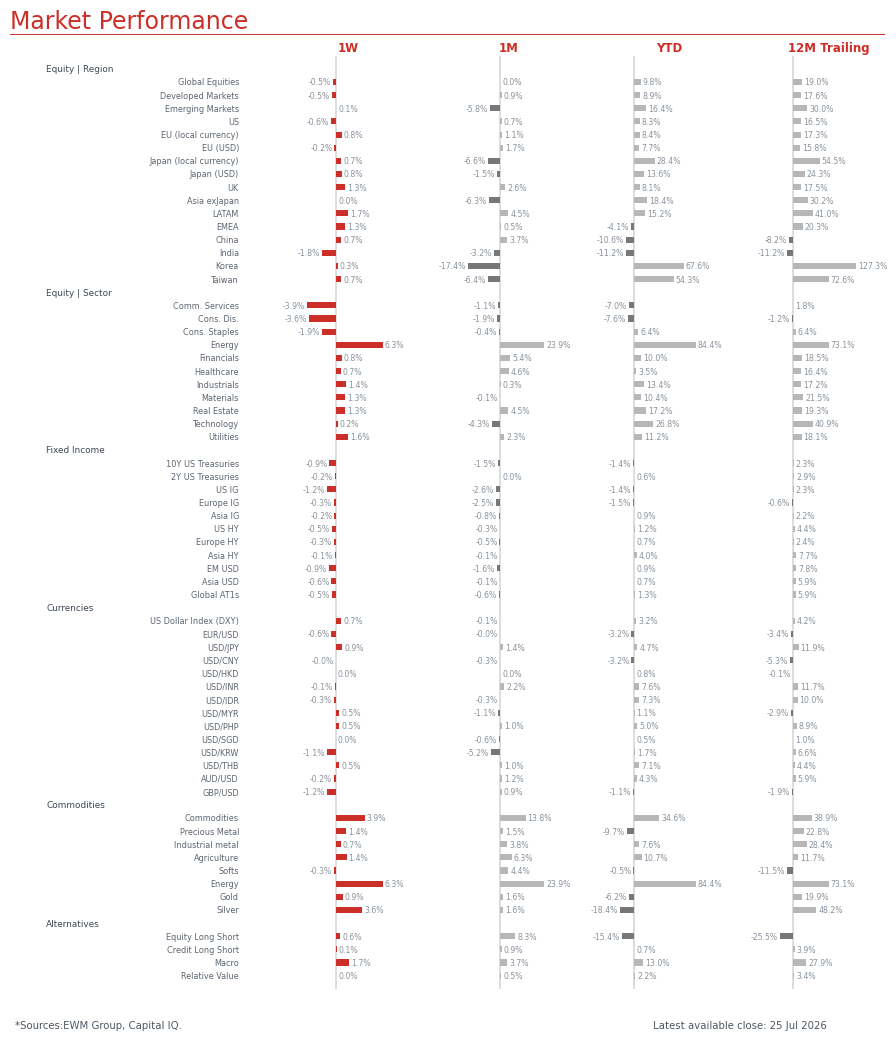

Saved chart to: EWM_market_performance_today.png


In [8]:
#@title Daily Market Monitoring System { display-mode: "form" }

import subprocess
subprocess.run(["pip", "install", "yfinance", "pandas", "numpy", "matplotlib", "-q"], check=False)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ==========================================================
# 1. Asset map
#    用公开 Yahoo ticker / ETF proxy
#    如果你有 Bloomberg/MSCI/HFR 官方 ticker，替换这里即可
# ==========================================================

ASSET_MAP = [
    # ---------------- Equity | Region ----------------
    {"group": "Equity | Region", "name": "Global Equities", "tickers": ["ACWI"]},
    {"group": "Equity | Region", "name": "Developed Markets", "tickers": ["URTH", "VEA"]},
    {"group": "Equity | Region", "name": "Emerging Markets", "tickers": ["EEM", "VWO"]},
    {"group": "Equity | Region", "name": "US", "tickers": ["^GSPC", "SPY"]},
    {"group": "Equity | Region", "name": "EU (local currency)", "tickers": ["^STOXX50E", "^STOXX", "FEZ"]},
    {"group": "Equity | Region", "name": "EU (USD)", "tickers": ["VGK", "IEUR"]},
    {"group": "Equity | Region", "name": "Japan (local currency)", "tickers": ["^N225"]},
    {"group": "Equity | Region", "name": "Japan (USD)", "tickers": ["EWJ"]},
    {"group": "Equity | Region", "name": "UK", "tickers": ["^FTSE", "EWU"]},
    {"group": "Equity | Region", "name": "Asia exJapan", "tickers": ["AAXJ"]},
    {"group": "Equity | Region", "name": "LATAM", "tickers": ["ILF"]},
    {"group": "Equity | Region", "name": "EMEA", "tickers": ["EEME.L", "GAF", "AFK"]},
    {"group": "Equity | Region", "name": "China", "tickers": ["MCHI", "FXI"]},
    {"group": "Equity | Region", "name": "India", "tickers": ["INDA", "EPI"]},
    {"group": "Equity | Region", "name": "Korea", "tickers": ["EWY"]},
    {"group": "Equity | Region", "name": "Taiwan", "tickers": ["EWT"]},

    # ---------------- Equity | Sector ----------------
    {"group": "Equity | Sector", "name": "Comm. Services", "tickers": ["IXP", "XLC"]},
    {"group": "Equity | Sector", "name": "Cons. Dis.", "tickers": ["RXI", "XLY"]},
    {"group": "Equity | Sector", "name": "Cons. Staples", "tickers": ["KXI", "XLP"]},
    {"group": "Equity | Sector", "name": "Energy", "tickers": ["IXC", "XLE"]},
    {"group": "Equity | Sector", "name": "Financials", "tickers": ["IXG", "XLF"]},
    {"group": "Equity | Sector", "name": "Healthcare", "tickers": ["IXJ", "XLV"]},
    {"group": "Equity | Sector", "name": "Industrials", "tickers": ["EXI", "XLI"]},
    {"group": "Equity | Sector", "name": "Materials", "tickers": ["MXI", "XLB"]},
    {"group": "Equity | Sector", "name": "Real Estate", "tickers": ["REET", "XLRE"]},
    {"group": "Equity | Sector", "name": "Technology", "tickers": ["IXN", "XLK"]},
    {"group": "Equity | Sector", "name": "Utilities", "tickers": ["JXI", "XLU"]},

    # ---------------- Fixed Income ----------------
    {"group": "Fixed Income", "name": "10Y US Treasuries", "tickers": ["IEF"]},
    {"group": "Fixed Income", "name": "2Y US Treasuries", "tickers": ["SHY"]},
    {"group": "Fixed Income", "name": "US IG", "tickers": ["LQD"]},
    {"group": "Fixed Income", "name": "Europe IG", "tickers": ["IEAC.L", "BNDX"]},
    {"group": "Fixed Income", "name": "Asia IG", "tickers": ["IAGG", "AGGG.L"]},
    {"group": "Fixed Income", "name": "US HY", "tickers": ["HYG", "JNK"]},
    {"group": "Fixed Income", "name": "Europe HY", "tickers": ["IHYG.L", "HYXU"]},
    {"group": "Fixed Income", "name": "Asia HY", "tickers": ["AHYG.L", "HYEM"]},
    {"group": "Fixed Income", "name": "EM USD", "tickers": ["EMB"]},
    {"group": "Fixed Income", "name": "Asia USD", "tickers": ["EMLC", "IAGG"]},
    {"group": "Fixed Income", "name": "Global AT1s", "tickers": ["AT1.L", "COCO.L"]},

    # ---------------- Currencies ----------------
    {"group": "Currencies", "name": "US Dollar Index (DXY)", "tickers": ["DX-Y.NYB"]},
    {"group": "Currencies", "name": "EUR/USD", "tickers": ["EURUSD=X"]},
    {"group": "Currencies", "name": "USD/JPY", "tickers": ["JPY=X"]},
    {"group": "Currencies", "name": "USD/CNY", "tickers": ["CNY=X"]},
    {"group": "Currencies", "name": "USD/HKD", "tickers": ["HKD=X"]},
    {"group": "Currencies", "name": "USD/INR", "tickers": ["INR=X"]},
    {"group": "Currencies", "name": "USD/IDR", "tickers": ["IDR=X"]},
    {"group": "Currencies", "name": "USD/MYR", "tickers": ["MYR=X"]},
    {"group": "Currencies", "name": "USD/PHP", "tickers": ["PHP=X"]},
    {"group": "Currencies", "name": "USD/SGD", "tickers": ["SGD=X"]},
    {"group": "Currencies", "name": "USD/KRW", "tickers": ["KRW=X"]},
    {"group": "Currencies", "name": "USD/THB", "tickers": ["THB=X"]},
    {"group": "Currencies", "name": "AUD/USD", "tickers": ["AUDUSD=X"]},
    {"group": "Currencies", "name": "GBP/USD", "tickers": ["GBPUSD=X"]},

    # ---------------- Commodities ----------------
    {"group": "Commodities", "name": "Commodities", "tickers": ["DBC", "BCI"]},
    {"group": "Commodities", "name": "Precious Metal", "tickers": ["DBP", "GLTR"]},
    {"group": "Commodities", "name": "Industrial metal", "tickers": ["DBB", "CPER"]},
    {"group": "Commodities", "name": "Agriculture", "tickers": ["DBA", "CORN"]},
    {"group": "Commodities", "name": "Softs", "tickers": ["JO", "CANE", "NIB"]},
    {"group": "Commodities", "name": "Energy", "tickers": ["DBE", "USO"]},
    {"group": "Commodities", "name": "Gold", "tickers": ["GLD", "IAU"]},
    {"group": "Commodities", "name": "Silver", "tickers": ["SLV"]},

    # ---------------- Alternatives ----------------
    {"group": "Alternatives", "name": "Equity Long Short", "tickers": ["QMN", "BTAL"]},
    {"group": "Alternatives", "name": "Credit Long Short", "tickers": ["BKLN", "SRLN"]},
    {"group": "Alternatives", "name": "Macro", "tickers": ["DBMF", "KMLM"]},
    {"group": "Alternatives", "name": "Relative Value", "tickers": ["MNA", "QAI"]},
]


# ==========================================================
# 2. Download price data
# ==========================================================

def unique_tickers(asset_map):
    out = []
    for item in asset_map:
        for t in item["tickers"]:
            if t not in out:
                out.append(t)
    return out


def download_prices(tickers, start_date, end_date, chunk_size=40):
    all_close = []

    for i in range(0, len(tickers), chunk_size):
        batch = tickers[i:i + chunk_size]

        raw = yf.download(
            batch,
            start=start_date,
            end=end_date,
            auto_adjust=True,
            progress=False,
            threads=True,
        )

        if raw.empty:
            continue

        if isinstance(raw.columns, pd.MultiIndex):
            if "Close" in raw.columns.get_level_values(0):
                close = raw["Close"].copy()
            elif "Adj Close" in raw.columns.get_level_values(0):
                close = raw["Adj Close"].copy()
            else:
                continue
        else:
            if "Close" in raw.columns:
                close = raw[["Close"]].copy()
                close.columns = batch[:1]
            elif "Adj Close" in raw.columns:
                close = raw[["Adj Close"]].copy()
                close.columns = batch[:1]
            else:
                continue

        all_close.append(close)

    if not all_close:
        raise RuntimeError("No data downloaded. Check yfinance connection.")

    prices = pd.concat(all_close, axis=1)
    prices = prices.loc[:, ~prices.columns.duplicated()]
    prices.index = pd.to_datetime(prices.index).tz_localize(None)
    prices = prices.sort_index()
    return prices


today = pd.Timestamp.today().normalize()
start = today - pd.DateOffset(days=550)
end = today + pd.DateOffset(days=1)

tickers = unique_tickers(ASSET_MAP)

prices = download_prices(
    tickers=tickers,
    start_date=start.strftime("%Y-%m-%d"),
    end_date=end.strftime("%Y-%m-%d"),
)

print(f"Downloaded price data: {prices.index.min().date()} → {prices.index.max().date()}")
print(f"Tickers downloaded: {prices.shape[1]}")


# ==========================================================
# 3. Pick first valid proxy for each asset
# ==========================================================

def pick_ticker(ticker_list, prices, min_obs=40):
    for t in ticker_list:
        if t in prices.columns:
            s = prices[t].dropna()
            if len(s) >= min_obs:
                return t
    return None


selected = {}
for item in ASSET_MAP:
    selected[item["name"]] = pick_ticker(item["tickers"], prices)


failed = [k for k, v in selected.items() if v is None]
if failed:
    print("\nNo valid data for:")
    for x in failed:
        print(" -", x)


# ==========================================================
# 4. Calculate returns
# ==========================================================

PERIODS = ["1W", "1M", "YTD", "12M Trailing"]


def price_on_or_before(series, target_date):
    s = series.dropna()
    if s.empty:
        return np.nan

    target_date = pd.Timestamp(target_date)
    eligible = s.loc[s.index <= target_date]

    if eligible.empty:
        return np.nan

    return eligible.iloc[-1]


def calc_returns(series):
    s = series.dropna()
    if s.empty:
        return {p: np.nan for p in PERIODS}, None

    latest_date = s.index.max()
    latest_px = s.loc[latest_date]

    anchors = {
        "1W": latest_date - pd.Timedelta(days=7),
        "1M": latest_date - pd.DateOffset(months=1),
        "YTD": pd.Timestamp(year=latest_date.year, month=1, day=1) - pd.Timedelta(days=1),
        "12M Trailing": latest_date - pd.DateOffset(years=1),
    }

    out = {}
    for p, anchor_date in anchors.items():
        base_px = price_on_or_before(s, anchor_date)

        if pd.isna(base_px) or base_px == 0:
            out[p] = np.nan
        else:
            out[p] = (latest_px / base_px - 1.0) * 100.0

    return out, latest_date


records = []
asof_dates = {}

for item in ASSET_MAP:
    name = item["name"]
    t = selected.get(name)

    if t is None:
        row = {"Group": item["group"], "Name": name, "Ticker": None}
        for p in PERIODS:
            row[p] = np.nan
        asof_dates[name] = None
    else:
        ret, asof = calc_returns(prices[t])
        row = {"Group": item["group"], "Name": name, "Ticker": t}
        row.update(ret)
        asof_dates[name] = asof

    records.append(row)


ret_df = pd.DataFrame(records)

global_asof = max([d for d in asof_dates.values() if d is not None])
print(f"\nLatest available date: {global_asof.date()}")

# # Save table
# ret_df.to_csv("market_performance_today.csv", index=False)


# ==========================================================
# 5. Build rows with group headers
# ==========================================================

plot_rows = []
last_group = None

for _, r in ret_df.iterrows():
    if r["Group"] != last_group:
        plot_rows.append({
            "type": "header",
            "label": r["Group"],
            "name": None,
        })
        last_group = r["Group"]

    plot_rows.append({
        "type": "asset",
        "label": r["Name"],
        "name": r["Name"],
    })


# ==========================================================
# 6. Plot function
# ==========================================================

def plot_market_performance(ret_df, plot_rows, global_asof, output_png="market_performance_today.png"):
    red = "#cc2f27"
    grey = "#b7b7b7"
    dark_grey = "#777777"
    light_axis = "#d7d7d7"
    text_grey = "#5c6570"

    n = len(plot_rows)
    y_positions = np.arange(n)[::-1]

    fig_h = max(10.5, n * 0.155)
    fig = plt.figure(figsize=(9.2, fig_h), facecolor="white")

    gs = fig.add_gridspec(
        nrows=1,
        ncols=5,
        width_ratios=[2.35, 1.15, 1.15, 1.15, 1.15],
        left=0.045,
        right=0.985,
        top=0.925,
        bottom=0.065,
        wspace=0.38,
    )

    ax_label = fig.add_subplot(gs[0, 0])
    axes = [fig.add_subplot(gs[0, i]) for i in range(1, 5)]

    # Title
    fig.text(
        0.035,
        0.968,
        "Market Performance",
        fontsize=17,
        color=red,
        ha="left",
        va="top",
        fontweight="normal",
    )

    fig.add_artist(
        Line2D(
            [0.035, 0.985],
            [0.945, 0.945],
            transform=fig.transFigure,
            color=red,
            lw=0.7,
        )
    )

    # Left label axis
    ax_label.set_xlim(0, 1)
    ax_label.set_ylim(-1, n)
    ax_label.axis("off")

    for i, row in enumerate(plot_rows):
        y = y_positions[i]

        if row["type"] == "header":
            ax_label.text(
                0.12,
                y,
                row["label"],
                ha="left",
                va="center",
                fontsize=6.4,
                color="#3f4954",
                fontweight="normal",
            )
        else:
            ax_label.text(
                0.98,
                y,
                row["label"],
                ha="right",
                va="center",
                fontsize=5.9,
                color=text_grey,
            )

    # Period charts
    for ax, period in zip(axes, PERIODS):
        vals = []
        ys = []

        for i, row in enumerate(plot_rows):
            if row["type"] != "asset":
                continue

            name = row["name"]
            v = ret_df.loc[ret_df["Name"] == name, period].values[0]
            if pd.isna(v):
                continue

            vals.append(v)
            ys.append(y_positions[i])

        vals = np.array(vals, dtype=float)

        if len(vals) == 0:
            xmin, xmax = -1, 1
        else:
            max_pos = max(0.5, np.nanmax(vals[vals >= 0]) if np.any(vals >= 0) else 0.5)
            max_neg = max(0.5, abs(np.nanmin(vals[vals < 0])) if np.any(vals < 0) else 0.5)

            # leave room for value labels
            xmin = -max_neg * 1.45
            xmax = max_pos * 1.45

            # avoid too narrow axis
            if xmax - xmin < 4:
                mid = (xmax + xmin) / 2
                xmin = mid - 2
                xmax = mid + 2

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(-1, n)

        ax.axvline(0, color=light_axis, lw=1.2, zorder=0)

        # Remove all decorations
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_title(
            period,
            fontsize=8.5,
            color=red,
            fontweight="bold",
            pad=3,
        )

        offset = (xmax - xmin) * 0.018

        for i, row in enumerate(plot_rows):
            if row["type"] != "asset":
                continue

            name = row["name"]
            v = ret_df.loc[ret_df["Name"] == name, period].values[0]
            if pd.isna(v):
                continue

            y = y_positions[i]

            if period == "1W":
                bar_color = red
            else:
                bar_color = grey if v >= 0 else dark_grey

            ax.barh(
                y,
                v,
                height=0.46,
                color=bar_color,
                edgecolor="none",
                zorder=2,
            )

            # value label
            label = f"{v:.1f}%"

            if v >= 0:
                x_text = v + offset
                ha = "left"
            else:
                x_text = v - offset
                ha = "right"

            ax.text(
                x_text,
                y,
                label,
                ha=ha,
                va="center",
                fontsize=5.6,
                color="#8a939c",
                clip_on=False,
            )

    # Footnote
    fig.text(
        0.04,
        0.027,
        f"*Sources:EWM Group, Capital IQ.                                                                                                                                                 Latest available close: {global_asof.strftime('%d %b %Y')}",
        fontsize=7.3,
        color="#4d5660",
        ha="left",
        va="bottom",
    )

    plt.savefig(output_png, dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()

    print(f"Saved chart to: {output_png}")


plot_market_performance(
    ret_df=ret_df,
    plot_rows=plot_rows,
    global_asof=global_asof,
    output_png="EWM_market_performance_today.png",
)

In [9]:
 "490ed0ef6adef36a548539c3e6da425e"

JSONDecodeError: Extra data: line 1 column 9 (char 8)

In [20]:

from __future__ import annotations

import os
import random
import time
from io import BytesIO
from datetime import date, timedelta
from getpass import getpass
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import requests


# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
BASE_URL = "https://financialmodelingprep.com/stable"
CACHE_DIR = Path("fmp_cache")
CACHE_DIR.mkdir(exist_ok=True)

# Bulk files are large. Keep requests sequential and pause between downloads.
BULK_PAUSE_SECONDS = 12
MAX_RETRIES = 8
REQUEST_TIMEOUT = 180

# Set to "close" for share-price return only.
# Set to "adjClose" for dividend-adjusted total shareholder return.
PRICE_FIELD = "close"

# Similar ranges to the reference chart. Change to None for automatic limits.
X_LIM = (-20, 80)
Y_LIM = (-20, 50)

# Optional text labels for the largest bubbles on chart itself. Hover always works.
LABEL_TOP_N = 0

API_KEY =  "490ed0ef6adef36a548539c3e6da425e"
if not API_KEY:
    raise ValueError("FMP API key is required.")

SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "sp500-roic-growth-chart-interactive/1.0"})


# -----------------------------------------------------------------------------
# API and cache helpers
# -----------------------------------------------------------------------------
def safe_cache_name(endpoint: str, params: dict | None = None) -> str:
    parts = [endpoint.replace("/", "_")]
    for key, value in sorted((params or {}).items()):
        text = str(value).replace("/", "-").replace(",", "_")
        if len(text) > 80:
            text = f"hash{abs(hash(text))}"
        parts.append(f"{key}-{text}")
    return "__".join(parts) + ".pkl.gz"


def request_data(endpoint: str, params: dict | None = None) -> pd.DataFrame | list | dict:
    """Download an FMP endpoint and parse either JSON or CSV."""
    url = f"{BASE_URL}/{endpoint.lstrip('/')}"
    query = dict(params or {})
    query["apikey"] = API_KEY

    for attempt in range(MAX_RETRIES):
        try:
            response = SESSION.get(url, params=query, timeout=REQUEST_TIMEOUT)

            if response.status_code == 429:
                retry_after = response.headers.get("Retry-After")
                wait = float(retry_after) if retry_after else min(
                    180, 15 * (2**attempt) + random.uniform(0, 5)
                )
                print(f"429 rate limit: waiting {wait:.0f}s for {endpoint} ...")
                time.sleep(wait)
                continue

            response.raise_for_status()

            raw = response.content
            if not raw:
                return pd.DataFrame()

            stripped = raw.lstrip(b"\xef\xbb\xbf \t\r\n")
            first_char = stripped[:1]

            if first_char in (b"[", b"{"):
                data = response.json()
                if isinstance(data, dict):
                    error_text = (
                        data.get("Error Message")
                        or data.get("error")
                        or data.get("message")
                    )
                    if error_text:
                        raise RuntimeError(f"FMP error for {endpoint}: {error_text}")
                return data

            frame = pd.read_csv(BytesIO(raw), low_memory=False)
            if frame.shape[1] <= 1:
                preview = response.text[:500].strip()
                raise RuntimeError(
                    f"Unexpected non-JSON/non-tabular response for {endpoint}: {preview}"
                )
            return frame

        except (requests.RequestException, pd.errors.ParserError, UnicodeError) as exc:
            if attempt == MAX_RETRIES - 1:
                raise
            wait = min(120, 5 * (2**attempt) + random.uniform(0, 3))
            print(f"Request failed ({exc}); retrying in {wait:.0f}s ...")
            time.sleep(wait)

    raise RuntimeError(f"Failed to download {endpoint}")


def fmp_df(
    endpoint: str,
    params: dict | None = None,
    *,
    cache_name: str | None = None,
    force_refresh: bool = False,
) -> pd.DataFrame:
    cache_file = CACHE_DIR / (cache_name or safe_cache_name(endpoint, params))

    if cache_file.exists() and not force_refresh:
        return pd.read_pickle(cache_file, compression="gzip")

    data = request_data(endpoint, params)
    if isinstance(data, pd.DataFrame):
        df = data
    elif isinstance(data, list):
        df = pd.DataFrame(data)
    elif isinstance(data, dict):
        list_values = [value for value in data.values() if isinstance(value, list)]
        df = pd.DataFrame(list_values[0] if list_values else [data])
    else:
        df = pd.DataFrame()

    df.to_pickle(cache_file, compression="gzip")
    return df


def find_column(df: pd.DataFrame, candidates: Iterable[str], required: bool = True) -> str | None:
    exact = {column.lower(): column for column in df.columns}
    for candidate in candidates:
        if candidate.lower() in exact:
            return exact[candidate.lower()]

    normalised = {
        "".join(ch for ch in column.lower() if ch.isalnum()): column
        for column in df.columns
    }
    for candidate in candidates:
        key = "".join(ch for ch in candidate.lower() if ch.isalnum())
        if key in normalised:
            return normalised[key]

    if required:
        raise KeyError(
            f"None of {list(candidates)} found. Available columns: {list(df.columns)}"
        )
    return None


def join_symbol(series: pd.Series) -> pd.Series:
    """Normalise BRK.B/BRK-B-style variants for merging only."""
    return (
        series.astype(str)
        .str.strip()
        .str.upper()
        .str.replace(".", "-", regex=False)
    )


def to_percent(series: pd.Series) -> pd.Series:
    """Convert ratio-form values to percentage-form, without double multiplying."""
    values = pd.to_numeric(series, errors="coerce")
    typical = values.abs().replace([np.inf, -np.inf], np.nan).median()
    if pd.notna(typical) and typical <= 2:
        values = values * 100
    return values


def fmt_pct(value: float) -> str:
    if pd.isna(value):
        return "N/A"
    return f"{value:,.1f}%"


def fmt_bn(value: float) -> str:
    if pd.isna(value):
        return "N/A"
    return f"${value:,.1f}bn"


# -----------------------------------------------------------------------------
# Data downloads
# -----------------------------------------------------------------------------
print("Downloading S&P 500 constituents ...")
sp500 = fmp_df("sp500-constituent", cache_name="sp500_constituent.pkl.gz")
sp_symbol_col = find_column(sp500, ["symbol"])
sp_name_col = find_column(sp500, ["name", "companyName"], required=False)
sp_sector_col = find_column(sp500, ["sector"], required=False)

universe = pd.DataFrame({
    "api_symbol": sp500[sp_symbol_col].astype(str),
    "symbol": join_symbol(sp500[sp_symbol_col]),
    "company": (
        sp500[sp_name_col].astype(str)
        if sp_name_col
        else sp500[sp_symbol_col].astype(str)
    ),
    "sector": sp500[sp_sector_col].astype(str) if sp_sector_col else "Unknown",
}).drop_duplicates("symbol")

api_symbols = universe["api_symbol"].tolist()
symbol_set = set(universe["symbol"])
print(f"S&P 500 universe: {len(universe):,} securities")

print("Downloading TTM key metrics ...")
metrics_raw = fmp_df(
    "key-metrics-ttm-bulk",
    cache_name="key_metrics_ttm_bulk.pkl.gz",
)
metrics_symbol_col = find_column(metrics_raw, ["symbol"])
roic_col = find_column(
    metrics_raw,
    [
        "returnOnInvestedCapitalTTM",
        "roicTTM",
        "returnOnInvestedCapital",
        "roic",
    ],
)

metrics = pd.DataFrame({
    "symbol": join_symbol(metrics_raw[metrics_symbol_col]),
    "roic_pct": to_percent(metrics_raw[roic_col]),
})
metrics = metrics[metrics["symbol"].isin(symbol_set)].drop_duplicates("symbol", keep="first")

print("Downloading current market capitalisations in batches ...")
market_cap_frames: list[pd.DataFrame] = []
chunk_size = 150
for start in range(0, len(api_symbols), chunk_size):
    chunk = api_symbols[start : start + chunk_size]
    chunk_id = start // chunk_size
    frame = fmp_df(
        "market-capitalization-batch",
        {"symbols": ",".join(chunk)},
        cache_name=f"market_cap_batch_{chunk_id}.pkl.gz",
    )
    market_cap_frames.append(frame)
    if start + chunk_size < len(api_symbols):
        time.sleep(2)

market_cap_raw = pd.concat(market_cap_frames, ignore_index=True)
mc_symbol_col = find_column(market_cap_raw, ["symbol"])
mc_col = find_column(market_cap_raw, ["marketCap", "marketCapitalization"])
market_caps = pd.DataFrame({
    "symbol": join_symbol(market_cap_raw[mc_symbol_col]),
    "market_cap": pd.to_numeric(market_cap_raw[mc_col], errors="coerce"),
}).drop_duplicates("symbol", keep="first")

print("Downloading annual income statements ...")
current_year = date.today().year
income_frames: list[pd.DataFrame] = []
for year in range(current_year, current_year - 6, -1):
    frame = fmp_df(
        "income-statement-bulk",
        {"year": year, "period": "FY"},
        cache_name=f"income_statement_FY_{year}.pkl.gz",
    )
    if not frame.empty:
        income_frames.append(frame)
        print(f"  FY {year}: {len(frame):,} rows")
    if year > current_year - 5:
        time.sleep(BULK_PAUSE_SECONDS)

if not income_frames:
    raise RuntimeError("No annual income-statement bulk data was returned.")

income_raw = pd.concat(income_frames, ignore_index=True)
income_symbol_col = find_column(income_raw, ["symbol"])
income_date_col = find_column(income_raw, ["date", "fillingDate", "fiscalDateEnding"])
revenue_col = find_column(income_raw, ["revenue"])

income = pd.DataFrame({
    "symbol": join_symbol(income_raw[income_symbol_col]),
    "fiscal_date": pd.to_datetime(income_raw[income_date_col], errors="coerce"),
    "revenue": pd.to_numeric(income_raw[revenue_col], errors="coerce"),
})
income = income[
    income["symbol"].isin(symbol_set)
    & income["fiscal_date"].notna()
    & income["revenue"].gt(0)
]
income = income.drop_duplicates(["symbol", "fiscal_date"], keep="last")


def three_year_revenue_cagr(group: pd.DataFrame) -> pd.Series:
    group = group.sort_values("fiscal_date")
    latest = group.iloc[-1]
    target_date = latest["fiscal_date"] - pd.DateOffset(years=3)

    older = group[group["fiscal_date"] < latest["fiscal_date"]].copy()
    if older.empty:
        return pd.Series({"revenue_cagr_3y_pct": np.nan})

    older["distance"] = (older["fiscal_date"] - target_date).abs()
    prior = older.loc[older["distance"].idxmin()]
    elapsed_years = (latest["fiscal_date"] - prior["fiscal_date"]).days / 365.25

    if not (2.5 <= elapsed_years <= 3.5):
        return pd.Series({"revenue_cagr_3y_pct": np.nan})

    cagr = (latest["revenue"] / prior["revenue"]) ** (1 / elapsed_years) - 1
    return pd.Series({"revenue_cagr_3y_pct": cagr * 100})


revenue_growth_records = []
for symbol, group in income.groupby("symbol"):
    result = three_year_revenue_cagr(group)
    revenue_growth_records.append({
        "symbol": symbol,
        "revenue_cagr_3y_pct": result["revenue_cagr_3y_pct"],
    })
revenue_growth = pd.DataFrame(revenue_growth_records)


def eod_for_or_before(target_date: date, max_lookback_days: int = 10) -> tuple[pd.DataFrame, date]:
    for days_back in range(max_lookback_days + 1):
        candidate = target_date - timedelta(days=days_back)
        frame = fmp_df(
            "eod-bulk",
            {"date": candidate.isoformat()},
            cache_name=f"eod_bulk_{candidate.isoformat()}.pkl.gz",
        )
        if frame.empty:
            continue

        symbol_col = find_column(frame, ["symbol"])
        filtered = frame[join_symbol(frame[symbol_col]).isin(symbol_set)].copy()
        if len(filtered) >= 300:
            return filtered, candidate

    raise RuntimeError(f"No usable EOD bulk file found on or before {target_date}")


print("Downloading latest and one-year-ago EOD prices ...")
latest_eod, latest_date = eod_for_or_before(date.today())
prior_target = (pd.Timestamp(latest_date) - pd.DateOffset(years=1)).date()
prior_eod, prior_date = eod_for_or_before(prior_target)

latest_symbol_col = find_column(latest_eod, ["symbol"])
prior_symbol_col = find_column(prior_eod, ["symbol"])
latest_price_col = find_column(latest_eod, [PRICE_FIELD, "close", "adjClose"])
prior_price_col = find_column(prior_eod, [PRICE_FIELD, "close", "adjClose"])

latest_prices = pd.DataFrame({
    "symbol": join_symbol(latest_eod[latest_symbol_col]),
    "price_now": pd.to_numeric(latest_eod[latest_price_col], errors="coerce"),
}).drop_duplicates("symbol", keep="first")

prior_prices = pd.DataFrame({
    "symbol": join_symbol(prior_eod[prior_symbol_col]),
    "price_1y_ago": pd.to_numeric(prior_eod[prior_price_col], errors="coerce"),
}).drop_duplicates("symbol", keep="first")

price_returns = latest_prices.merge(prior_prices, on="symbol", how="inner")
price_returns["price_return_1y_pct"] = (
    price_returns["price_now"] / price_returns["price_1y_ago"] - 1
) * 100


# -----------------------------------------------------------------------------
# Merge and clean
# -----------------------------------------------------------------------------
chart_data = (
    universe
    .merge(metrics, on="symbol", how="left")
    .merge(revenue_growth, on="symbol", how="left")
    .merge(market_caps, on="symbol", how="left")
    .merge(price_returns[["symbol", "price_return_1y_pct"]], on="symbol", how="left")
)

chart_data = chart_data.replace([np.inf, -np.inf], np.nan)
chart_data = chart_data.dropna(
    subset=["roic_pct", "revenue_cagr_3y_pct", "market_cap", "price_return_1y_pct"]
)
chart_data = chart_data[chart_data["market_cap"] > 0].copy()
chart_data["market_cap_bn"] = chart_data["market_cap"] / 1e9


def return_bucket(value: float) -> str:
    if value > 20:
        return "Above 20%"
    if value >= 7.5:
        return "7.5%-20%"
    if value >= 0:
        return "0%-7.5%"
    return "Below 0%"


bucket_order = ["Above 20%", "7.5%-20%", "0%-7.5%", "Below 0%"]
chart_data["return_bucket"] = pd.Categorical(
    chart_data["price_return_1y_pct"].map(return_bucket),
    categories=bucket_order,
    ordered=True,
)

# Log market cap prevents mega-caps from overwhelming all other bubbles.
log_cap = np.log10(chart_data["market_cap_bn"].clip(lower=0.1))
if log_cap.max() == log_cap.min():
    chart_data["bubble_size"] = 18
else:
    chart_data["bubble_size"] = 10 + 34 * (
        (log_cap - log_cap.min()) / (log_cap.max() - log_cap.min())
    )

chart_data = chart_data.sort_values("market_cap", ascending=False)
chart_data["label"] = ""
if LABEL_TOP_N > 0:
    chart_data.loc[chart_data.head(LABEL_TOP_N).index, "label"] = chart_data.loc[
        chart_data.head(LABEL_TOP_N).index, "api_symbol"
    ]

chart_data["roic_display"] = chart_data["roic_pct"].map(fmt_pct)
chart_data["revenue_display"] = chart_data["revenue_cagr_3y_pct"].map(fmt_pct)
chart_data["return_display"] = chart_data["price_return_1y_pct"].map(fmt_pct)
chart_data["market_cap_display"] = chart_data["market_cap_bn"].map(fmt_bn)

print(f"Usable companies in chart: {len(chart_data):,}")
print(f"Price period: {prior_date} to {latest_date}")


# -----------------------------------------------------------------------------
# Interactive Plotly chart
# -----------------------------------------------------------------------------


S&P 500 universe: 503 securities
  FY 2026: 7,332 rows
  FY 2025: 51,083 rows
  FY 2024: 55,176 rows
  FY 2023: 57,997 rows
  FY 2022: 61,215 rows
  FY 2021: 63,036 rows
Usable companies in chart: 498
Price period: 2025-07-24 to 2026-07-24


In [22]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go


# ============================================================
# Plotly interactive bubble chart
#
# X-axis       = ROIC (TTM)
# Y-axis       = Revenue Growth (3-year CAGR)
# Bubble size  = Market Capitalisation, log-scaled
# Bubble color = 1-Year Share Price Return
# ============================================================


# ------------------------------------------------------------
# 需要提前准备好的变量
# ------------------------------------------------------------
# chart_data 至少需要包含以下列：
#
# api_symbol
# company
# sector
# roic_pct
# revenue_cagr_3y_pct
# market_cap_bn
# price_return_1y_pct
#
# prior_date 和 latest_date 用于底部数据来源说明，例如：
#
# prior_date = "2025-07-24"
# latest_date = "2026-07-24"
#
# 如果没有定义日期，下面会自动使用通用文字。


# ------------------------------------------------------------
# 复制数据，避免修改原始 DataFrame
# ------------------------------------------------------------
chart_data = chart_data.copy()


# ------------------------------------------------------------
# 检查必要字段
# ------------------------------------------------------------
required_columns = [
    "api_symbol",
    "company",
    "sector",
    "roic_pct",
    "revenue_cagr_3y_pct",
    "market_cap_bn",
    "price_return_1y_pct",
]

missing_columns = [
    column
    for column in required_columns
    if column not in chart_data.columns
]

if missing_columns:
    raise ValueError(
        "chart_data 缺少以下必要字段："
        + ", ".join(missing_columns)
    )


# ------------------------------------------------------------
# 转换数值列
# ------------------------------------------------------------
numeric_columns = [
    "roic_pct",
    "revenue_cagr_3y_pct",
    "market_cap_bn",
    "price_return_1y_pct",
]

for column in numeric_columns:
    chart_data[column] = pd.to_numeric(
        chart_data[column],
        errors="coerce",
    )


# ------------------------------------------------------------
# 清理缺失值和无效数据
# ------------------------------------------------------------
chart_data = chart_data.dropna(
    subset=[
        "roic_pct",
        "revenue_cagr_3y_pct",
        "market_cap_bn",
        "price_return_1y_pct",
    ]
).copy()

chart_data = chart_data[
    chart_data["market_cap_bn"] > 0
].copy()

if chart_data.empty:
    raise ValueError(
        "清理缺失值和无效市值后，chart_data 没有可绘制的数据。"
    )


# ------------------------------------------------------------
# 设定 1-Year Share Price Return 区间
# ------------------------------------------------------------
bucket_order = [
    "Above 20%",
    "7.5%-20%",
    "0%-7.5%",
    "Below 0%",
]


def assign_return_bucket(return_pct):
    """
    根据过去一年股价回报划分颜色区间。
    """
    if return_pct > 20:
        return "Above 20%"
    elif return_pct >= 7.5:
        return "7.5%-20%"
    elif return_pct >= 0:
        return "0%-7.5%"
    else:
        return "Below 0%"


chart_data["return_bucket"] = (
    chart_data["price_return_1y_pct"]
    .apply(assign_return_bucket)
)


# ------------------------------------------------------------
# 每个回报区间对应的颜色
# ------------------------------------------------------------
colours = {
    "Above 20%": "#2447D8",
    "7.5%-20%": "#A9B58D",
    "0%-7.5%": "#F2B632",
    "Below 0%": "#EA382B",
}


# ------------------------------------------------------------
# 设置 Plotly 气泡大小
#
# Plotly 的 marker.size 使用像素直径。
# 为了避免超大市值公司完全压制其他公司，
# 这里先对市值取 log10，再缩放到 8-46 像素。
# ------------------------------------------------------------
log_market_cap = np.log10(
    chart_data["market_cap_bn"].clip(lower=0.1)
)

log_cap_min = log_market_cap.min()
log_cap_max = log_market_cap.max()

if np.isclose(log_cap_max, log_cap_min):
    chart_data["plotly_bubble_size"] = 18.0
else:
    chart_data["plotly_bubble_size"] = (
        8
        + 38
        * (
            (log_market_cap - log_cap_min)
            / (log_cap_max - log_cap_min)
        )
    )


# ------------------------------------------------------------
# 日期说明
# ------------------------------------------------------------
try:
    source_date_text = (
        f"Prices: {prior_date} to {latest_date}."
    )
except NameError:
    source_date_text = "Prices: trailing 1-year period."


# ------------------------------------------------------------
# 创建图表
# ------------------------------------------------------------
fig = go.Figure()


# ------------------------------------------------------------
# 每个 1-Year Price Return 区间建立一个 trace
#
# 好处：
# 1. 图例可以单独开关不同回报区间
# 2. 每个区间可以使用独立颜色
# ------------------------------------------------------------
for bucket in bucket_order:

    subset = chart_data[
        chart_data["return_bucket"] == bucket
    ].copy()

    if subset.empty:
        continue

    # Hover 中显示的附加数据
    customdata = np.column_stack([
        subset["api_symbol"].astype(str),
        subset["company"].astype(str),
        subset["sector"].astype(str),
        subset["market_cap_bn"],
        subset["price_return_1y_pct"],
    ])

    fig.add_trace(
        go.Scatter(
            x=subset["roic_pct"],
            y=subset["revenue_cagr_3y_pct"],

            mode="markers",

            name=bucket,

            marker=dict(
                size=subset["plotly_bubble_size"],
                color=colours[bucket],
                opacity=0.90,

                line=dict(
                    width=0.7,
                    color="rgba(255,255,255,0.65)",
                ),
            ),

            customdata=customdata,

            hovertemplate=(
                "<b>%{customdata[1]}</b><br>"
                "Ticker: %{customdata[0]}<br>"
                "Sector: %{customdata[2]}<br>"
                "Market Cap: $%{customdata[3]:,.1f}bn<br>"
                "ROIC (TTM): %{x:.1f}%<br>"
                "Revenue Growth (3Y CAGR): %{y:.1f}%<br>"
                "<b>1-Year Share Price Return: "
                "%{customdata[4]:+.1f}%</b>"
                "<extra></extra>"
            ),
        )
    )


# ------------------------------------------------------------
# 坐标轴刻度
# ------------------------------------------------------------
x_tick_values = list(range(-20, 81, 10))
y_tick_values = list(range(-20, 51, 10))


def percentage_tick_labels(values):
    """
    将负数显示为会计格式，例如：
    -20 -> (20%)
     10 -> 10%
    """
    return [
        f"({abs(value)}%)"
        if value < 0
        else f"{value}%"
        for value in values
    ]


# ------------------------------------------------------------
# 图表整体格式
# ------------------------------------------------------------
fig.update_layout(

    width=1400,
    height=950,

    paper_bgcolor="#F4F7F2",
    plot_bgcolor="#F4F7F2",

    title=dict(
        text=(
            "<b>S&P 500: ROIC, Revenue Growth and "
            "1-Year Share Price Return</b>"
            "<br>"
            "<span style='font-size:17px;color:#606060'>"
            "Bubble Size = Market Capitalisation | "
            "Colour = 1-Year Share Price Return"
            "</span>"
        ),

        x=0.02,
        xanchor="left",

        y=0.97,
        yanchor="top",

        font=dict(
            size=27,
            color="#28613E",
        ),
    ),

    legend=dict(
        orientation="h",

        x=0.5,
        xanchor="center",

        y=1.03,
        yanchor="bottom",

        title=None,

        font=dict(
            size=13,
            color="#606060",
        ),

        bgcolor="rgba(0,0,0,0)",

        itemclick="toggle",
        itemdoubleclick="toggleothers",
    ),

    margin=dict(
        l=100,
        r=50,
        t=155,
        b=135,
    ),

    hovermode="closest",

    hoverlabel=dict(
        bgcolor="white",
        bordercolor="#999999",

        font=dict(
            size=13,
            color="#222222",
        ),
    ),

    annotations=[

        dict(
            text=(
                "<i>Bubble size indicates relative market "
                "capitalisation, log-scaled</i>"
            ),

            x=0.5,
            y=-0.12,

            xref="paper",
            yref="paper",

            xanchor="center",

            showarrow=False,

            font=dict(
                size=15,
                color="#222222",
            ),
        ),

        dict(
            text=(
                "Source: Financial Modeling Prep. "
                f"{source_date_text} "
                "Colour represents 1-year share price return; "
                "revenue growth is fiscal-year CAGR."
            ),

            x=0,
            y=-0.18,

            xref="paper",
            yref="paper",

            xanchor="left",

            showarrow=False,

            font=dict(
                size=10,
                color="#7C817E",
            ),
        ),
    ],
)


# ------------------------------------------------------------
# X轴：ROIC
# ------------------------------------------------------------
fig.update_xaxes(

    title=dict(
        text="<b>ROIC (TTM)</b>",
        font=dict(size=18),
    ),

    range=[-20, 80],

    tickmode="array",
    tickvals=x_tick_values,
    ticktext=percentage_tick_labels(
        x_tick_values
    ),

    tickfont=dict(
        size=13,
        color="#59605E",
    ),

    showgrid=False,

    showline=True,
    linecolor="#C3C8C4",
    linewidth=1,

    zeroline=True,
    zerolinecolor="#BFC5C0",
    zerolinewidth=1.3,

    fixedrange=False,
)


# ------------------------------------------------------------
# Y轴：Revenue Growth 3-Year CAGR
# ------------------------------------------------------------
fig.update_yaxes(

    title=dict(
        text="<b>Revenue Growth — 3-Year CAGR</b>",
        font=dict(size=18),
    ),

    range=[-20, 50],

    tickmode="array",
    tickvals=y_tick_values,
    ticktext=percentage_tick_labels(
        y_tick_values
    ),

    tickfont=dict(
        size=13,
        color="#59605E",
    ),

    showgrid=False,

    showline=True,
    linecolor="#C3C8C4",
    linewidth=1,

    zeroline=True,
    zerolinecolor="#BFC5C0",
    zerolinewidth=1.3,

    fixedrange=False,
)


# ------------------------------------------------------------
# 添加参考线，可帮助识别四个象限
# ------------------------------------------------------------

# ROIC = 10%
fig.add_vline(
    x=10,
    line_width=1,
    line_dash="dot",
    line_color="rgba(90,100,95,0.45)",
)

# Revenue Growth = 10%
fig.add_hline(
    y=10,
    line_width=1,
    line_dash="dot",
    line_color="rgba(90,100,95,0.45)",
)


# ------------------------------------------------------------
# 添加象限说明
# ------------------------------------------------------------
fig.add_annotation(
    x=45,
    y=45,
    text="<b>High ROIC<br>High Growth</b>",
    showarrow=False,
    font=dict(
        size=12,
        color="rgba(40,97,62,0.60)",
    ),
)

fig.add_annotation(
    x=45,
    y=-15,
    text="<b>High ROIC<br>Low Growth</b>",
    showarrow=False,
    font=dict(
        size=12,
        color="rgba(40,97,62,0.60)",
    ),
)

fig.add_annotation(
    x=-15,
    y=45,
    text="<b>Low ROIC<br>High Growth</b>",
    showarrow=False,
    font=dict(
        size=12,
        color="rgba(40,97,62,0.60)",
    ),
)

fig.add_annotation(
    x=-15,
    y=-15,
    text="<b>Low ROIC<br>Low Growth</b>",
    showarrow=False,
    font=dict(
        size=12,
        color="rgba(40,97,62,0.60)",
    ),
)


# ------------------------------------------------------------
# 显示图表
# ------------------------------------------------------------
fig.show()


# ------------------------------------------------------------
# 保存为独立交互 HTML
#
# include_plotlyjs=True：
# 将 Plotly JavaScript 直接写入 HTML，
# 文件不联网也可以正常打开。
# ------------------------------------------------------------
html_file = (
    "sp500_roic_revenue_growth_"
    "1y_price_return_interactive.html"
)

fig.write_html(
    html_file,
    include_plotlyjs=True,
    full_html=True,

    config={
        "displaylogo": False,
        "responsive": True,
        "scrollZoom": True,
    },
)

print(
    f"Saved interactive chart: {html_file}"
)

Saved interactive chart: sp500_roic_revenue_growth_1y_price_return_interactive.html


In [1]:
from __future__ import annotations

import os
import random
import time
from io import BytesIO
from datetime import date, timedelta
from getpass import getpass
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import requests


# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
BASE_URL = "https://financialmodelingprep.com/stable"
# FMP currently documents historical annual ratios in bulk under the v4 bulk API.
LEGACY_V4_BASE_URL = "https://financialmodelingprep.com/api/v4"
CACHE_DIR = Path("fmp_cache")
CACHE_DIR.mkdir(exist_ok=True)

# Bulk files are large. Keep requests sequential and pause between downloads.
BULK_PAUSE_SECONDS = 12
MAX_RETRIES = 8
REQUEST_TIMEOUT = 180

# Set to "close" for share-price return only.
# Set to "adjClose" for dividend-adjusted total shareholder return.
PRICE_FIELD = "close"

# Similar ranges to the reference chart. Change to None for automatic limits.
X_LIM = (-20, 80)
Y_LIM = (-20, 50)

# Valuation used for colour. Supported: "pe", "ps", "pb", "ev_ebitda".
# P/E is the default. Companies with non-positive current P/E are excluded because
# their P/E percentile is not economically meaningful.
VALUATION_METRIC = "pe"
HISTORY_YEARS = 10
MIN_HISTORY_OBSERVATIONS = 5

# Optional upper limits remove unstable multiples caused by near-zero denominators.
# Set the selected metric's value to None to keep every positive observation.
MAX_REASONABLE_VALUATION = {
    "pe": 300.0,
    "ps": 100.0,
    "pb": 100.0,
    "ev_ebitda": 150.0,
}

VALUATION_CONFIG = {
    "pe": {
        "label": "P/E",
        "ttm_fields": ["priceEarningsRatioTTM", "peRatioTTM", "priceToEarningsRatioTTM"],
        "historical_fields": ["priceEarningsRatio", "peRatio", "priceToEarningsRatio"],
    },
    "ps": {
        "label": "P/S",
        "ttm_fields": ["priceToSalesRatioTTM", "priceSalesRatioTTM", "psRatioTTM"],
        "historical_fields": ["priceToSalesRatio", "priceSalesRatio", "psRatio"],
    },
    "pb": {
        "label": "P/B",
        "ttm_fields": ["priceToBookRatioTTM", "priceBookValueRatioTTM", "pbRatioTTM"],
        "historical_fields": ["priceToBookRatio", "priceBookValueRatio", "pbRatio"],
    },
    "ev_ebitda": {
        "label": "EV/EBITDA",
        "ttm_fields": [
            "enterpriseValueMultipleTTM",
            "enterpriseValueOverEBITDATTM",
            "evToEBITDATTM",
        ],
        "historical_fields": [
            "enterpriseValueMultiple",
            "enterpriseValueOverEBITDA",
            "evToEBITDA",
        ],
    },
}

if VALUATION_METRIC not in VALUATION_CONFIG:
    raise ValueError(
        f"Unsupported VALUATION_METRIC={VALUATION_METRIC!r}. "
        f"Choose from {list(VALUATION_CONFIG)}"
    )

# Optional text labels for the largest bubbles on chart itself. Hover always works.
LABEL_TOP_N = 0

API_KEY =  "490ed0ef6adef36a548539c3e6da425e"
if not API_KEY:
    raise ValueError("FMP API key is required.")

SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "sp500-roic-growth-chart-interactive/1.0"})


# -----------------------------------------------------------------------------
# API and cache helpers
# -----------------------------------------------------------------------------
def safe_cache_name(endpoint: str, params: dict | None = None) -> str:
    parts = [endpoint.replace("/", "_")]
    for key, value in sorted((params or {}).items()):
        text = str(value).replace("/", "-").replace(",", "_")
        if len(text) > 80:
            text = f"hash{abs(hash(text))}"
        parts.append(f"{key}-{text}")
    return "__".join(parts) + ".pkl.gz"


def request_data(
    endpoint: str,
    params: dict | None = None,
    *,
    base_url: str = BASE_URL,
) -> pd.DataFrame | list | dict:
    """Download an FMP endpoint and parse either JSON or CSV."""
    url = f"{base_url}/{endpoint.lstrip('/')}"
    query = dict(params or {})
    query["apikey"] = API_KEY

    for attempt in range(MAX_RETRIES):
        try:
            response = SESSION.get(url, params=query, timeout=REQUEST_TIMEOUT)

            if response.status_code == 429:
                retry_after = response.headers.get("Retry-After")
                wait = float(retry_after) if retry_after else min(
                    180, 15 * (2**attempt) + random.uniform(0, 5)
                )
                print(f"429 rate limit: waiting {wait:.0f}s for {endpoint} ...")
                time.sleep(wait)
                continue

            response.raise_for_status()

            raw = response.content
            if not raw:
                return pd.DataFrame()

            stripped = raw.lstrip(b"\xef\xbb\xbf \t\r\n")
            first_char = stripped[:1]

            if first_char in (b"[", b"{"):
                data = response.json()
                if isinstance(data, dict):
                    error_text = (
                        data.get("Error Message")
                        or data.get("error")
                        or data.get("message")
                    )
                    if error_text:
                        raise RuntimeError(f"FMP error for {endpoint}: {error_text}")
                return data

            frame = pd.read_csv(BytesIO(raw), low_memory=False)
            if frame.shape[1] <= 1:
                preview = response.text[:500].strip()
                raise RuntimeError(
                    f"Unexpected non-JSON/non-tabular response for {endpoint}: {preview}"
                )
            return frame

        except (requests.RequestException, pd.errors.ParserError, UnicodeError) as exc:
            if attempt == MAX_RETRIES - 1:
                raise
            wait = min(120, 5 * (2**attempt) + random.uniform(0, 3))
            print(f"Request failed ({exc}); retrying in {wait:.0f}s ...")
            time.sleep(wait)

    raise RuntimeError(f"Failed to download {endpoint}")


def fmp_df(
    endpoint: str,
    params: dict | None = None,
    *,
    cache_name: str | None = None,
    force_refresh: bool = False,
    base_url: str = BASE_URL,
) -> pd.DataFrame:
    cache_file = CACHE_DIR / (cache_name or safe_cache_name(endpoint, params))

    if cache_file.exists() and not force_refresh:
        return pd.read_pickle(cache_file, compression="gzip")

    data = request_data(endpoint, params, base_url=base_url)
    if isinstance(data, pd.DataFrame):
        df = data
    elif isinstance(data, list):
        df = pd.DataFrame(data)
    elif isinstance(data, dict):
        list_values = [value for value in data.values() if isinstance(value, list)]
        df = pd.DataFrame(list_values[0] if list_values else [data])
    else:
        df = pd.DataFrame()

    df.to_pickle(cache_file, compression="gzip")
    return df


def find_column(df: pd.DataFrame, candidates: Iterable[str], required: bool = True) -> str | None:
    exact = {column.lower(): column for column in df.columns}
    for candidate in candidates:
        if candidate.lower() in exact:
            return exact[candidate.lower()]

    normalised = {
        "".join(ch for ch in column.lower() if ch.isalnum()): column
        for column in df.columns
    }
    for candidate in candidates:
        key = "".join(ch for ch in candidate.lower() if ch.isalnum())
        if key in normalised:
            return normalised[key]

    if required:
        raise KeyError(
            f"None of {list(candidates)} found. Available columns: {list(df.columns)}"
        )
    return None


def join_symbol(series: pd.Series) -> pd.Series:
    """Normalise BRK.B/BRK-B-style variants for merging only."""
    return (
        series.astype(str)
        .str.strip()
        .str.upper()
        .str.replace(".", "-", regex=False)
    )


def to_percent(series: pd.Series) -> pd.Series:
    """Convert ratio-form values to percentage-form, without double multiplying."""
    values = pd.to_numeric(series, errors="coerce")
    typical = values.abs().replace([np.inf, -np.inf], np.nan).median()
    if pd.notna(typical) and typical <= 2:
        values = values * 100
    return values


def fmt_pct(value: float) -> str:
    if pd.isna(value):
        return "N/A"
    return f"{value:,.1f}%"


def fmt_bn(value: float) -> str:
    if pd.isna(value):
        return "N/A"
    return f"${value:,.1f}bn"


# -----------------------------------------------------------------------------
# Data downloads
# -----------------------------------------------------------------------------
print("Downloading S&P 500 constituents ...")
sp500 = fmp_df("sp500-constituent", cache_name="sp500_constituent.pkl.gz")
sp_symbol_col = find_column(sp500, ["symbol"])
sp_name_col = find_column(sp500, ["name", "companyName"], required=False)
sp_sector_col = find_column(sp500, ["sector"], required=False)

universe = pd.DataFrame({
    "api_symbol": sp500[sp_symbol_col].astype(str),
    "symbol": join_symbol(sp500[sp_symbol_col]),
    "company": (
        sp500[sp_name_col].astype(str)
        if sp_name_col
        else sp500[sp_symbol_col].astype(str)
    ),
    "sector": sp500[sp_sector_col].astype(str) if sp_sector_col else "Unknown",
}).drop_duplicates("symbol")

api_symbols = universe["api_symbol"].tolist()
symbol_set = set(universe["symbol"])
print(f"S&P 500 universe: {len(universe):,} securities")

print("Downloading TTM key metrics ...")
metrics_raw = fmp_df(
    "key-metrics-ttm-bulk",
    cache_name="key_metrics_ttm_bulk.pkl.gz",
)
metrics_symbol_col = find_column(metrics_raw, ["symbol"])
roic_col = find_column(
    metrics_raw,
    [
        "returnOnInvestedCapitalTTM",
        "roicTTM",
        "returnOnInvestedCapital",
        "roic",
    ],
)

metrics = pd.DataFrame({
    "symbol": join_symbol(metrics_raw[metrics_symbol_col]),
    "roic_pct": to_percent(metrics_raw[roic_col]),
})
metrics = metrics[metrics["symbol"].isin(symbol_set)].drop_duplicates("symbol", keep="first")


# -----------------------------------------------------------------------------
# Current valuation and 10-year historical valuation percentile
# -----------------------------------------------------------------------------
valuation_cfg = VALUATION_CONFIG[VALUATION_METRIC]
valuation_label = valuation_cfg["label"]

print(f"Downloading current TTM valuation ({valuation_label}) ...")
ratios_ttm_raw = fmp_df(
    "ratios-ttm-bulk",
    cache_name="ratios_ttm_bulk.pkl.gz",
)
ratios_ttm_symbol_col = find_column(ratios_ttm_raw, ["symbol"])
current_valuation_col = find_column(ratios_ttm_raw, valuation_cfg["ttm_fields"])

current_valuation = pd.DataFrame({
    "symbol": join_symbol(ratios_ttm_raw[ratios_ttm_symbol_col]),
    "current_valuation": pd.to_numeric(
        ratios_ttm_raw[current_valuation_col], errors="coerce"
    ),
})
current_valuation = current_valuation[
    current_valuation["symbol"].isin(symbol_set)
].drop_duplicates("symbol", keep="first")

print(
    f"Downloading {HISTORY_YEARS} years of annual historical valuation "
    f"({valuation_label}) ..."
)
historical_valuation_frames: list[pd.DataFrame] = []
current_year_for_valuation = date.today().year

# Use the ten completed calendar years before the current year. Each bulk file
# contains annual company ratios for that reporting year.
for history_year in range(
    current_year_for_valuation - 1,
    current_year_for_valuation - HISTORY_YEARS - 1,
    -1,
):
    frame = fmp_df(
        "ratios-bulk",
        {"year": history_year, "period": "annual"},
        cache_name=f"ratios_annual_{history_year}.pkl.gz",
        base_url=LEGACY_V4_BASE_URL,
    )
    if frame.empty:
        print(f"  {history_year}: no data")
        continue

    symbol_col = find_column(frame, ["symbol"])
    valuation_col = find_column(
        frame,
        valuation_cfg["historical_fields"],
        required=False,
    )
    if valuation_col is None:
        raise KeyError(
            f"Could not find historical {valuation_label} in ratios-bulk for "
            f"{history_year}. Available columns: {list(frame.columns)}"
        )

    date_col = find_column(
        frame,
        ["date", "calendarYear", "fiscalYear", "fillingDate"],
        required=False,
    )

    cleaned = pd.DataFrame({
        "symbol": join_symbol(frame[symbol_col]),
        "historical_valuation": pd.to_numeric(frame[valuation_col], errors="coerce"),
        "history_year": history_year,
        "history_date": (
            frame[date_col].astype(str) if date_col else str(history_year)
        ),
    })
    cleaned = cleaned[cleaned["symbol"].isin(symbol_set)]
    historical_valuation_frames.append(cleaned)
    print(f"  {history_year}: {len(cleaned):,} S&P 500 rows")
    time.sleep(BULK_PAUSE_SECONDS)

if not historical_valuation_frames:
    raise RuntimeError("No historical valuation bulk data was returned.")

historical_valuation = pd.concat(historical_valuation_frames, ignore_index=True)

valuation_upper_limit = MAX_REASONABLE_VALUATION.get(VALUATION_METRIC)


def valid_valuation_values(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce")
    values = values.replace([np.inf, -np.inf], np.nan).dropna()
    values = values[values > 0]
    if valuation_upper_limit is not None:
        values = values[values <= valuation_upper_limit]
    return values


historical_valuation["historical_valuation"] = pd.to_numeric(
    historical_valuation["historical_valuation"], errors="coerce"
)
historical_valuation = historical_valuation.drop_duplicates(
    ["symbol", "history_year"], keep="last"
)


def historical_percentile_for_symbol(
    symbol: str,
    current_multiple: float,
) -> dict[str, float]:
    history = valid_valuation_values(
        historical_valuation.loc[
            historical_valuation["symbol"] == symbol,
            "historical_valuation",
        ]
    )

    current_series = valid_valuation_values(pd.Series([current_multiple]))
    if current_series.empty or len(history) < MIN_HISTORY_OBSERVATIONS:
        return {
            "valuation_quantile_pct": np.nan,
            "valuation_history_count": float(len(history)),
            "valuation_history_min": history.min() if len(history) else np.nan,
            "valuation_history_median": history.median() if len(history) else np.nan,
            "valuation_history_max": history.max() if len(history) else np.nan,
        }

    current = float(current_series.iloc[0])

    # Mid-rank percentile: values below current count fully and exact ties count
    # as half. A low percentile means cheap versus the company's own history.
    below = float((history < current).sum())
    equal = float(np.isclose(history.to_numpy(dtype=float), current).sum())
    percentile = 100.0 * (below + 0.5 * equal) / len(history)

    return {
        "valuation_quantile_pct": percentile,
        "valuation_history_count": float(len(history)),
        "valuation_history_min": float(history.min()),
        "valuation_history_median": float(history.median()),
        "valuation_history_max": float(history.max()),
    }


valuation_percentile_records = []
for row in current_valuation.itertuples(index=False):
    stats = historical_percentile_for_symbol(row.symbol, row.current_valuation)
    valuation_percentile_records.append({
        "symbol": row.symbol,
        "current_valuation": row.current_valuation,
        **stats,
    })

valuation_percentiles = pd.DataFrame(valuation_percentile_records)

print("Downloading current market capitalisations in batches ...")
market_cap_frames: list[pd.DataFrame] = []
chunk_size = 150
for start in range(0, len(api_symbols), chunk_size):
    chunk = api_symbols[start : start + chunk_size]
    chunk_id = start // chunk_size
    frame = fmp_df(
        "market-capitalization-batch",
        {"symbols": ",".join(chunk)},
        cache_name=f"market_cap_batch_{chunk_id}.pkl.gz",
    )
    market_cap_frames.append(frame)
    if start + chunk_size < len(api_symbols):
        time.sleep(2)

market_cap_raw = pd.concat(market_cap_frames, ignore_index=True)
mc_symbol_col = find_column(market_cap_raw, ["symbol"])
mc_col = find_column(market_cap_raw, ["marketCap", "marketCapitalization"])
market_caps = pd.DataFrame({
    "symbol": join_symbol(market_cap_raw[mc_symbol_col]),
    "market_cap": pd.to_numeric(market_cap_raw[mc_col], errors="coerce"),
}).drop_duplicates("symbol", keep="first")

print("Downloading annual income statements ...")
current_year = date.today().year
income_frames: list[pd.DataFrame] = []
for year in range(current_year, current_year - 6, -1):
    frame = fmp_df(
        "income-statement-bulk",
        {"year": year, "period": "FY"},
        cache_name=f"income_statement_FY_{year}.pkl.gz",
    )
    if not frame.empty:
        income_frames.append(frame)
        print(f"  FY {year}: {len(frame):,} rows")
    if year > current_year - 5:
        time.sleep(BULK_PAUSE_SECONDS)

if not income_frames:
    raise RuntimeError("No annual income-statement bulk data was returned.")

income_raw = pd.concat(income_frames, ignore_index=True)
income_symbol_col = find_column(income_raw, ["symbol"])
income_date_col = find_column(income_raw, ["date", "fillingDate", "fiscalDateEnding"])
revenue_col = find_column(income_raw, ["revenue"])

income = pd.DataFrame({
    "symbol": join_symbol(income_raw[income_symbol_col]),
    "fiscal_date": pd.to_datetime(income_raw[income_date_col], errors="coerce"),
    "revenue": pd.to_numeric(income_raw[revenue_col], errors="coerce"),
})
income = income[
    income["symbol"].isin(symbol_set)
    & income["fiscal_date"].notna()
    & income["revenue"].gt(0)
]
income = income.drop_duplicates(["symbol", "fiscal_date"], keep="last")


def three_year_revenue_cagr(group: pd.DataFrame) -> pd.Series:
    group = group.sort_values("fiscal_date")
    latest = group.iloc[-1]
    target_date = latest["fiscal_date"] - pd.DateOffset(years=3)

    older = group[group["fiscal_date"] < latest["fiscal_date"]].copy()
    if older.empty:
        return pd.Series({"revenue_cagr_3y_pct": np.nan})

    older["distance"] = (older["fiscal_date"] - target_date).abs()
    prior = older.loc[older["distance"].idxmin()]
    elapsed_years = (latest["fiscal_date"] - prior["fiscal_date"]).days / 365.25

    if not (2.5 <= elapsed_years <= 3.5):
        return pd.Series({"revenue_cagr_3y_pct": np.nan})

    cagr = (latest["revenue"] / prior["revenue"]) ** (1 / elapsed_years) - 1
    return pd.Series({"revenue_cagr_3y_pct": cagr * 100})


revenue_growth_records = []
for symbol, group in income.groupby("symbol"):
    result = three_year_revenue_cagr(group)
    revenue_growth_records.append({
        "symbol": symbol,
        "revenue_cagr_3y_pct": result["revenue_cagr_3y_pct"],
    })
revenue_growth = pd.DataFrame(revenue_growth_records)


def eod_for_or_before(target_date: date, max_lookback_days: int = 10) -> tuple[pd.DataFrame, date]:
    for days_back in range(max_lookback_days + 1):
        candidate = target_date - timedelta(days=days_back)
        frame = fmp_df(
            "eod-bulk",
            {"date": candidate.isoformat()},
            cache_name=f"eod_bulk_{candidate.isoformat()}.pkl.gz",
        )
        if frame.empty:
            continue

        symbol_col = find_column(frame, ["symbol"])
        filtered = frame[join_symbol(frame[symbol_col]).isin(symbol_set)].copy()
        if len(filtered) >= 300:
            return filtered, candidate

    raise RuntimeError(f"No usable EOD bulk file found on or before {target_date}")


print("Downloading latest and one-year-ago EOD prices ...")
latest_eod, latest_date = eod_for_or_before(date.today())
prior_target = (pd.Timestamp(latest_date) - pd.DateOffset(years=1)).date()
prior_eod, prior_date = eod_for_or_before(prior_target)

latest_symbol_col = find_column(latest_eod, ["symbol"])
prior_symbol_col = find_column(prior_eod, ["symbol"])
latest_price_col = find_column(latest_eod, [PRICE_FIELD, "close", "adjClose"])
prior_price_col = find_column(prior_eod, [PRICE_FIELD, "close", "adjClose"])

latest_prices = pd.DataFrame({
    "symbol": join_symbol(latest_eod[latest_symbol_col]),
    "price_now": pd.to_numeric(latest_eod[latest_price_col], errors="coerce"),
}).drop_duplicates("symbol", keep="first")

prior_prices = pd.DataFrame({
    "symbol": join_symbol(prior_eod[prior_symbol_col]),
    "price_1y_ago": pd.to_numeric(prior_eod[prior_price_col], errors="coerce"),
}).drop_duplicates("symbol", keep="first")

price_returns = latest_prices.merge(prior_prices, on="symbol", how="inner")
price_returns["price_return_1y_pct"] = (
    price_returns["price_now"] / price_returns["price_1y_ago"] - 1
) * 100


# -----------------------------------------------------------------------------
# Merge and clean
# -----------------------------------------------------------------------------
chart_data = (
    universe
    .merge(metrics, on="symbol", how="left")
    .merge(revenue_growth, on="symbol", how="left")
    .merge(market_caps, on="symbol", how="left")
    .merge(price_returns[["symbol", "price_return_1y_pct"]], on="symbol", how="left")
    .merge(valuation_percentiles, on="symbol", how="left")
)

chart_data = chart_data.replace([np.inf, -np.inf], np.nan)
chart_data = chart_data.dropna(
    subset=[
        "roic_pct",
        "revenue_cagr_3y_pct",
        "market_cap",
        "price_return_1y_pct",
        "current_valuation",
        "valuation_quantile_pct",
    ]
)
chart_data = chart_data[chart_data["market_cap"] > 0].copy()
chart_data["market_cap_bn"] = chart_data["market_cap"] / 1e9

# Log market cap prevents mega-caps from overwhelming all other bubbles.
log_cap = np.log10(chart_data["market_cap_bn"].clip(lower=0.1))
if log_cap.max() == log_cap.min():
    chart_data["bubble_size"] = 18
else:
    chart_data["bubble_size"] = 10 + 34 * (
        (log_cap - log_cap.min()) / (log_cap.max() - log_cap.min())
    )

chart_data = chart_data.sort_values("market_cap", ascending=False)
chart_data["label"] = ""
if LABEL_TOP_N > 0:
    top_indices = chart_data.head(LABEL_TOP_N).index
    chart_data.loc[top_indices, "label"] = chart_data.loc[top_indices, "api_symbol"]

chart_data["roic_display"] = chart_data["roic_pct"].map(fmt_pct)
chart_data["revenue_display"] = chart_data["revenue_cagr_3y_pct"].map(fmt_pct)
chart_data["return_display"] = chart_data["price_return_1y_pct"].map(fmt_pct)
chart_data["market_cap_display"] = chart_data["market_cap_bn"].map(fmt_bn)
chart_data["valuation_display"] = chart_data["current_valuation"].map(
    lambda value: f"{value:,.1f}x"
)
chart_data["valuation_quantile_display"] = chart_data["valuation_quantile_pct"].map(
    lambda value: f"{value:,.0f}th percentile"
)
chart_data["valuation_history_range_display"] = chart_data.apply(
    lambda row: (
        f"{row['valuation_history_min']:,.1f}x / "
        f"{row['valuation_history_median']:,.1f}x / "
        f"{row['valuation_history_max']:,.1f}x"
    ),
    axis=1,
)

print(f"Usable companies in chart: {len(chart_data):,}")
print(f"Price period: {prior_date} to {latest_date}")
print(
    f"Colour: current {valuation_label} percentile versus each company's own "
    f"{HISTORY_YEARS}-year annual history"
)



S&P 500 universe: 503 securities
  2025: 501 S&P 500 rows
  2024: 500 S&P 500 rows
  2023: 500 S&P 500 rows
  2022: 499 S&P 500 rows
  2021: 498 S&P 500 rows
  2020: 497 S&P 500 rows
  2019: 495 S&P 500 rows
  2018: 491 S&P 500 rows
  2017: 488 S&P 500 rows
  2016: 484 S&P 500 rows
  FY 2026: 7,338 rows
  FY 2025: 51,084 rows
  FY 2024: 55,174 rows
  FY 2023: 57,995 rows
  FY 2022: 61,217 rows
  FY 2021: 63,038 rows
429 rate limit: waiting 16s for eod-bulk ...
429 rate limit: waiting 19s for eod-bulk ...
429 rate limit: waiting 20s for eod-bulk ...
Usable companies in chart: 454
Price period: 2025-07-24 to 2026-07-24
Colour: current P/E percentile versus each company's own 10-year annual history


NameError: name 'quantile_bucket_order' is not defined

In [4]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go


# ============================================================
# 1. 将连续的估值 percentile 转换为离散 quantile 区间
# 必须放在 fig = go.Figure() 之前
# ============================================================

def quantile_bucket(value: float) -> str:
    if pd.isna(value):
        return "Unknown"
    if value >= 80:
        return "80%-100%"
    if value >= 60:
        return "60%-80%"
    if value >= 40:
        return "40%-60%"
    if value >= 20:
        return "20%-40%"
    return "0%-20%"


quantile_bucket_order = [
    "80%-100%",
    "60%-80%",
    "40%-60%",
    "20%-40%",
    "0%-20%",
]

quantile_bucket_colors = {
    "80%-100%": "#B2182B",  # 最贵
    "60%-80%": "#F46D43",   # 偏贵
    "40%-60%": "#F2E85C",   # 历史中位
    "20%-40%": "#A6D96A",   # 偏便宜
    "0%-20%": "#1B7837",    # 最便宜
}


# 确保 percentile 是数值类型
chart_data["valuation_quantile_pct"] = pd.to_numeric(
    chart_data["valuation_quantile_pct"],
    errors="coerce",
)


# 创建分桶列
chart_data["valuation_quantile_bucket"] = (
    chart_data["valuation_quantile_pct"]
    .map(quantile_bucket)
)


# 转换为有序类别，控制图例顺序
chart_data["valuation_quantile_bucket"] = pd.Categorical(
    chart_data["valuation_quantile_bucket"],
    categories=quantile_bucket_order,
    ordered=True,
)


# 检查分桶结果
print("\nValuation quantile bucket counts:")
print(
    chart_data["valuation_quantile_bucket"]
    .value_counts(sort=False)
)


# 如果前面没有创建 label 列，则补一个空列
if "label" not in chart_data.columns:
    chart_data["label"] = ""


# ============================================================
# 2. 坐标轴百分比格式
# ============================================================

def percent_ticks(tickvals: list[int | float]) -> list[str]:
    return [
        f"({abs(value):.0f}%)" if value < 0 else f"{value:.0f}%"
        for value in tickvals
    ]


if X_LIM is not None:
    x_tickvals = list(
        range(
            int(X_LIM[0]),
            int(X_LIM[1]) + 1,
            10,
        )
    )
else:
    x_min = int(
        np.floor(chart_data["roic_pct"].min() / 10) * 10
    )
    x_max = int(
        np.ceil(chart_data["roic_pct"].max() / 10) * 10
    )
    x_tickvals = list(range(x_min, x_max + 1, 10))


if Y_LIM is not None:
    y_tickvals = list(
        range(
            int(Y_LIM[0]),
            int(Y_LIM[1]) + 1,
            10,
        )
    )
else:
    y_min = int(
        np.floor(
            chart_data["revenue_cagr_3y_pct"].min() / 10
        ) * 10
    )
    y_max = int(
        np.ceil(
            chart_data["revenue_cagr_3y_pct"].max() / 10
        ) * 10
    )
    y_tickvals = list(range(y_min, y_max + 1, 10))


# ============================================================
# 3. Interactive Plotly chart
# ============================================================

fig = go.Figure()


for bucket in quantile_bucket_order:

    subset = chart_data[
        chart_data["valuation_quantile_bucket"] == bucket
    ].copy()

    if subset.empty:
        continue

    customdata = np.column_stack(
        [
            subset["api_symbol"],
            subset["company"],
            subset["sector"],
            subset["market_cap_display"],
            subset["roic_display"],
            subset["revenue_display"],
            subset["return_display"],
            subset["valuation_display"],
            subset["valuation_quantile_display"],
            subset["valuation_history_range_display"],
            subset["valuation_history_count"]
            .fillna(0)
            .astype(int)
            .astype(str),
        ]
    )

    fig.add_trace(
        go.Scatter(
            x=subset["roic_pct"],
            y=subset["revenue_cagr_3y_pct"],

            mode=(
                "markers+text"
                if LABEL_TOP_N > 0
                else "markers"
            ),

            text=(
                subset["label"]
                if LABEL_TOP_N > 0
                else None
            ),

            textposition="top center",

            textfont=dict(
                size=10,
                color="#3F4442",
            ),

            name=bucket,
            legendgroup=bucket,

            marker=dict(
                size=subset["bubble_size"],
                color=quantile_bucket_colors[bucket],
                opacity=0.92,

                line=dict(
                    width=0.5,
                    color="rgba(255,255,255,0.55)",
                ),
            ),

            customdata=customdata,

            hovertemplate=(
                "<b>%{customdata[1]}</b> "
                "(%{customdata[0]})<br>"

                "Sector: %{customdata[2]}<br>"

                "Market Cap: "
                "%{customdata[3]}<br>"

                f"Current {valuation_label}: "
                "%{customdata[7]}<br>"

                f"{HISTORY_YEARS}Y valuation percentile: "
                "%{customdata[8]}<br>"

                f"{HISTORY_YEARS}Y min / median / max: "
                "%{customdata[9]}<br>"

                "Historical observations: "
                "%{customdata[10]}<br>"

                "ROIC: %{customdata[4]}<br>"

                "Revenue Growth (3Y CAGR): "
                "%{customdata[5]}<br>"

                "1Y Price Return: "
                "%{customdata[6]}"

                "<extra></extra>"
            ),
        )
    )


# ============================================================
# 4. Layout
# ============================================================

fig.update_layout(
    width=1450,
    height=980,

    paper_bgcolor="#F4F7F2",
    plot_bgcolor="#F4F7F2",

    title=dict(
        text=(
            "<span style='font-size:24px;"
            "color:#28613E;font-weight:700;'>"
            "S&amp;P 500: ROIC, Growth and Historical Valuation"
            "</span><br>"

            "<span style='font-size:17px;"
            "color:#5E6060;font-weight:700;'>"

            f"Colour = Current {valuation_label} Quantile "
            f"vs Own {HISTORY_YEARS}-Year History"

            "</span>"
        ),

        x=0.02,
        y=0.97,
        xanchor="left",
    ),

    showlegend=True,

    legend=dict(
        orientation="h",

        yanchor="bottom",
        y=1.02,

        xanchor="center",
        x=0.5,

        bgcolor="rgba(0,0,0,0)",

        font=dict(
            size=12,
            color="#606060",
        ),

        title=dict(
            text="Valuation quantile",
            font=dict(
                size=12,
                color="#606060",
            ),
        ),

        traceorder="normal",
    ),

    margin=dict(
        l=90,
        r=60,
        t=135,
        b=120,
    ),

    hovermode="closest",

    hoverlabel=dict(
        bgcolor="white",
        bordercolor="#8A8A8A",

        font=dict(
            size=13,
            color="#222222",
        ),
    ),

    annotations=[
        dict(
            x=0.5,
            y=-0.11,

            xref="paper",
            yref="paper",

            showarrow=False,

            text=(
                "<i>Bubble size indicates relative market "
                "capitalisation (log-scaled). Green is cheap; "
                "red is expensive versus the company's own history.</i>"
            ),

            font=dict(
                size=14,
                color="#2F2F2F",
            ),
        ),

        dict(
            x=0.0,
            y=-0.17,

            xref="paper",
            yref="paper",

            xanchor="left",
            showarrow=False,

            text=(
                f"Source: Financial Modeling Prep. "
                f"Prices: {prior_date} to {latest_date}. "
                f"Historical valuation uses annual observations; "
                f"minimum {MIN_HISTORY_OBSERVATIONS} valid years."
            ),

            font=dict(
                size=10,
                color="#7C817E",
            ),
        ),
    ],
)


# ============================================================
# 5. X-axis
# ============================================================

fig.update_xaxes(
    title_text="<b>ROIC (TTM)</b>",

    showgrid=False,

    zeroline=True,
    zerolinecolor="#BFC5C0",
    zerolinewidth=1.1,

    showline=True,
    linecolor="#C3C8C4",
    linewidth=1,

    tickfont=dict(
        size=12,
        color="#59605E",
    ),

    title_font=dict(
        size=16,
        color="#111111",
    ),

    tickmode="array",
    tickvals=x_tickvals,
    ticktext=percent_ticks(x_tickvals),

    fixedrange=False,
)


# ============================================================
# 6. Y-axis
# ============================================================

fig.update_yaxes(
    title_text="<b>Revenue Growth (3-year CAGR)</b>",

    showgrid=False,

    zeroline=True,
    zerolinecolor="#BFC5C0",
    zerolinewidth=1.1,

    showline=True,
    linecolor="#C3C8C4",
    linewidth=1,

    tickfont=dict(
        size=12,
        color="#59605E",
    ),

    title_font=dict(
        size=16,
        color="#111111",
    ),

    tickmode="array",
    tickvals=y_tickvals,
    ticktext=percent_ticks(y_tickvals),

    fixedrange=False,
)


if X_LIM is not None:
    fig.update_xaxes(
        range=[X_LIM[0], X_LIM[1]]
    )


if Y_LIM is not None:
    fig.update_yaxes(
        range=[Y_LIM[0], Y_LIM[1]]
    )


# ============================================================
# 7. Save and display
# ============================================================

html_file = (
    "sp500_roic_growth_"
    "historical_valuation_quantile_interactive.html"
)

csv_file = (
    "sp500_roic_growth_"
    "historical_valuation_quantile.csv"
)


chart_data.to_csv(
    csv_file,
    index=False,
)


fig.write_html(
    html_file,
    include_plotlyjs=True,
    full_html=True,
)


fig.show()


print(f"Saved interactive chart: {html_file}")
print(f"Saved data:              {csv_file}")


Valuation quantile bucket counts:
valuation_quantile_bucket
80%-100%    175
60%-80%      70
40%-60%      54
20%-40%      55
0%-20%      100
Name: count, dtype: int64


Saved interactive chart: sp500_roic_growth_historical_valuation_quantile_interactive.html
Saved data:              sp500_roic_growth_historical_valuation_quantile.csv
